# Model Selection Scores Study

In [ ]:
import os, sys
from pathlib import Path
from pprint import pprint
# from tempfile import TemporaryFile
# import tempfile

import numpy as np
import pandas as pd
import scipy as sp
import torch
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.neighbors import kneighbors_graph
import optuna
# from optuna.artifacts import FileSystemArtifactStore
# from optuna.artifacts import upload_artifact, download_artifact
from tqdm import tqdm
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, precision_recall_curve, auc
from scipy.stats import norm


BASE_DIR = Path.cwd().resolve().parent.parent
DATA_DIR = BASE_DIR / 'data'
SMD_DIR = DATA_DIR / 'server_machine_dataset'
SMD_TRAIN_DIR = SMD_DIR / 'train'
SMD_TEST_DIR = SMD_DIR / 'test'
SMD_TEST_LABEL_DIR = SMD_DIR / 'test_label'
SMD_TEST_INTERPRETATION_LABEL_DIR = SMD_DIR / 'interpretation_label'

# MSL_SMAP_DIR = DATA_DIR / 'msl_smap'
# MSL_SMAP_TRAIN_DIR = MSL_SMAP_DIR / 'train'
# MSL_SMAP_TEST_DIR = MSL_SMAP_DIR / 'test'
# MSL_SMAP_LABELS_PATH = MSL_SMAP_DIR / 'labeled_anomalies.csv'
sys.path.append(BASE_DIR.as_posix())

from data.server_machine_dataset import SMDMachineChannel
from experiment_board.smd_anomaly_detection.smd_hp_study_classes import StudyWrapper
from src.models.lr_ssd.snn__logn_gtv import SNN__LOGN_GTV
from src.multilinear_ops.matricize import matricize
from src.multilinear_ops.tensorize import tensorize

# SMD Dataset
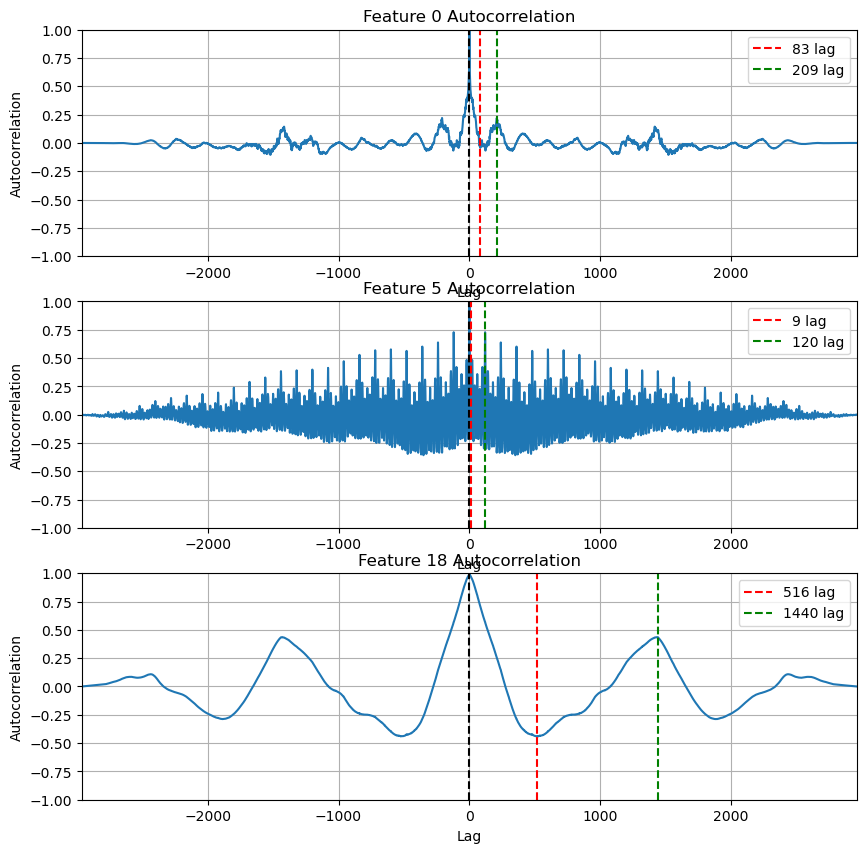

Mode-0 approx rank: 3/38
Estimated noise variance from mode-0: 1.5314e-06
Mode-1 approx rank: 6/20
Estimated noise variance from mode-1: 1.9343e-06
Mode-2 approx rank: 5/24
Estimated noise variance from mode-2: 2.7243e-06
Mode-3 approx rank: 1/60
Estimated noise variance from mode-3: 1.3214e-06
Estimated noise variance from mean of modes: 1.8779e-06
lambda_f suggestion: 5.3252e+05


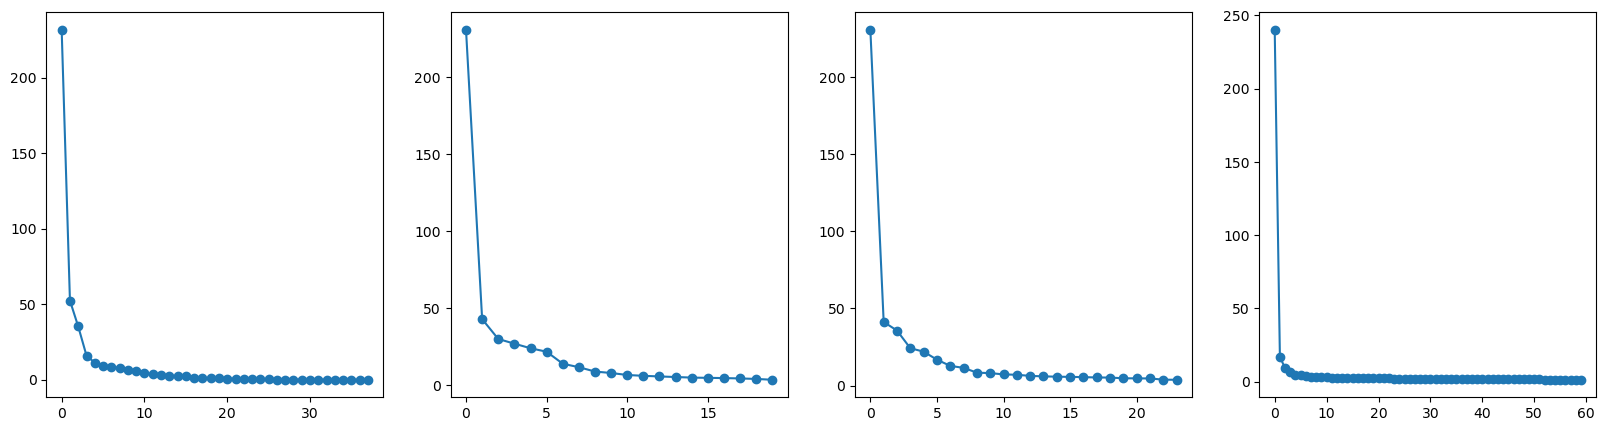

In [2]:
day_folding = (24,60)
mchannel = SMDMachineChannel(1,1)
Y = mchannel.Y
labels = mchannel.labels
rank_threshold = 0.99
fig, axe = plt.subplots(1,4, figsize=(20, 5))
estimated_variances = []
for i in range(4):
    svals = np.linalg.svd(matricize(Y, [i+1]), compute_uv=False)
    axe[i].plot(svals, marker='o')
    total_energy = np.sqrt(np.sum(svals**2))
    cumulative_energy = np.sqrt(np.cumsum(svals**2))
    r = (np.sum(cumulative_energy < (rank_threshold * total_energy))+1)
    print(f"Mode-{i} approx rank: {r}/{svals.shape[0]}")
    residual_energy = total_energy - cumulative_energy[r-1]
    m, n = matricize(Y, [i+1]).shape[0], matricize(Y, [i+1]).shape[1]
    estimated_variances.append(residual_energy/(m*n - r*(m+n-r)))
    print(f"Estimated noise variance from mode-{i}: {estimated_variances[-1]:.4e}")

estimated_variance = np.mean(estimated_variances)
print(f"Estimated noise variance from mean of modes: {estimated_variance:.4e}")
print(f"lambda_f suggestion: {1/estimated_variance:.4e}")

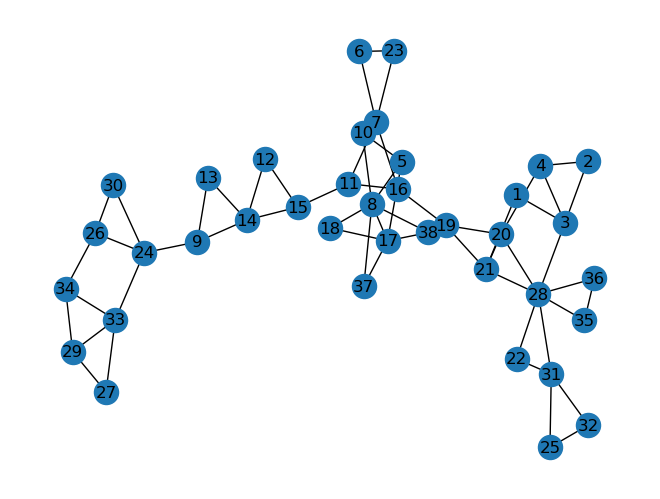

In [3]:
G = nx.from_scipy_sparse_array(kneighbors_graph(mchannel.test_data, 2))
nx.draw_kamada_kawai(G, labels={i: f'{i+1}' for i in range(38)})
Gt = nx.grid_graph(dim=(day_folding[1],))

In [3]:
# horpca_study = StudyWrapper('HoRPCA_f', 1, 1, 'gic_5')
horpca_study.run_study(n_trials=30, device='cuda:1', append_or_complete='append')

Running study HoRPCA_m1_ch1_scfggic_5 with 30 trials and 1 jobs.
Trial 37 achieved value: 43.45347584329133 with params:
{'lda': 0.0008209921767060866,
 'psi_1': 0.015106504392315437,
 'psi_2': 0.017091199972459316,
 'psi_3': 0.00010383273885795823,
 'psi_4': 0.18110769386342554}
----------------------------------------
{'aic': 1192444.265659305,
 'au_prc': 0.4011104560840071,
 'au_roc': 0.8072696541658011,
 'bic': 8704151.5624253,
 'dof': 596221.0,
 'dof_S': 571780,
 'dof_X': 24441.0,
 'gcv': 1.723661239851927e-12,
 'gic_1': 15.997000551233514,
 'gic_2': 145.79800429943657,
 'gic_3': 33.118351689848616,
 'gic_4': 39.12166652083182,
 'gic_5': 43.45347584329133,
 'gic_6': 227.72068307116945,
 'likelihood_au_prc': 0.520755434470327,
 'likelihood_au_roc': 0.8820740262800766,
 'loss': 0.4277822385765528,
 'nll': 1.132829652492949,
 'num_covariates': 2188800.0,
 'raw_PA_F1': 0.17284188239822923,
 'raw_PA_precision': 0.09459601811861372,
 'raw_PA_recall': 1.0,
 'raw_f1': 0.17284188239822923,

In [4]:
horpca_study = StudyWrapper('HoRPCA_f', 1, 1, 'gic_1')
horpca_study.run_study(n_trials=30, device='cuda:2', append_or_complete='append')

Running study HoRPCA_m1_ch1_scfggic_1 with 30 trials and 1 jobs.
Initial trial 0 achieved value: 482.8710761143359
Trial 1 achieved value: 20.84633896419211 with params:
{'lda': 0.0008701504198015132,
 'psi_1': 2.22538216164256,
 'psi_2': 12.283270236899872,
 'psi_3': 0.00018404165578426348,
 'psi_4': 0.2894645077191569}
----------------------------------------
{'aic': 1551352.428885516,
 'au_prc': 0.3436821018325861,
 'au_roc': 0.6314940418016091,
 'bic': 11323976.267057879,
 'dof': 775675.0,
 'dof_S': 775567,
 'dof_X': 108.0,
 'gcv': 5.81783540812968e-12,
 'gic_1': 20.84633896419211,
 'gic_2': 189.71558976613872,
 'gic_3': 43.120972102651294,
 'gic_4': 50.93119890030333,
 'gic_5': 56.566820919988615,
 'gic_6': 296.29582403541787,
 'likelihood_au_prc': 0.5663610505934676,
 'likelihood_au_roc': 0.904974995245793,
 'loss': 0.5910084497181307,
 'nll': 1.214442758063738,
 'num_covariates': 2188800.0,
 'raw_PA_F1': 0.17284188239822923,
 'raw_PA_precision': 0.09459601811861372,
 'raw_PA_rec

In [6]:
horpca_study = StudyWrapper('HoRPCA_f', 1, 1, 'gic_3')
horpca_study.run_study(n_trials=30, device='cuda:2', append_or_complete='append')

Running study HoRPCA_m1_ch1_scfggic_3 with 30 trials and 1 jobs.
Initial trial 0 achieved value: 50.384872782048994
Trial 1 achieved value: 49.20824000167567 with params:
{'lda': 0.0029592478829940476,
 'psi_1': 0.0007574610858150507,
 'psi_2': 0.0003889498164375082,
 'psi_3': 0.00021779968338653613,
 'psi_4': 7.743551645187992}
----------------------------------------
{'aic': 1546722.6432484689,
 'au_prc': 0.34369840576294663,
 'au_roc': 0.631479689206575,
 'bic': 11290142.314653972,
 'dof': 773357.0,
 'dof_S': 772833,
 'dof_X': 524.0,
 'gcv': 6.602758632747222e-11,
 'gic_1': 27.000171596661488,
 'gic_2': 195.3647794445888,
 'gic_3': 49.20824000167567,
 'gic_4': 56.99512699113877,
 'gic_5': 62.613907715382496,
 'gic_6': 301.62651307502284,
 'likelihood_au_prc': 0.5643615085698634,
 'likelihood_au_roc': 0.9043334328081897,
 'loss': 6.805371402402227,
 'nll': 4.321624234405786,
 'num_covariates': 2188800.0,
 'raw_PA_F1': 0.17284188239822923,
 'raw_PA_precision': 0.09459601811861372,
 'r

In [2]:
lr_sts_study = StudyWrapper('LR-STS', 1, 1, 'gic_3')
lr_sts_study.run_study(n_trials=30, device='cuda:2', append_or_complete='append')

Running study HoRPCA_m1_ch1_scfggic_3 with 30 trials and 1 jobs.


/mnt/ffs24/home/indibimu/repos/ML_GSP/src/proximal_ops/prox_overlapping_grouped_l21.py:396: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  G_ind = torch.sparse.spdiags(diagonals= torch.ones(G.number_of_nodes(), device=device, dtype=dtype),


Initial trial 1 achieved value: 905.1347008925645
Trial 2 achieved value: 1.9673858137169955 with params:
{'lda': 0.0015637156596357952,
 'lda_gtv_1': 4.861399547491453e-05,
 'psi_1': 0.0017226062841370162,
 'psi_2': 3.758227174811017,
 'psi_3': 1.7303058536640596,
 'psi_4': 0.0002362258294006723}
----------------------------------------
{'aic': 2205.743241878863,
 'au_prc': 0.3437068122538671,
 'au_roc': 0.6315319890839661,
 'bic': 16517.375876364316,
 'dof': 1101.0,
 'dof_S': 397,
 'dof_X': 704.0,
 'gcv': 1.594043757311332e-12,
 'gic_1': 1.9341154088973824,
 'gic_2': 2.212087640037195,
 'gic_3': 1.9673858137169955,
 'gic_4': 1.978583464142545,
 'gic_5': 1.9869937544453515,
 'gic_6': 2.336588052865115,
 'likelihood_au_prc': 0.5656511032071159,
 'likelihood_au_roc': 0.9047617217298146,
 'loss': 1.9053648124537226,
 'nll': 1.871620939431534,
 'num_covariates': 3264960.0,
 'raw_PA_F1': 0.17284188239822923,
 'raw_PA_precision': 0.09459601811861372,
 'raw_PA_recall': 1.0,
 'raw_f1': 0.1728

/mnt/ffs24/home/indibimu/repos/ML_GSP/src/stats/degrees_of_freedom.py:23: UserWarning: torch.linalg.svd: During SVD computation with the selected cusolver driver, batches 0 failed to converge. A more accurate method will be used to compute the SVD as a fallback. Check doc at https://pytorch.org/docs/stable/generated/torch.linalg.svd.html (Triggered internally at /pytorch/aten/src/ATen/native/cuda/linalg/BatchLinearAlgebraLib.cpp:690.)
  df[i] = min(D_tilde.shape) - torch.linalg.matrix_rank(D_tilde)


Trial 14 achieved value: 0.08377935845792961 with params:
{'lda': 0.00011605978046788281,
 'lda_gtv_1': 3.212193529592613e-05,
 'psi_1': 0.0009489879473877692,
 'psi_2': 0.01254124368731247,
 'psi_3': 15.233789690229335,
 'psi_4': 0.06087537008025547}
----------------------------------------
{'aic': 2519.850735043768,
 'au_prc': 0.3437275199476917,
 'au_roc': 0.6316399574518256,
 'bic': 18885.28714450534,
 'dof': 1259.0,
 'dof_S': 1067,
 'dof_X': 192.0,
 'gcv': 1.0760198662196192e-14,
 'gic_1': 0.04573445412741841,
 'gic_2': 0.3635973415070953,
 'gic_3': 0.08377935845792961,
 'gic_4': 0.09658393782738196,
 'gic_5': 0.10620115444067292,
 'gic_6': 0.5059642985918824,
 'likelihood_au_prc': 0.5673372507649875,
 'likelihood_au_roc': 0.9052580595147556,
 'loss': 0.012857977358510382,
 'nll': 0.9253675218839279,
 'num_covariates': 3264960.0,
 'raw_PA_F1': 0.17284188239822923,
 'raw_PA_precision': 0.09459601811861372,
 'raw_PA_recall': 1.0,
 'raw_f1': 0.17284188239822923,
 'raw_group_accuracy'

In [2]:
lr_stss_study = StudyWrapper('LR-STSS_f', 1, 1, 'gic_5')
lr_stss_study.run_study(n_trials=30, device='cuda:2', append_or_complete='append')

Running study LR-STSS_f_m1_ch1_scfggic_5 with 30 trials and 1 jobs.


/mnt/ffs24/home/indibimu/repos/ML_GSP/src/proximal_ops/prox_overlapping_grouped_l21.py:396: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  G_ind = torch.sparse.spdiags(diagonals= torch.ones(G.number_of_nodes(), device=device, dtype=dtype),


Initial trial 0 achieved value: 948.0390783613028
Trial 1 achieved value: 78.94172821872603 with params:
{'lda': 10.185050872474175,
 'lda_gtv_1': 0.0002580860129419858,
 'lda_gtv_2': 1.804160662032559e-05,
 'psi_1': 0.00016523046796767147,
 'psi_2': 0.13698456525945865,
 'psi_3': 0.00430632772299698,
 'psi_4': 0.0029459951759232433}
----------------------------------------
{'aic': 2073746.4235244934,
 'au_prc': 0.10219457013028792,
 'au_roc': 0.52646828702714,
 'bic': 15851531.321275648,
 'dof': 1036872.0,
 'dof_S': 0,
 'dof_X': 1036872.0,
 'gcv': 1.7696105063051147e-10,
 'gic_1': 27.661658721909014,
 'gic_2': 318.6626111037882,
 'gic_3': 60.1199555681796,
 'gic_4': 70.73973730475501,
 'gic_5': 78.94172821872603,
 'gic_6': 414.5192626442752,
 'likelihood_au_prc': 0.1046870143464459,
 'likelihood_au_roc': 0.5342655610129967,
 'loss': 0.5856474269676225,
 'nll': 1.2117622466884839,
 'num_covariates': 4359360.0,
 'raw_PA_F1': 0.0,
 'raw_PA_precision': 0.0,
 'raw_PA_recall': 0.0,
 'raw_f1

/mnt/ffs24/home/indibimu/repos/ML_GSP/src/stats/degrees_of_freedom.py:23: UserWarning: torch.linalg.svd: During SVD computation with the selected cusolver driver, batches 0 failed to converge. A more accurate method will be used to compute the SVD as a fallback. Check doc at https://pytorch.org/docs/stable/generated/torch.linalg.svd.html (Triggered internally at /pytorch/aten/src/ATen/native/cuda/linalg/BatchLinearAlgebraLib.cpp:690.)
  D_tilde = D[~B_indices[i,:]]


Trial 10 achieved value: 0.4301886273838787 with params:
{'lda': 0.00018958706166471062,
 'lda_gtv_1': 1.768146651453584e-05,
 'lda_gtv_2': 0.000477741991556508,
 'psi_1': 8.7445677119233,
 'psi_2': 7.349254603043345,
 'psi_3': 11.006933958168924,
 'psi_4': 17.71614207793831}
----------------------------------------
{'aic': 962.231792249453,
 'au_prc': 0.343670750835778,
 'au_roc': 0.6312231995518881,
 'bic': 7340.392983718172,
 'dof': 480.0,
 'dof_S': 480,
 'dof_X': 0.0,
 'gcv': 3.2917860121116353e-13,
 'gic_1': 0.40644950301898874,
 'gic_2': 0.541162811067911,
 'gic_3': 0.4214754488312104,
 'gic_4': 0.426391673045536,
 'gic_5': 0.4301886273838787,
 'gic_6': 0.5855378088877322,
 'likelihood_au_prc': 0.5630953188737683,
 'likelihood_au_roc': 0.9023815950498086,
 'loss': 0.3939151830435512,
 'nll': 1.1158961247264483,
 'num_covariates': 4359360.0,
 'raw_PA_F1': 0.17284188239822923,
 'raw_PA_precision': 0.09459601811861372,
 'raw_PA_recall': 1.0,
 'raw_f1': 0.17284188239822923,
 'raw_gro

: 

## HoRPCA HP-Study

In [4]:
max_iter = 2#2000
lda_f = 300
rho = 0.1

def horpca_objective(trial):

    lda = trial.suggest_float("lda", 0.01, 20, log=True)
    psis = [trial.suggest_float(f"psi_{i}", 0.1, 20, log=True) for i in range(1, 5)]
    horpca= SNN__LOGN_GTV(Y, G, lr_modes=[1,2,3,4], graph_modes=[1], gtvr_config=[],
                      grouping='neighbor', r_hop=0,
                      soft_constrained=True, device='cuda:1', verbose=False)

    X, S = horpca(psis=psis, lda=lda, lda_gtvs=[], lda_f=lda_f,
                  rho_update='domain_parametrization', max_iter=max_iter, rho=rho, tol=1e-4)
    
    V_sum = horpca.V.sum(dim=0, keepdim=False).coalesce().to_dense()
    S_ = tensorize(V_sum, horpca.Y.shape, horpca.graph_modes)

    results = {}
    num_parameter = horpca.num_parameters()
    results['num_parameter_X'] = num_parameter['X']
    results['num_parameter_S'] = num_parameter['S']
    results['num_parameters'] = num_parameter['X'] + num_parameter['S']
    diff = len(horpca.Y.ravel()) - results['num_parameters']
    if diff <=0:
        results['gcv'] = (torch.linalg.norm(horpca.Y - X - S)/ 1e-16)**2
    else:
        results['gcv'] = (torch.linalg.norm(horpca.Y - X - S)/ diff)**2
    
    results['gcv'] = results['gcv'].item()
    scoring_scores = mchannel.anomaly_scoring_score(horpca.S.abs())

    V_sum = horpca.V.sum(dim=0, keepdim=False).coalesce().to_dense()
    labels = tensorize(V_sum, horpca.Y.shape, horpca.graph_modes)!=0

    detection_scores = mchannel.anomaly_detection_score(labels)

    results['au_prc'] = scoring_scores['au_prc']
    results['au_roc'] = scoring_scores['au_roc']
    
    results = {**results, **detection_scores}
    

    for key, value in results.items():
        trial.set_user_attr(key, value)
    # trial.set_user_attr("metrics", results)
    return results['gcv']
    
study = optuna.study.create_study(study_name=f'smd_horpca_M{mchannel.machine_id}_Ch{mchannel.channel_id}_gcv_ow',
                                  direction='minimize', storage='sqlite:///smd_horpca_triall.db',
                                  load_if_exists=True)

study.optimize(horpca_objective, n_trials=2, #100,
                show_progress_bar=True)

[I 2025-07-26 16:25:02,611] Using an existing study with name 'smd_horpca_M1_Ch1_gcv_ow' instead of creating a new one.


  0%|          | 0/2 [00:00<?, ?it/s]

/mnt/ffs24/home/indibimu/repos/ML_GSP/src/proximal_ops/prox_overlapping_grouped_l21.py:405: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  G_ind = torch.sparse_csr_tensor(A_r.indptr, A_r.indices, A_r.data, device=device, dtype=dtype)


[I 2025-07-26 16:25:06,050] Trial 7 finished with value: 9.709447189428729e-21 and parameters: {'lda': 0.16874508830607718, 'psi_1': 0.22710422605402125, 'psi_2': 1.0684639369292284, 'psi_3': 12.76169252776945, 'psi_4': 0.547531120013714}. Best is trial 2 with value: 5.4230306290533094e-21.
[I 2025-07-26 16:25:07,233] Trial 8 finished with value: 5.914959812431621e-21 and parameters: {'lda': 11.77765253186332, 'psi_1': 0.4897254945225454, 'psi_2': 0.2454784927730616, 'psi_3': 6.784589033563661, 'psi_4': 0.7356854989309284}. Best is trial 2 with value: 5.4230306290533094e-21.


In [ ]:
best_trial = study.best_trial
print("Best trial:", best_trial.number)
best_parameters = study.best_params
print("Best parameters:", best_parameters)
metrics = study.best_trial.user_attrs
print("Best metrics:")
pprint(metrics)

Best trial: 59
Best parameters: {'lda': 0.010070294495165442, 'psi_1': 0.24516928085844353, 'psi_2': 1.4792348902177068, 'psi_3': 1.6395387910830752, 'psi_4': 1.2473722508381428}
Best metrics:
{'au_prc': 0.17768667020120665,
 'au_roc': 0.7276210219071167,
 'f1': 0.09411196911196912,
 'gcv': 7.002372349896065e-15,
 'group_accuracy': 1.0,
 'group_support_ratio': 0.7576727677639362,
 'num_parameter_S': 609390,
 'num_parameter_X': 2117.0,
 'num_parameters': 611507.0,
 'precision': 0.049379589769561916,
 'raw_F1': 0.09411196911196912,
 'raw_precision': 0.049379589769561916,
 'raw_recall': 1.0,
 'recall': 1.0}


In [ ]:
def rachitas_thresholder(model, G, sig=0.99):
    S_loc = matricize(model.Y - model.X, [1]).cpu().numpy()
    radius = 2
    r_A = np.eye(S_loc.shape[0])+np.linalg.matrix_power(nx.adjacency_matrix(G).toarray(),radius)
    likelihood = np.zeros(S_loc.shape)
    for s in range(S_loc.shape[0]):
        mask = r_A[np.where(r_A[s,]!=0),:].astype(bool)
        nbd = S_loc[mask[:,0,:].ravel(),:]
        # Append neighbors from additional columns in mask
        for m in range(1, mask.shape[1]):
            nbd = np.vstack((nbd,S_loc[mask[:,m,:].ravel(),:] ))
                
        W = np.zeros(nbd.shape)
        # Iterate through the columns in steps of block_size
        for i1 in range(0, S_loc.shape[1], 1440):
            # Slice the matrix to get the block (columns from i to i + block_size)
            if i1==0:
                block = nbd[:, i1:i1 + 1440]
                for loc in range(nbd.shape[0]):
                    W[loc, i1:i1+1440] = norm.pdf(np.linalg.norm(block[loc,:] - S_loc[s,i1:i1+1440]),0,30)
            elif i1 == S_loc.shape[1]-1440: #23040:
                block = nbd[:, i1-1440:i1 + 1440]
                for loc in range(nbd.shape[0]):
                    W[loc, i1:i1+1440] = norm.pdf(np.linalg.norm(block[loc,:] - S_loc[s,i1-1440:i1+1440]),0,30)
            else:
                block = nbd[:, i1-1440:i1 + 2880]
                for loc in range(nbd.shape[0]):
                    W[loc, i1:i1+1440] = norm.pdf(np.linalg.norm(block[loc,:] - S_loc[s,i1-1440:i1+2880]),0,30)
                        
        mean = np.sum(W * nbd) / np.sum(W)
        sd = np.sqrt(np.sum(W * (nbd - mean)**2) / np.sum(W))
        if sd == 0:
            sd = sd+(10e-20)
        likelihood[s,] = np.log(sd) + (0.5*np.power(((S_loc[s,] - mean)/sd),2))

    return tensorize(likelihood, model.Y.shape, [1])

# sig = 0.97
# likelihood = rachitas_thresholder(model, G)
# det = np.zeros(S_loc.shape)
# q = np.quantile(likelihood,sig)
# det[likelihood > q] = 1

# scoring_scores = mchannel.anomaly_scoring_score(tensorize(likelihood, model.Y.shape, [1]))
# detection_scores = mchannel.anomaly_detection_score(tensorize(det, model.Y.shape, [1]))


In [34]:
lda_f = 330
rho = 0.1
max_iter = 10#5000
best_parameters = {'lda': 0.010070294495165442, 'psi_1': 0.24516928085844353, 'psi_2': 1.4792348902177068, 'psi_3': 1.6395387910830752, 'psi_4': 1.2473722508381428}
horpca= SNN__LOGN_GTV(Y, G, lr_modes=[1,2,3,4], graph_modes=[1], gtvr_config=[],
                    # grouping='only_center',
                      grouping='neighbor', r_hop=0,
                      soft_constrained=True, device='cuda:1', verbose=False)

X, S = horpca(psis=[best_parameters[f'psi_{i}'] for i in range(1, 5)],
            lda=best_parameters['lda'], lda_gtvs=[], lda_f=lda_f,
            rho_update='domain_parametrization', max_iter=max_iter, rho=rho, tol=1e-4)
    
V_sum = horpca.V.sum(dim=0, keepdim=False).coalesce().to_dense()
S_ = tensorize(V_sum, horpca.Y.shape, horpca.graph_modes)

In [7]:
artifact_store_path = BASE_DIR / 'experiment_board'/ 'smd_anomaly_detection' / 'results' / 'artifacts'
os.makedirs(artifact_store_path, exist_ok=True)
artifact_store = FileSystemArtifactStore(artifact_store_path)

In [8]:
data = {'S':S_.cpu().numpy()}
fd, fpath = tempfile.mkstemp(suffix='.npz', prefix='smd_horpca_')
np.savez(fpath, **data)
os.close(fd)
artifact_id = upload_artifact(artifact_store=artifact_store,
                             file_path=fpath,
                             study_or_trial=study)
os.remove(fpath)

In [9]:
# download_artifact()
optuna.artifacts.get_all_artifact_meta(study)


[ArtifactMeta(artifact_id='efdf9901-40d4-487f-adfe-e7c1d44b63b8', filename='smd_horpca_k0f1dsxm.npz', mimetype='application/octet-stream', encoding=None)]

In [ ]:
horpca_likelihood = rachitas_thresholder(horpca, G)

q = np.quantile(horpca_likelihood, 0.992)
horpca_det = np.zeros(horpca_likelihood.shape)
horpca_det[horpca_likelihood > q] = 1

horpca_scoring_scores = mchannel.anomaly_scoring_score(S.abs())
horpca_detection_scores = mchannel.anomaly_detection_score(S_!=0)

horpca_rachitas_scores = mchannel.anomaly_scoring_score(horpca_likelihood)
horpca_rachitas_detection = mchannel.anomaly_detection_score(horpca_det)

print("Raw Anomaly Scoring Performance:\n", '='*20)
print(' -> AU-PRC:', horpca_scoring_scores['au_prc'])
print(' -> AU-ROC:', horpca_scoring_scores['au_roc'])
print(' -> Precision: ', horpca_detection_scores['precision'], '\t| P.A Precision: ', horpca_detection_scores['PA_precision'])
print(' -> Recall: ', detection_scores['recall'], '\t\t\t| P.A Recall: ', horpca_detection_scores['PA_recall'])
print(' -> F1-Score: ', horpca_detection_scores['f1'], '\t| P.A F1-Score: ', horpca_detection_scores['PA_F1'])
print(' -> Group-wise Accuracy: ', horpca_detection_scores['group_accuracy'])
print(' -> Group-support Ratio: ', horpca_detection_scores['group_support_ratio'])
print(' '*20)
print("Rachitas Likelihood Conversion Scores:\n", '='*20)
print(' -> AU-PRC:', horpca_rachitas_scores['au_prc'])
print(' -> AU-ROC:', horpca_rachitas_scores['au_roc'])
print(' -> Precision: ', horpca_rachitas_detection['precision'], '\t| P.A Precision: ', horpca_rachitas_detection['PA_precision'])
print(' -> Recall: ', horpca_rachitas_detection['recall'], '\t| P.A Recall: ', horpca_rachitas_detection['PA_recall'])
print(' -> F1-Score: ', horpca_rachitas_detection['f1'], '\t| P.A F1-Score: ', horpca_rachitas_detection['PA_F1'])
print(' -> Group-wise Accuracy: ', horpca_rachitas_detection['group_accuracy'])
print(' -> Group-support Ratio: ', horpca_rachitas_detection['group_support_ratio'])

Raw Anomaly Scoring Performance:
 -> AU-PRC: 0.44182896987247433
 -> AU-ROC: 0.8656085622658615
 -> Precision:  0.09459601811861372 	| P.A Precision:  0.09459601811861372
 -> Recall:  1.0 			| P.A Recall:  1.0
 -> F1-Score:  0.17284188239822923 	| P.A F1-Score:  0.17284188239822923
 -> Group-wise Accuracy:  1.0
 -> Group-support Ratio:  0.9453909421063875
                    
Rachitas Likelihood Conversion Scores:
 -> AU-PRC: 0.5815342607948747
 -> AU-ROC: 0.8994611658654694
 -> Precision:  0.674333698430084 	| P.A Precision:  0.7512548800892359
 -> Recall:  0.6855976243504083 	| P.A Recall:  1.0
 -> F1-Score:  0.6799190134364071 	| P.A F1-Score:  0.8579617834394905
 -> Group-wise Accuracy:  1.0
 -> Group-support Ratio:  0.11423841059602649


### Pareto front for Group Support vs $F_1$ Score

100%|██████████| 20/20 [00:00<00:00, 20.11it/s]


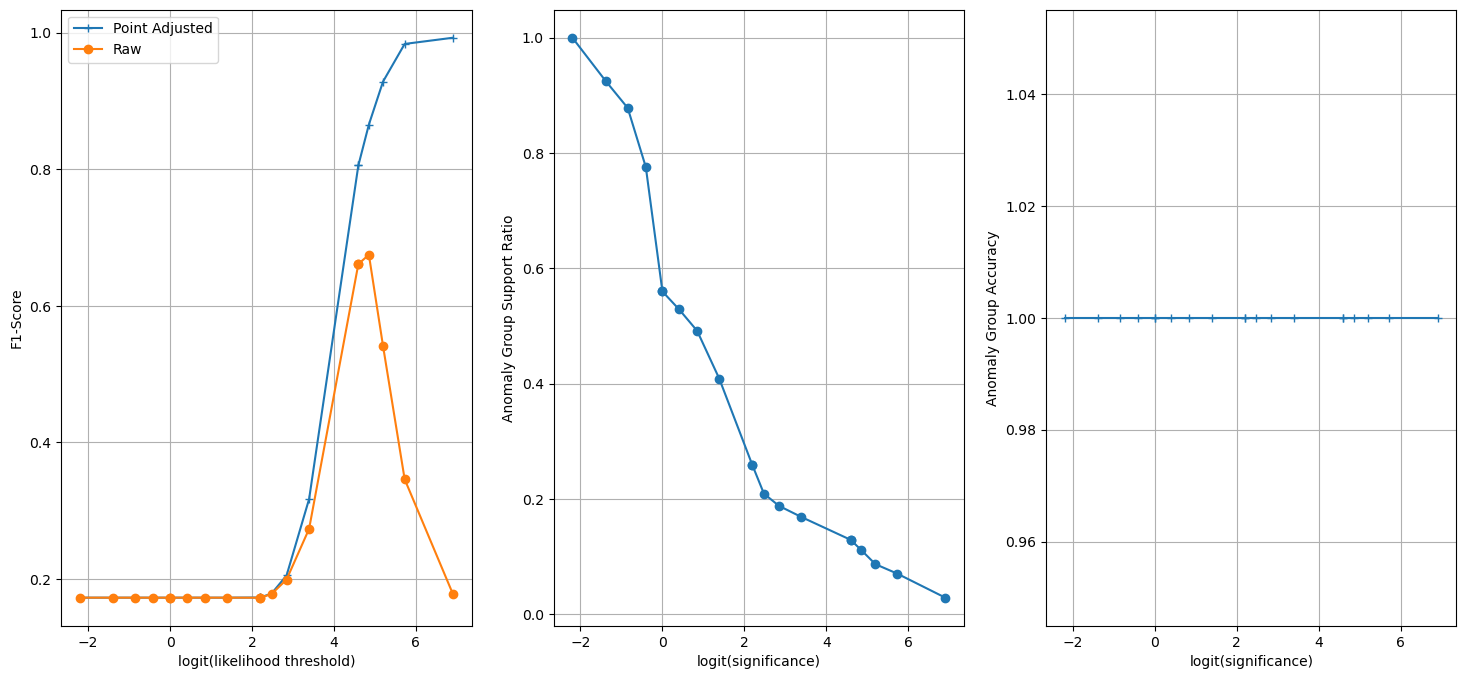

In [ ]:
sigs = list(np.linspace(0.1, 0.5, 5)) + list(np.linspace(0.5, 0.9, 5)) + list(np.linspace(0.9, 0.99, 5))+list(np.linspace(0.99, 0.999, 5))

horpca_F1_scores = []
horpca_F1_scores_PA = []
horpca_Group_accuracy = []
horpca_Group_support_ratios = []

for i, sig in tqdm(enumerate(sigs), total=len(sigs)):
    # rachitas_scores, rachitas_detection = rachitas_thresholder(lr_sts, G, sig=sig)
    q = np.quantile(horpca_likelihood, sig)
    det = np.zeros(horpca_likelihood.shape)
    det[horpca_likelihood > q] = 1
    rachitas_detection = mchannel.anomaly_detection_score(det)
    horpca_F1_scores.append(rachitas_detection['f1'])
    horpca_F1_scores_PA.append(rachitas_detection['PA_F1'])
    horpca_Group_accuracy.append(rachitas_detection['group_accuracy'])
    horpca_Group_support_ratios.append(rachitas_detection['group_support_ratio'])

logit_sig = np.log((np.array(sigs)/(1-np.array(sigs))))
fig, axes = plt.subplots(1,3, figsize=(18, 8))
axes[0].plot(logit_sig, horpca_F1_scores_PA, marker='+', label='Point Adjusted')
axes[0].plot(logit_sig, horpca_F1_scores, marker='o', label='Raw')
axes[0].set_ylabel('F1-Score')
axes[0].set_xlabel('logit(likelihood threshold)');
axes[0].legend()

axes[2].plot(logit_sig, horpca_Group_accuracy, marker='+')
axes[2].set_ylabel('Anomaly Group Accuracy')
axes[2].set_xlabel('logit(significance)');

axes[1].plot(logit_sig, horpca_Group_support_ratios, marker='o')
axes[1].set_ylabel('Anomaly Group Support Ratio')
axes[1].set_xlabel('logit(significance)');
[axe.grid() for axe in axes];

100%|██████████| 20/20 [00:48<00:00,  2.43s/it]


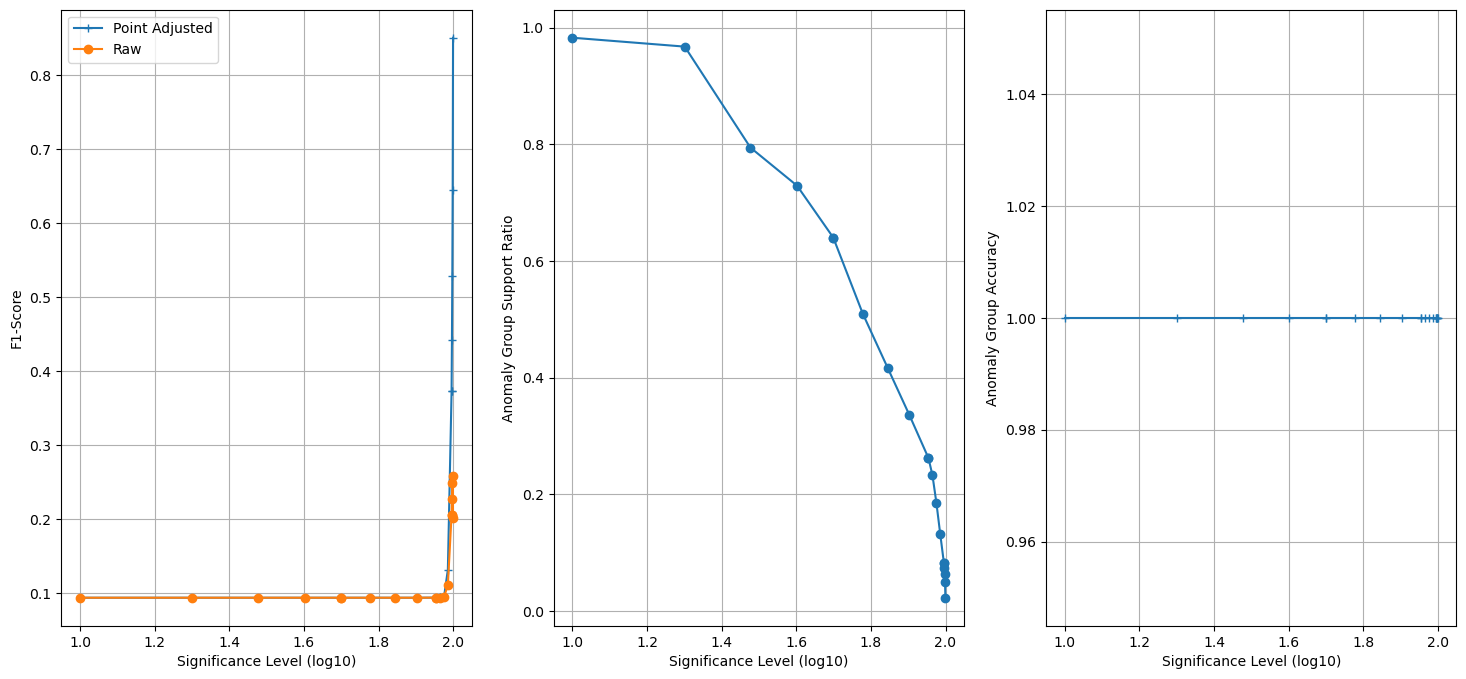

In [ ]:
sigs = list(np.linspace(0.1, 0.5, 5)) + list(np.linspace(0.5, 0.9, 5)) + list(np.linspace(0.9, 0.99, 5))+list(np.linspace(0.99, 0.999, 5))

F1_scores = []
F1_scores_raw = []
Group_accuracy = []
Group_support_ratios = []

for i, sig in tqdm(enumerate(sigs), total=len(sigs)):
    rachitas_scores, rachitas_detection = rachitas_thresholder(horpca, G, sig=sig)
    F1_scores.append(rachitas_detection['f1'])
    F1_scores_raw.append(rachitas_detection['raw_F1'])
    Group_accuracy.append(rachitas_detection['group_accuracy'])
    Group_support_ratios.append(rachitas_detection['group_support_ratio'])

fig, axes = plt.subplots(1,3, figsize=(18, 8))
axes[0].plot(np.log10(np.array(sigs)*100), F1_scores, marker='+', label='Point Adjusted')
axes[0].plot(np.log10(np.array(sigs)*100), F1_scores_raw, marker='o', label='Raw')
axes[0].set_ylabel('F1-Score')
axes[0].set_xlabel('Significance Level (log10)');
axes[0].legend()

axes[2].plot(np.log10(np.array(sigs)*100), Group_accuracy, marker='+')
axes[2].set_ylabel('Anomaly Group Accuracy')
axes[2].set_xlabel('Significance Level (log10)');

axes[1].plot(np.log10(np.array(sigs)*100), Group_support_ratios, marker='o')
axes[1].set_ylabel('Anomaly Group Support Ratio')
axes[1].set_xlabel('Significance Level (log10)');
[axe.grid() for axe in axes];

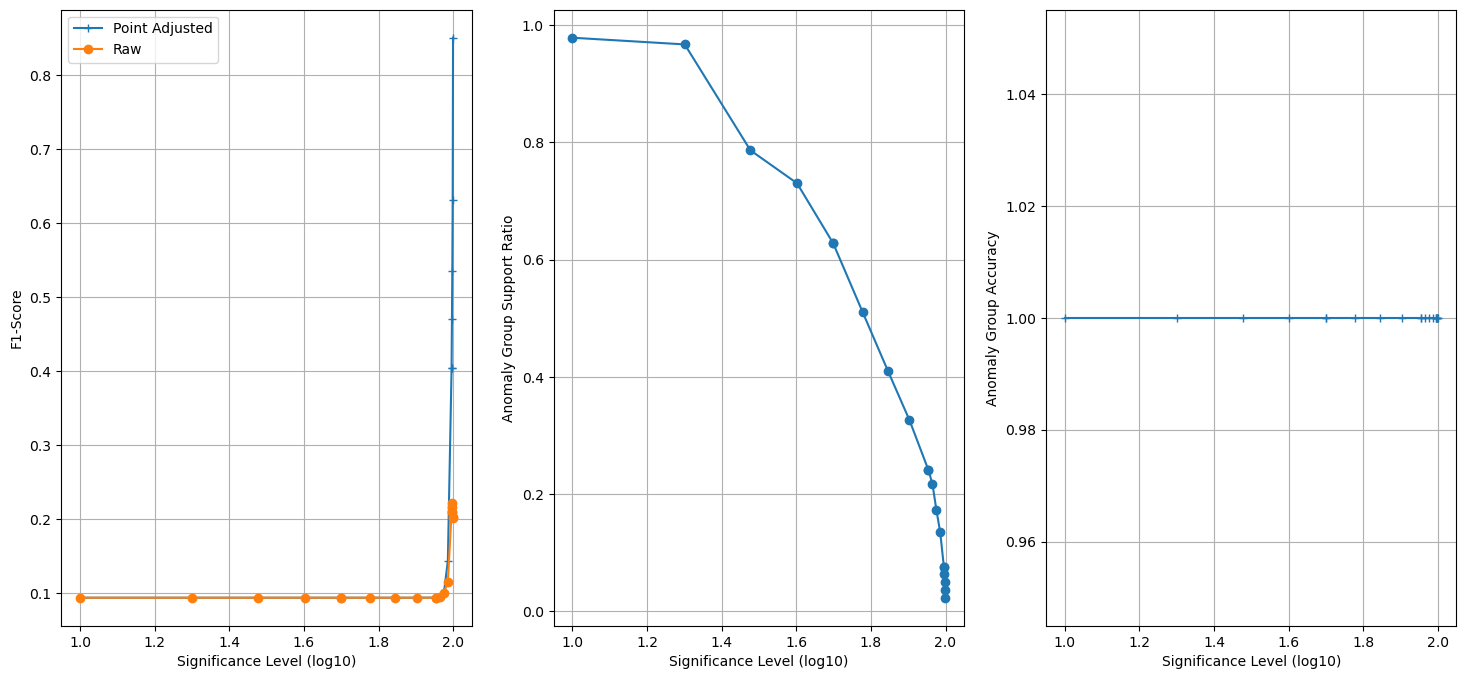

## LR-STS HP Study

In [ ]:
@torch.jit.script#
def calculate_df_naive(B_indices, D):
    """Generalized sparse lasso degrees of freedom calculation.

    Following the Corollary 2 of the paper,
    - Tibshirani, Ryan J. "The solution path of the generalized lasso". Stanford University, 2011
    Args:
        B_indices (torch.Tensor): A boolean tensor indicating non-zero edges and weights with shape (batch_size, m+p)
        D (torch.tensor): A tensor of shape (m+p, p) representing the difference matrix
    """
    non_zero_b_indices = B_indices.any(dim=1)
    B_indices = B_indices[non_zero_b_indices]
    df = torch.zeros(B_indices.shape[0], device=B_indices.device, dtype=B_indices.dtype)
    for i in range(B_indices.shape[0]):
        D_tilde = D[~B_indices[i,:]]
        df[i] = min(D_tilde.shape) - torch.linalg.matrix_rank(D_tilde)
    return sum(df)

In [ ]:
Gt = nx.grid_graph(dim=(day_folding[1],))

gtvr_config = [ { 'graph': 'temporal',
                    'mode': [4],
                    'variation_type': 'GTV',
                    'p': 1,
                    'normalization': 'none'}]

max_iter = 2000
lda_f = 330 # Kinda random
rho = 0.1


def lr_sts_df(lr_sts, Gt):
    """Estimate degrees of freedom naively for LR-STS model"""
    I = torch.diag(torch.ones(Gt.number_of_nodes(), device=lr_sts.device, dtype=lr_sts.dtype))
    BT = torch.tensor(nx.incidence_matrix(Gt, nodelist=sorted(Gt.nodes()), oriented=True).todense(),
                 device=lr_sts.device, dtype=lr_sts.dtype).T
    # print(I.shape, BT.shape)
    D = torch.vstack([BT, I])
    # print(D.shape)

    V_sum = lr_sts.V.sum(dim=0, keepdim=False).coalesce().to_dense()
    S_ = tensorize(V_sum, lr_sts.Y.shape, lr_sts.graph_modes)
    S_ = matricize(S_, [4])

    nonzero_edge = (lr_sts.Ws[0].T!=0) 
    nonzero_node = (S_.T!=0)
    # print(f"nonzero_node shape: {nonzero_node.shape}, nonzero_edge shape: {nonzero_edge.shape}")
    Bindices = torch.hstack([nonzero_edge, nonzero_node])
    # print(f"Bindices shape: {Bindices.shape}")
    
    df = calculate_df_naive(Bindices, D)
    return df.item()

def lr_sts_objective(trial):
    lda = trial.suggest_float("lda", 0.001, 20, log=True)
    psis = [trial.suggest_float(f"psi_{i}", 0.01, 20, log=True) for i in range(1, 5)]
    lda_t = trial.suggest_float("lda_t", 1e-6, 0.1, log=True)
    lr_sts= SNN__LOGN_GTV(Y, G, lr_modes=[1,2,3,4], graph_modes=[1], gtvr_config=gtvr_config,
                      grouping='neighbor', r_hop=0,
                      soft_constrained=True, device='cuda:2', verbose=False)

    X, S = lr_sts(psis=psis, lda=lda, lda_gtvs=[lda_t], lda_f=lda_f,
                  rho_update='domain_parametrization', max_iter=max_iter, rho=rho, tol=1e-4)
    
    V_sum = lr_sts.V.sum(dim=0, keepdim=False).coalesce().to_dense()
    S_ = tensorize(V_sum, lr_sts.Y.shape, lr_sts.graph_modes)

    results = {}
    num_parameter = lr_sts.num_parameters()
    results['num_parameter_X'] = num_parameter['X']
    results['num_parameter_S'] = lr_sts_df(lr_sts, Gt)
    results['num_parameters'] = num_parameter['X'] + results['num_parameter_S']
    diff = len(lr_sts.Y.ravel()) - results['num_parameters']
    
    results['gcv'] = (torch.linalg.norm(lr_sts.Y - X - S)/ max(1, diff))**2
    
    results['gcv'] = results['gcv'].item()
    scoring_scores = mchannel.anomaly_scoring_score(lr_sts.S.abs())

    V_sum = lr_sts.V.sum(dim=0, keepdim=False).coalesce().to_dense()
    labels = tensorize(V_sum, lr_sts.Y.shape, lr_sts.graph_modes)!=0

    detection_scores = mchannel.anomaly_detection_score(labels)

    results['au_prc'] = scoring_scores['au_prc']
    results['au_roc'] = scoring_scores['au_roc']
    
    results = {**results, **detection_scores}
    

    for key, value in results.items():
        trial.set_user_attr(key, value)
    # trial.set_user_attr("metrics", results)
    return results['gcv']
    
study = optuna.study.create_study(study_name=f'smd_lr_sts_M{mchannel.machine_id}_Ch{mchannel.channel_id}_gcv_ow2',
                                  direction='minimize', storage='sqlite:///smd_lr_sts.db',
                                  load_if_exists=True)

study.optimize(lr_sts_objective, n_trials=100, show_progress_bar=True)

[I 2025-07-22 16:04:26,551] A new study created in RDB with name: smd_lr_sts_M2_Ch1_gcv_ow2


  0%|          | 0/100 [00:00<?, ?it/s]

/mnt/ffs24/home/indibimu/repos/ML_GSP/src/proximal_ops/prox_overlapping_grouped_l21.py:405: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647378361/work/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  G_ind = torch.sparse_csr_tensor(A_r.indptr, A_r.indices, A_r.data, device=device, dtype=dtype)


[I 2025-07-22 16:05:08,398] Trial 0 finished with value: 1.57264571561575e-16 and parameters: {'lda': 0.020688533911452246, 'psi_1': 0.029144842894846718, 'psi_2': 7.78067578586798, 'psi_3': 0.07005139660421367, 'psi_4': 0.1986498858466021, 'lda_t': 0.0004456348294655944}. Best is trial 0 with value: 1.57264571561575e-16.
[I 2025-07-22 16:05:49,121] Trial 1 finished with value: 1.1564420223435036e-12 and parameters: {'lda': 3.5569973289252044, 'psi_1': 0.07861966878415239, 'psi_2': 1.1073410167856432, 'psi_3': 7.435233848242636, 'psi_4': 0.16808353404457538, 'lda_t': 6.3775188143438e-06}. Best is trial 0 with value: 1.57264571561575e-16.
[I 2025-07-22 16:06:25,679] Trial 2 finished with value: 1.181143399666648e-15 and parameters: {'lda': 0.060334250173785284, 'psi_1': 0.5716751671521967, 'psi_2': 0.07393769752717835, 'psi_3': 6.622912379554091, 'psi_4': 0.019957279609694515, 'lda_t': 4.540794331102214e-05}. Best is trial 0 with value: 1.57264571561575e-16.
[I 2025-07-22 16:06:59,224] 

In [ ]:
best_trial = study.best_trial
print("Best trial:", best_trial.number)
best_parameters = study.best_params
print("Best parameters:", best_parameters)
metrics = study.best_trial.user_attrs
print("Best metrics:")
pprint(metrics)

Best trial: 61
Best parameters: {'lda': 0.0010013243278381532, 'psi_1': 9.846625576504296, 'psi_2': 19.542998673323755, 'psi_3': 5.407887462484994, 'psi_4': 0.31300782717370523, 'lda_t': 3.95073629467695e-06}
Best metrics:
{'au_prc': 0.12014895370000805,
 'au_roc': 0.6757842347080493,
 'f1': 0.09411196911196912,
 'gcv': 2.66501216898572e-19,
 'group_accuracy': 1.0,
 'group_support_ratio': 0.9995824344074048,
 'num_parameter_S': 151,
 'num_parameter_X': 59.0,
 'num_parameters': 210.0,
 'precision': 0.049379589769561916,
 'raw_F1': 0.09411196911196912,
 'raw_precision': 0.049379589769561916,
 'raw_recall': 1.0,
 'recall': 1.0}


In [ ]:
Gt = nx.grid_graph(dim=(day_folding[1],))
gtvr_config = [ { 'graph': 'temporal',
                    'mode': [4],
                    'variation_type': 'GTV',
                    'p': 1,
                    'normalization': 'none'}]
max_iter = 5000
lda_f = 330
rho = 0.1
# best_parameters = {'lda': 0.0011475419855272687, 'psi_1': 6.430745439828981, 'psi_2': 0.17159150515521177, 'psi_3': 3.309815381587917, 'psi_4': 0.28357171407445303, 'lda_t': 3.1815338028567026e-06}
# best_parameters = {'lda': 0.001480902312281686, 'psi_1': 11.159117218828827, 'psi_2': 17.669131889579116, 'psi_3': 2.4484815951508514, 'psi_4': 0.11159426917777823, 'lda_t': 4.543873174265456e-06}
{'lda': 0.10070294495165442, 'psi_1': 0.24516928085844353, 'psi_2': 1.4792348902177068, 'psi_3': 1.6395387910830752, 'psi_4': 1.2473722508381428, 'lda_t': 4.1815338028567026e-06}
lr_sts= SNN__LOGN_GTV(Y, G, lr_modes=[1,2,3,4], graph_modes=[1], gtvr_config=gtvr_config,
                      grouping='neighbor', r_hop=0,
                      soft_constrained=True, device='cuda:1', verbose=False)

X, S = lr_sts(psis=[best_parameters[f'psi_{i}'] for i in range(1, 5)],
            lda=best_parameters['lda'], lda_gtvs=[best_parameters['lda_t']], lda_f=lda_f,
            rho_update='domain_parametrization', max_iter=max_iter, rho=rho, tol=1e-4)
    
V_sum = lr_sts.V.sum(dim=0, keepdim=False).coalesce().to_dense()
S_ = tensorize(V_sum, lr_sts.Y.shape, lr_sts.graph_modes)

In [ ]:
lr_sts_likelihood = rachitas_thresholder(lr_sts, G)

q = np.quantile(lr_sts_likelihood, 0.992)
lr_sts_det = np.zeros(lr_sts_likelihood.shape)
lr_sts_det[lr_sts_likelihood > q] = 1

lr_sts_scoring_scores = mchannel.anomaly_scoring_score(S.abs())
lr_sts_detection_scores = mchannel.anomaly_detection_score(S_!=0)

lr_sts_rachitas_scores = mchannel.anomaly_scoring_score(lr_sts_likelihood)
lr_sts_rachitas_detection = mchannel.anomaly_detection_score(lr_sts_det)

print("Raw Anomaly Scoring Performance:\n", '='*20)
print(' -> AU-PRC:', lr_sts_scoring_scores['au_prc'])
print(' -> AU-ROC:', lr_sts_scoring_scores['au_roc'])
print(' -> Precision: ', lr_sts_detection_scores['precision'], '\t| P.A Precision: ', lr_sts_detection_scores['PA_precision'])
print(' -> Recall: ', lr_sts_detection_scores['recall'], '\t\t\t| P.A Recall: ', lr_sts_detection_scores['PA_recall'])
print(' -> F1-Score: ', lr_sts_detection_scores['f1'], '\t| P.A F1-Score: ', lr_sts_detection_scores['PA_F1'])
print(' -> Group-wise Accuracy: ', lr_sts_detection_scores['group_accuracy'])
print(' -> Group-support Ratio: ', lr_sts_detection_scores['group_support_ratio'])
print(' '*20)
print("Rachitas Likelihood Conversion Scores:\n", '='*20)
print(' -> AU-PRC:', lr_sts_rachitas_scores['au_prc'])
print(' -> AU-ROC:', lr_sts_rachitas_scores['au_roc'])
print(' -> Precision: ', lr_sts_rachitas_detection['precision'], '\t| P.A Precision: ', lr_sts_rachitas_detection['PA_precision'])
print(' -> Recall: ', lr_sts_rachitas_detection['recall'], '\t| P.A Recall: ', lr_sts_rachitas_detection['PA_recall'])
print(' -> F1-Score: ', lr_sts_rachitas_detection['f1'], '\t| P.A F1-Score: ', lr_sts_rachitas_detection['PA_F1'])
print(' -> Group-wise Accuracy: ', lr_sts_rachitas_detection['group_accuracy'])
print(' -> Group-support Ratio: ', lr_sts_rachitas_detection['group_support_ratio'])

Raw Anomaly Scoring Performance:
 -> AU-PRC: 0.34372308302373306
 -> AU-ROC: 0.6316462772002909
 -> Precision:  0.09459601811861372 	| P.A Precision:  0.09459601811861372
 -> Recall:  1.0 			| P.A Recall:  1.0
 -> F1-Score:  0.17284188239822923 	| P.A F1-Score:  0.17284188239822923
 -> Group-wise Accuracy:  1.0
 -> Group-support Ratio:  0.9579683828241828
                    
Rachitas Likelihood Conversion Scores:
 -> AU-PRC: 0.5674964509418042
 -> AU-ROC: 0.9052906659618492
 -> Precision:  0.7535046728971962 	| P.A Precision:  0.8097385031559964
 -> Recall:  0.7182628062360802 	| P.A Recall:  1.0
 -> F1-Score:  0.7354618015963512 	| P.A F1-Score:  0.8948679621325362
 -> Group-wise Accuracy:  1.0
 -> Group-support Ratio:  0.12686925870540483


In [ ]:

scoring_scores = mchannel.anomaly_scoring_score(lr_sts.S.abs())

V_sum = lr_sts.V.sum(dim=0, keepdim=False).coalesce().to_dense()
labels = tensorize(V_sum, lr_sts.Y.shape, lr_sts.graph_modes)!=0

detection_scores = mchannel.anomaly_detection_score(labels)

print("Raw Anomaly Scoring Performance:\n", '='*20)
print(' -> AU-PRC:', scoring_scores['au_prc'])
print(' -> AU-ROC:', scoring_scores['au_roc'])
print(' -> Precision: ', detection_scores['raw_precision'])
print(' -> Recall: ', detection_scores['raw_recall'])
print(' -> F1-Score: ', detection_scores['raw_F1'])
print(' '*20)
print("Anomaly Detection Scores:\n", '='*20)
print(' -> Precision: ', detection_scores['precision'])
print(' -> Recall: ', detection_scores['recall'])
print(' -> F1-Score: ', detection_scores['f1'])
print(' -> Group-wise Accuracy: ', detection_scores['group_accuracy'])
print(' -> Group-support Ratio: ', detection_scores['group_support_ratio'])
print(' '*20)
print("Rachitas Anomaly Detection Scores:\n", '='*20)
rachitas_scores, rachitas_detection = rachitas_thresholder(lr_sts, G, sig=0.999)
print(' -> Precision: ', rachitas_detection['precision'])
print(' -> Recall: ', rachitas_detection['recall'])
print(' -> F1-Score: ', rachitas_detection['f1'])
print(' -> Group-wise Accuracy: ', rachitas_detection['group_accuracy'])
print(' -> Group-support Ratio: ', rachitas_detection['group_support_ratio'])

Raw Anomaly Scoring Performance:
 -> AU-PRC: 0.15758873882902918
 -> AU-ROC: 0.7304401231279227
 -> Precision:  0.049379589769561916
 -> Recall:  1.0
 -> F1-Score:  0.09411196911196912
                    
Anomaly Detection Scores:
 -> Precision:  0.049379589769561916
 -> Recall:  1.0
 -> F1-Score:  0.09411196911196912
 -> Group-wise Accuracy:  1.0
 -> Group-support Ratio:  0.9954067784814531
                    
Rachitas Anomaly Detection Scores:
 -> Precision:  0.7391029690461149
 -> Recall:  1.0
 -> F1-Score:  0.8499818379949147
 -> Group-wise Accuracy:  1.0
 -> Group-support Ratio:  0.022896513327301832


100%|██████████| 20/20 [00:00<00:00, 20.30it/s]


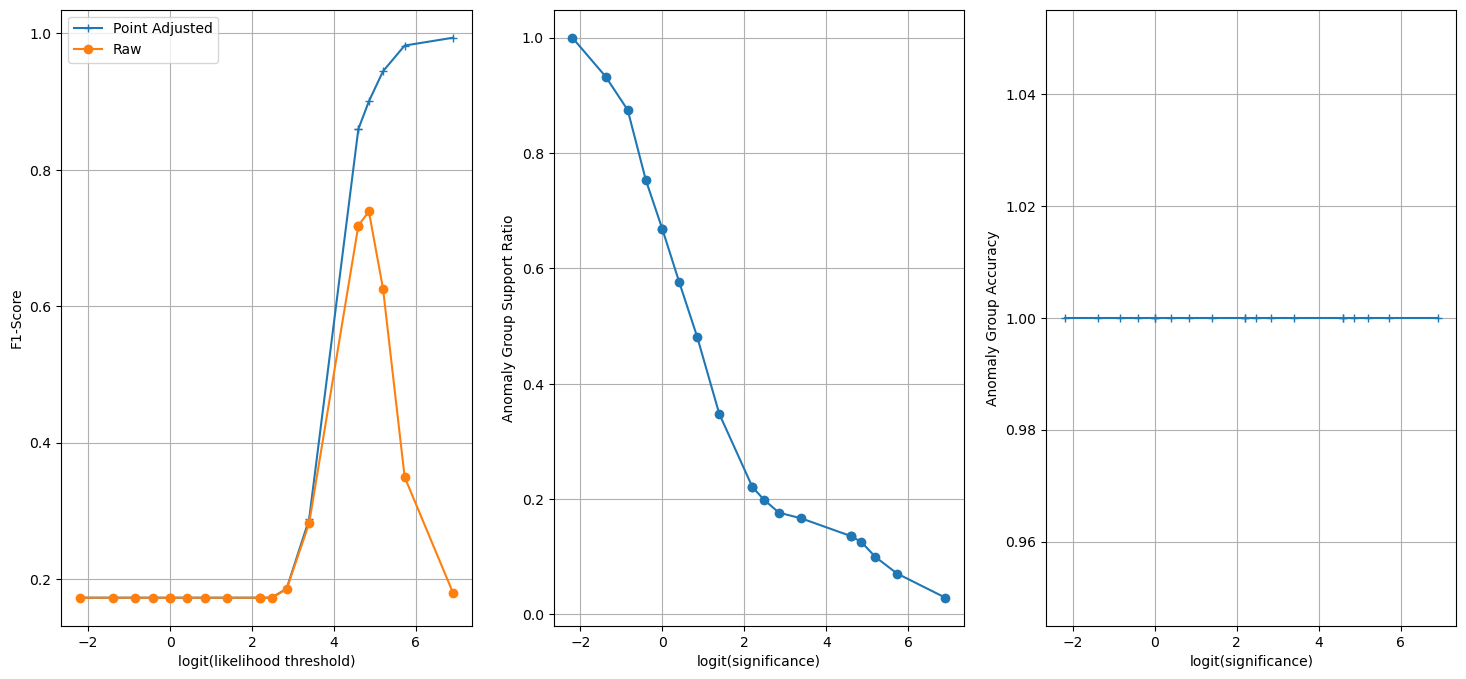

In [ ]:
sigs = list(np.linspace(0.1, 0.5, 5)) + list(np.linspace(0.5, 0.9, 5)) + list(np.linspace(0.9, 0.99, 5))+list(np.linspace(0.99, 0.999, 5))

F1_scores = []
F1_scores_PA = []
Group_accuracy = []
Group_support_ratios = []

for i, sig in tqdm(enumerate(sigs), total=len(sigs)):
    # rachitas_scores, rachitas_detection = rachitas_thresholder(lr_sts, G, sig=sig)
    q = np.quantile(likelihood, sig)
    det = np.zeros(likelihood.shape)
    det[likelihood > q] = 1
    rachitas_detection = mchannel.anomaly_detection_score(det)
    F1_scores.append(rachitas_detection['f1'])
    F1_scores_PA.append(rachitas_detection['PA_F1'])
    Group_accuracy.append(rachitas_detection['group_accuracy'])
    Group_support_ratios.append(rachitas_detection['group_support_ratio'])

logit_sig = np.log((np.array(sigs)/(1-np.array(sigs))))
fig, axes = plt.subplots(1,3, figsize=(18, 8))
axes[0].plot(logit_sig, F1_scores_PA, marker='+', label='Point Adjusted')
axes[0].plot(logit_sig, F1_scores, marker='o', label='Raw')
axes[0].set_ylabel('F1-Score')
axes[0].set_xlabel('logit(likelihood threshold)');
axes[0].legend()

axes[2].plot(logit_sig, Group_accuracy, marker='+')
axes[2].set_ylabel('Anomaly Group Accuracy')
axes[2].set_xlabel('logit(significance)');

axes[1].plot(logit_sig, Group_support_ratios, marker='o')
axes[1].set_ylabel('Anomaly Group Support Ratio')
axes[1].set_xlabel('logit(significance)');
[axe.grid() for axe in axes];

## LR-SSS HP-Study

In [ ]:
gtvr_config = [ { 'graph': 'spatial',
                    'mode': [1],
                    'variation_type': 'GTMV',
                    'p': 1,
                    'normalization': 'none'
                    }]

max_iter = 5000
lda_f = 330 # Kinda random
rho = 0.1

def lr_sss_df(lr_sss, G):
    """Estimate degrees of freedom naively for LR-SSS model"""
    # Gto = Gt.to_directed()
    I = torch.diag(torch.ones(G.number_of_nodes(), device=lr_sss.device, dtype=lr_sss.dtype))
    BT = torch.tensor(nx.laplacian_matrix(G, nodelist=sorted(G.nodes())).todense(),
                 device=lr_sss.device, dtype=lr_sss.dtype).T
    # print(I.shape, BT.shape)
    D = torch.vstack([BT, I])
    # print(D.shape)

    V_sum = lr_sss.V.sum(dim=0, keepdim=False).coalesce().to_dense()
    S_ = tensorize(V_sum, lr_sss.Y.shape, lr_sss.graph_modes)
    S_ = matricize(S_, [1])

    nonzero_edge = (lr_sss.Ws[0].T!=0) 
    nonzero_node = (S_.T!=0)
    # print(f"nonzero_node shape: {nonzero_node.shape}, nonzero_edge shape: {nonzero_edge.shape}")
    Bindices = torch.hstack([nonzero_edge, nonzero_node])
    # print(f"Bindices shape: {Bindices.shape}")
    
    df = calculate_df_naive(Bindices, D)
    return df.item()


def lr_sss_objective(trial):
    lda = trial.suggest_float("lda", 0.001, 20, log=True)
    psis = [trial.suggest_float(f"psi_{i}", 0.01, 20, log=True) for i in range(1, 5)]
    lda_s = trial.suggest_float("lda_s", 1e-6, 0.1, log=True)
    lr_sss= SNN__LOGN_GTV(Y, G, lr_modes=[1,2,3,4], graph_modes=[1], gtvr_config=gtvr_config,
                      grouping='neighbor', r_hop=0,
                      soft_constrained=True, device='cuda:2', verbose=False)

    X, S = lr_sss(psis=psis, lda=lda, lda_gtvs=[lda_s], lda_f=lda_f,
                  rho_update='domain_parametrization', max_iter=max_iter, rho=rho, tol=1e-4)
    
    V_sum = lr_sss.V.sum(dim=0, keepdim=False).coalesce().to_dense()
    S_ = tensorize(V_sum, lr_sss.Y.shape, lr_sss.graph_modes)

    results = {}
    num_parameter = lr_sss.num_parameters()
    results['num_parameter_X'] = num_parameter['X']
    results['num_parameter_S'] = lr_sss_df(lr_sss, G)
    results['num_parameters'] = num_parameter['X'] + results['num_parameter_S']
    diff = len(lr_sss.Y.ravel()) - results['num_parameters']
    
    results['gcv'] = (torch.linalg.norm(lr_sss.Y - X - S)/ max(1, diff))**2
    
    results['gcv'] = results['gcv'].item()
    scoring_scores = mchannel.anomaly_scoring_score(lr_sss.S.abs())

    V_sum = lr_sss.V.sum(dim=0, keepdim=False).coalesce().to_dense()
    labels = tensorize(V_sum, lr_sss.Y.shape, lr_sss.graph_modes)!=0

    detection_scores = mchannel.anomaly_detection_score(labels)

    results['au_prc'] = scoring_scores['au_prc']
    results['au_roc'] = scoring_scores['au_roc']
    
    results = {**results, **detection_scores}
    

    for key, value in results.items():
        trial.set_user_attr(key, value)
    # trial.set_user_attr("metrics", results)
    return results['gcv']
    
study = optuna.study.create_study(study_name=f'smd_lr_sss_M{mchannel.machine_id}_Ch{mchannel.channel_id}_gcv_ow2',
                                  direction='minimize', storage='sqlite:///smd_lr_sss.db',
                                  load_if_exists=True)

study.optimize(lr_sss_objective, n_trials=13, show_progress_bar=True)

[I 2025-07-23 06:39:26,591] Using an existing study with name 'smd_lr_sss_M2_Ch1_gcv_ow2' instead of creating a new one.


  0%|          | 0/13 [00:00<?, ?it/s]

/mnt/ffs24/home/indibimu/repos/ML_GSP/src/proximal_ops/prox_overlapping_grouped_l21.py:405: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647378361/work/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  G_ind = torch.sparse_csr_tensor(A_r.indptr, A_r.indices, A_r.data, device=device, dtype=dtype)


[I 2025-07-23 06:40:49,494] Trial 90 finished with value: 8.44702994577026e-16 and parameters: {'lda': 0.0013557528616758626, 'psi_1': 0.298745668074641, 'psi_2': 6.922083199141414, 'psi_3': 5.804009478406757, 'psi_4': 3.612364432035893, 'lda_s': 0.002414277530849966}. Best is trial 23 with value: 2.965168518554115e-19.
[I 2025-07-23 06:42:07,531] Trial 91 finished with value: 1.0789918052007828e-18 and parameters: {'lda': 0.0018241994201109335, 'psi_1': 1.6672062657220574, 'psi_2': 18.19994831212684, 'psi_3': 14.26143317067226, 'psi_4': 1.2998491382895905, 'lda_s': 2.593754828914597e-06}. Best is trial 23 with value: 2.965168518554115e-19.
[I 2025-07-23 06:43:24,506] Trial 92 finished with value: 5.470925059744438e-19 and parameters: {'lda': 0.00124607338468325, 'psi_1': 1.2577663117315958, 'psi_2': 5.499513586853631, 'psi_3': 18.63477679618846, 'psi_4': 9.621469514835464, 'lda_s': 9.354273857690979e-06}. Best is trial 23 with value: 2.965168518554115e-19.
[I 2025-07-23 06:44:41,819] 

In [ ]:
best_trial = study.best_trial
print("Best trial:", best_trial.number)
best_parameters = study.best_params
print("Best parameters:", best_parameters)
metrics = study.best_trial.user_attrs
print("Best metrics:")
pprint(metrics)

# {'lda': 0.0010861530181705032, 'psi_1': 0.012251197825620714, 'psi_2': 19.75430606731106, 'psi_3': 0.5394026917064496, 'psi_4': 0.01177984982155567, 'lda_s': 8.292240199942316e-06}

Best trial: 23
Best parameters: {'lda': 0.0010087834271477107, 'psi_1': 1.6502636035057234, 'psi_2': 4.331938492636628, 'psi_3': 5.138719247626605, 'psi_4': 1.2418718814972458, 'lda_s': 1.3181109711688323e-06}
Best metrics:
{'au_prc': 0.12017332480102982,
 'au_roc': 0.6757944042973345,
 'f1': 0.09411196911196912,
 'gcv': 2.965168518554115e-19,
 'group_accuracy': 1.0,
 'group_support_ratio': 0.9906743684320412,
 'num_parameter_S': 369,
 'num_parameter_X': 0.0,
 'num_parameters': 369.0,
 'precision': 0.049379589769561916,
 'raw_F1': 0.09411196911196912,
 'raw_precision': 0.049379589769561916,
 'raw_recall': 1.0,
 'recall': 1.0}


In [ ]:
gtvr_config = [ { 'graph': 'spatial',
                    'mode': [1],
                    'variation_type': 'GTMV',
                    'p': 1,
                    'normalization': 'none'
                    }]

max_iter = 5000
lda_f = 330 # Kinda random
rho = 0.1

# best_parameters = {'lda': 0.0010087834271477107, 'psi_1': 1.6502636035057234, 'psi_2': 4.331938492636628, 'psi_3': 5.138719247626605, 'psi_4': 1.2418718814972458, 'lda_s': 1.3181109711688323e-06}
lr_sss= SNN__LOGN_GTV(Y, G, lr_modes=[1,2,3,4], graph_modes=[1], gtvr_config=gtvr_config,
                      grouping='neighbor', r_hop=0,
                      soft_constrained=True, device='cuda:1', verbose=False)

X, S = lr_sss(psis=[best_parameters[f'psi_{i}'] for i in range(1, 5)],
            lda=best_parameters['lda'], lda_gtvs=[best_parameters['lda_s']], lda_f=lda_f,
            rho_update='domain_parametrization', max_iter=max_iter, rho=rho, tol=1e-4)
    
V_sum = lr_sss.V.sum(dim=0, keepdim=False).coalesce().to_dense()
S_ = tensorize(V_sum, lr_sss.Y.shape, lr_sss.graph_modes)

In [ ]:
# likelihood = rachitas_thresholder(lr_sss, G)

q = np.quantile(likelihood, 0.999)
det = np.zeros(likelihood.shape)
det[likelihood > q] = 1

scoring_scores = mchannel.anomaly_scoring_score(S.abs())
detection_scores = mchannel.anomaly_detection_score(S_!=0)

rachitas_scores = mchannel.anomaly_scoring_score(likelihood)
rachitas_detection = mchannel.anomaly_detection_score(det)

print("Raw Anomaly Scoring Performance:\n", '='*20)
print(' -> AU-PRC:', scoring_scores['au_prc'])
print(' -> AU-ROC:', scoring_scores['au_roc'])
print(' -> Precision: ', detection_scores['precision'], '\t| P.A Precision: ', detection_scores['PA_precision'])
print(' -> Recall: ', detection_scores['recall'], '\t\t\t| P.A Recall: ', detection_scores['PA_recall'])
print(' -> F1-Score: ', detection_scores['f1'], '\t| P.A F1-Score: ', detection_scores['PA_F1'])
print(' -> Group-wise Accuracy: ', detection_scores['group_accuracy'])
print(' -> Group-support Ratio: ', detection_scores['group_support_ratio'])
print(' '*20)
print("Rachitas Likelihood Conversion Scores:\n", '='*20)
print(' -> AU-PRC:', rachitas_scores['au_prc'])
print(' -> AU-ROC:', rachitas_scores['au_roc'])
print(' -> Precision: ', rachitas_detection['precision'], '\t| P.A Precision: ', rachitas_detection['PA_precision'])
print(' -> Recall: ', rachitas_detection['recall'], '\t| P.A Recall: ', rachitas_detection['PA_recall'])
print(' -> F1-Score: ', rachitas_detection['f1'], '\t| P.A F1-Score: ', rachitas_detection['PA_F1'])
print(' -> Group-wise Accuracy: ', rachitas_detection['group_accuracy'])
print(' -> Group-support Ratio: ', rachitas_detection['group_support_ratio'])

Raw Anomaly Scoring Performance:
 -> AU-PRC: 0.12017332480102982
 -> AU-ROC: 0.6757944042973345
 -> Precision:  0.049379589769561916 	| P.A Precision:  0.049379589769561916
 -> Recall:  1.0 			| P.A Recall:  1.0
 -> F1-Score:  0.09411196911196912 	| P.A F1-Score:  0.09411196911196912
 -> Group-wise Accuracy:  1.0
 -> Group-support Ratio:  0.9906743684320412
                    
Rachitas Likelihood Conversion Scores:
 -> AU-PRC: 0.1681039558466237
 -> AU-ROC: 0.6618844173053018
 -> Precision:  0.2978369384359401 	| P.A Precision:  0.7349246231155779
 -> Recall:  0.152991452991453 	| P.A Recall:  1.0
 -> F1-Score:  0.20214568040654998 	| P.A F1-Score:  0.8472121650977552
 -> Group-wise Accuracy:  1.0
 -> Group-support Ratio:  0.022270164938409075


/mnt/ffs24/home/indibimu/repos/ML_GSP/src/proximal_ops/prox_overlapping_grouped_l21.py:405: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647378361/work/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  G_ind = torch.sparse_csr_tensor(A_r.indptr, A_r.indices, A_r.data, device=device, dtype=dtype)


It-0 	# |r| = 3.8238e+02 	|s| = 2.5491e-04 	 obj = 1.0830e-10 	 0.206 sec.
It-1 	# |r| = 3.8222e+02 	|s| = 1.5527e-03 	 obj = 6.0887e-09 	 0.012 sec.
It-2 	# |r| = 2.9295e+02 	|s| = 1.9344e+00 	 obj = 1.5496e+03 	 0.012 sec.
It-3 	# |r| = 1.2031e+02 	|s| = 5.3354e+00 	 obj = 5.8741e+03 	 0.012 sec.
It-4 	# |r| = 1.2010e+02 	|s| = 2.7934e-02 	 obj = 5.8703e+03 	 0.012 sec.
It-5 	# |r| = 1.0142e+02 	|s| = 4.9241e+00 	 obj = 6.4916e+03 	 0.013 sec.
It-6 	# |r| = 9.1424e+01 	|s| = 4.1212e+00 	 obj = 7.0910e+03 	 0.012 sec.
It-7 	# |r| = 7.5740e+01 	|s| = 7.5958e+00 	 obj = 7.9037e+03 	 0.012 sec.
It-8 	# |r| = 5.8252e+01 	|s| = 8.5135e+00 	 obj = 9.2991e+03 	 0.012 sec.
It-9 	# |r| = 4.1926e+01 	|s| = 7.0398e+00 	 obj = 1.0572e+04 	 0.012 sec.
It-10 	# |r| = 3.0698e+01 	|s| = 8.9300e+00 	 obj = 1.1458e+04 	 0.012 sec.
It-11 	# |r| = 2.4589e+01 	|s| = 5.2363e+00 	 obj = 1.1880e+04 	 0.012 sec.
It-12 	# |r| = 2.0356e+01 	|s| = 4.0139e+00 	 obj = 1.2177e+04 	 0.012 sec.
It-13 	# |r| = 1.5912e

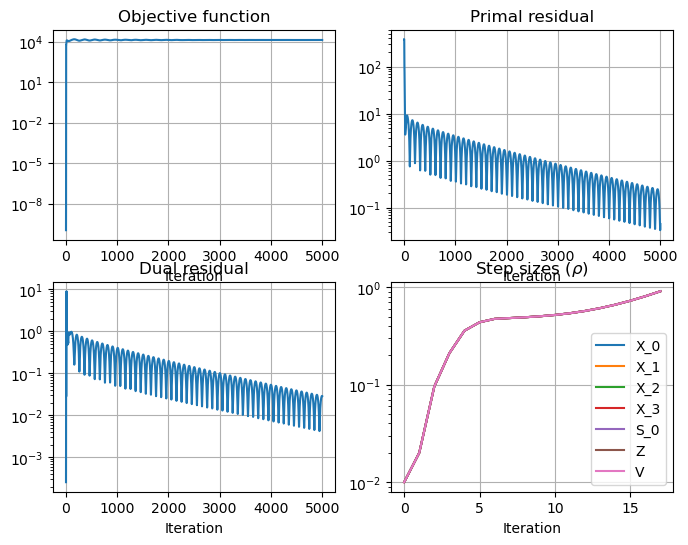

In [ ]:
G = nx.Graph()
G.add_nodes_from(range(38))
Gt = nx.grid_graph(dim=(day_folding[1],))

lda_f= 300
var = 1/lda_f
rho = 0.01
t=0.001
horpca= SNN__LOGN_GTV(Y, G, lr_modes=[1,2,3,4], graph_modes=[1], gtvr_config=[],
                      grouping='neighbor', r_hop=0,
                      soft_constrained=True, device='cuda:1', verbose=True)

X, S = horpca(psis=[8.11]*4, lda=1.2, lda_gtvs=[],
              lda_f=lda_f,
              max_iter=5000, rho=rho, rho_update='domain_parametrization', tol=1e-4)
horpca.plot_alg_run(figsize=(8,6));
print(horpca.num_parameters())

In [ ]:
scoring_scores = mchannel.anomaly_scoring_score(horpca.S.abs())

V_sum = horpca.V.sum(dim=0, keepdim=False).coalesce().to_dense()
labels = tensorize(V_sum, horpca.Y.shape, horpca.graph_modes)!=0

detection_scores = mchannel.anomaly_detection_score(labels)

print("Anomaly Scoring Scores:")
print("\t AU-PRC:", scoring_scores['au_prc'])
print("\t AU-ROC:", scoring_scores['au_roc'])
print("Anomaly Detection Scores:")
# pprint(detection_scores)
pd.DataFrame(detection_scores, index=[0],
             columns=['raw_F1', 'raw_precision', 'raw_recall',
                      'group_accuracy', 'group_support_ratio',
                      'f1', 'precision', 'recall'])

Anomaly Scoring Scores:
	 AU-PRC: 0.15340567123038595
	 AU-ROC: 0.634941266827255
Anomaly Detection Scores:


,raw_F1,raw_precision,raw_recall,group_accuracy,group_support_ratio,f1,precision,recall
0,0.198113,0.256098,0.161538,1.0,0.02394,0.809969,0.680628,1.0


In [ ]:
lbls = labels[mchannel.og_mask.any(axis=0, keepdims=True)].ravel()
lbl_mask = mchannel.og_mask.any(axis=0, keepdims=True)

G = nx.Graph()
G.add_nodes_from(range(38))
Gt = nx.grid_graph(dim=(day_folding[1],))

lda_f= 330
var = 1/lda_f # 0.0003#9.0e-5#1/lda_f
# lda_f = 1/var
rho = 0.1

t_range = np.linspace(0, 1, 40)
num_parameters = np.zeros(len(t_range))
num_param_Xs = np.zeros(len(t_range))
num_param_Ss = np.zeros(len(t_range))
nlls = np.zeros(len(t_range))
bic_score = np.zeros(len(t_range))
aic_score = np.zeros(len(t_range))
f1_scores = np.zeros(len(t_range))
precision_scores = np.zeros(len(t_range))
recall_scores = np.zeros(len(t_range))
au_roc_scores = np.zeros(len(t_range))
au_prc_scores = np.zeros(len(t_range))

for i, t in tqdm(enumerate(t_range), total=len(t_range)):
    horpca= SNN__LOGN_GTV(Y, G, lr_modes=[1,2,3,4], graph_modes=[1], gtvr_config=[],
                      grouping='neighbor', r_hop=0,
                      soft_constrained=True, device='cuda:1', verbose=False)

    X, S = horpca(psis=[(1-t)]*4, lda=t, lda_gtvs=[], lda_f=lda_f, max_iter=250,
                  rho_update='domain_parametrization', rho=rho,tol=1e-4)
    
    V_sum = horpca.V.sum(dim=0, keepdim=False).coalesce().to_dense()
    S_ = tensorize(V_sum, horpca.Y.shape, horpca.graph_modes)

    num_parameter = horpca.num_parameters()
    num_param_Xs[i] = num_parameter['X']
    num_param_Ss[i] = num_parameter['S']
    num_parameters[i] = num_parameter['X'] + num_parameter['S']
    nlls[i] = (np.prod(Y.shape)*0.5*np.log(2*np.pi*var)) +(0.5/var)*torch.norm(torch.tensor(Y,device='cuda:1')-X-S, p='fro').cpu().item()**2
    bic_score[i] = 2*nlls[i] + num_parameters[i]*np.log(np.prod(Y.shape))
    aic_score[i] = 2*nlls[i] + 2*num_parameters[i]

    f1_scores[i] = f1_score(lbls, (S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
    precision_scores[i] = precision_score(lbls,(S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
    recall_scores[i] = recall_score(lbls, (S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
    au_roc_scores[i] = roc_auc_score(lbls, S.abs().sum(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
    p, r, th = precision_recall_curve(lbls, S.abs().sum(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
    au_prc_scores[i] = auc(r, p)

 12%|█▎        | 5/40 [00:29<03:28,  5.97s/it]/mnt/home/indibimu/anaconda3_ubuntu/envs/ML_GSP/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
 15%|█▌        | 6/40 [00:35<03:22,  5.97s/it]/mnt/home/indibimu/anaconda3_ubuntu/envs/ML_GSP/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
 18%|█▊        | 7/40 [00:41<03:16,  5.96s/it]/mnt/home/indibimu/anaconda3_ubuntu/envs/ML_GSP/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and

Optimal t: 0.8461538461538461


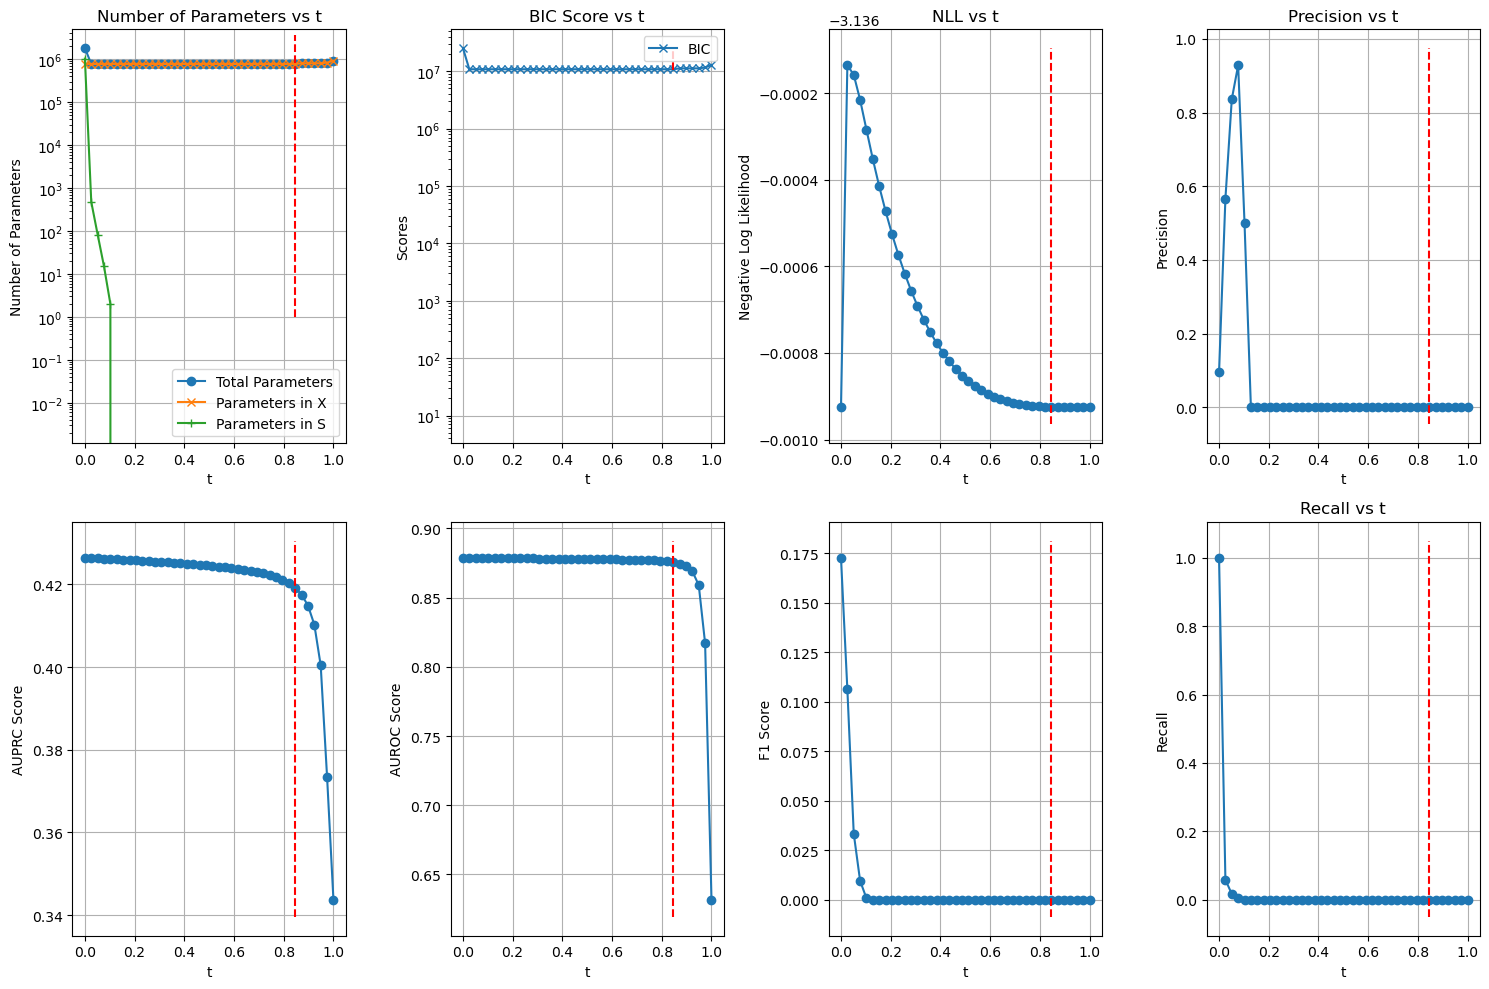

In [ ]:
t = t_range[np.argmin(bic_score)]
print("Optimal t:", t)

fig, axe = plt.subplots(2, 4, figsize=(15, 10))
axe[0, 0].semilogy(t_range, num_parameters, marker='o', label='Total Parameters')
axe[0, 0].semilogy(t_range, num_param_Xs, marker='x', label='Parameters in X')
axe[0, 0].semilogy(t_range, num_param_Ss, marker='+', label='Parameters in S')
axe[0, 0].set_xlabel('t')
axe[0, 0].set_ylabel('Number of Parameters')
axe[0, 0].set_title('Number of Parameters vs t')
axe[0, 0].legend()
# axe[0, 1].semilogy(t_range, aic_score, marker='o', label='AIC')
axe[0, 1].semilogy(t_range, bic_score, marker='x', label='BIC')
axe[0, 1].legend()
axe[0, 1].set_xlabel('t')
axe[0, 1].set_ylabel('Scores')
axe[0, 1].set_title('BIC Score vs t')
axe[0, 2].plot(t_range, nlls, marker='o')
axe[0, 2].set_xlabel('t')
axe[0, 2].set_ylabel('Negative Log Likelihood')
axe[0, 2].set_title('NLL vs t')
axe[0, 3].plot(t_range, precision_scores, marker='o')
axe[0, 3].set_xlabel('t')
axe[0, 3].set_ylabel('Precision')
axe[0, 3].set_title('Precision vs t')
axe[1, 0].plot(t_range, au_prc_scores, marker='o')
axe[1, 0].set_xlabel('t')
axe[1, 0].set_ylabel('AUPRC Score')
axe[1, 1].plot(t_range, au_roc_scores, marker='o')
axe[1, 1].set_xlabel('t')
axe[1, 1].set_ylabel('AUROC Score')
axe[1, 2].plot(t_range, f1_scores, marker='o')
axe[1, 2].set_xlabel('t')
axe[1, 2].set_ylabel('F1 Score')
axe[1, 3].plot(t_range, recall_scores, marker='o')
axe[1, 3].set_xlabel('t')
axe[1, 3].set_ylabel('Recall')
axe[1, 3].set_title('Recall vs t')

axes = axe.flatten()
for ax in axes:
    ax.grid(True)
    ax.vlines([t], *ax.get_ylim(), colors='r', linestyles='dashed', label='Optimal t')
fig.tight_layout()



In [ ]:
lbls = labels[mchannel.og_mask.any(axis=0, keepdims=True)].ravel()
lbl_mask = mchannel.og_mask.any(axis=0, keepdims=True)

G = nx.Graph()
G.add_nodes_from(range(38))
Gt = nx.grid_graph(dim=(day_folding[1],))

lda_f= 330
var = 1/lda_f#0.0003#9.0e-5#1/lda_f
# lda_f = 1/var
rho = 0.1

psi_range = np.logspace(-1, 2, 12)
lda1_range = np.logspace(-2, 1, 10)
shp = (len(psi_range), len(lda1_range))
num_parameters = np.zeros(shp)
num_param_Xs = np.zeros(shp)
num_param_Ss = np.zeros(shp)
nlls = np.zeros(shp)
bic_score = np.zeros(shp)
aic_score = np.zeros(shp)
f1_scores = np.zeros(shp)
precision_scores = np.zeros(shp)
recall_scores = np.zeros(shp)
au_roc_scores = np.zeros(shp)
au_prc_scores = np.zeros(shp)

for i, psi in tqdm(enumerate(psi_range), total=len(psi_range)):
    for j, lda1 in tqdm(enumerate(lda1_range), total=len(lda1_range)):
        horpca= SNN__LOGN_GTV(Y, G, lr_modes=[1,2,3,4], graph_modes=[1], gtvr_config=[],
                        grouping='neighbor', r_hop=0,
                        soft_constrained=True, device='cuda:1', verbose=False)

        X, S = horpca(psis=[psi]*4, lda=lda1, lda_gtvs=[], lda_f=lda_f, max_iter=250,
                    rho_update='domain_parametrization', rho=rho,tol=1e-4)
        
        V_sum = horpca.V.sum(dim=0, keepdim=False).coalesce().to_dense()
        S_ = tensorize(V_sum, horpca.Y.shape, horpca.graph_modes)

        num_parameter = horpca.num_parameters()
        num_param_Xs[i,j] = num_parameter['X']
        num_param_Ss[i,j] = num_parameter['S']
        num_parameters[i,j] = num_parameter['X'] + num_parameter['S']
        nlls[i,j] = (np.prod(Y.shape)*0.5*np.log(2*np.pi*var)) +(0.5/var)*torch.norm(torch.tensor(Y,device='cuda:1')-X-S, p='fro').cpu().item()**2
        bic_score[i,j] = 2*nlls[i,j] + num_parameters[i,j]*np.log(np.prod(Y.shape))
        aic_score[i,j] = 2*nlls[i,j] + 2*num_parameters[i,j]

        f1_scores[i,j] = f1_score(lbls, (S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
        precision_scores[i,j] = precision_score(lbls,(S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
        recall_scores[i,j] = recall_score(lbls, (S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
        au_roc_scores[i,j] = roc_auc_score(lbls, S.abs().sum(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
        p, r, th = precision_recall_curve(lbls, S.abs().sum(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
        au_prc_scores[i,j] = auc(r, p)

  0%|          | 0/12 [00:00<?, ?it/s]/mnt/ffs24/home/indibimu/repos/ML_GSP/src/proximal_ops/prox_overlapping_grouped_l21.py:405: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647378361/work/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  G_ind = torch.sparse_csr_tensor(A_r.indptr, A_r.indices, A_r.data, device=device, dtype=dtype)
/mnt/home/indibimu/anaconda3_ubuntu/envs/ML_GSP/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/home/indibimu/anaconda3_ubuntu/envs/ML_GSP/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: 

KeyboardInterrupt: 

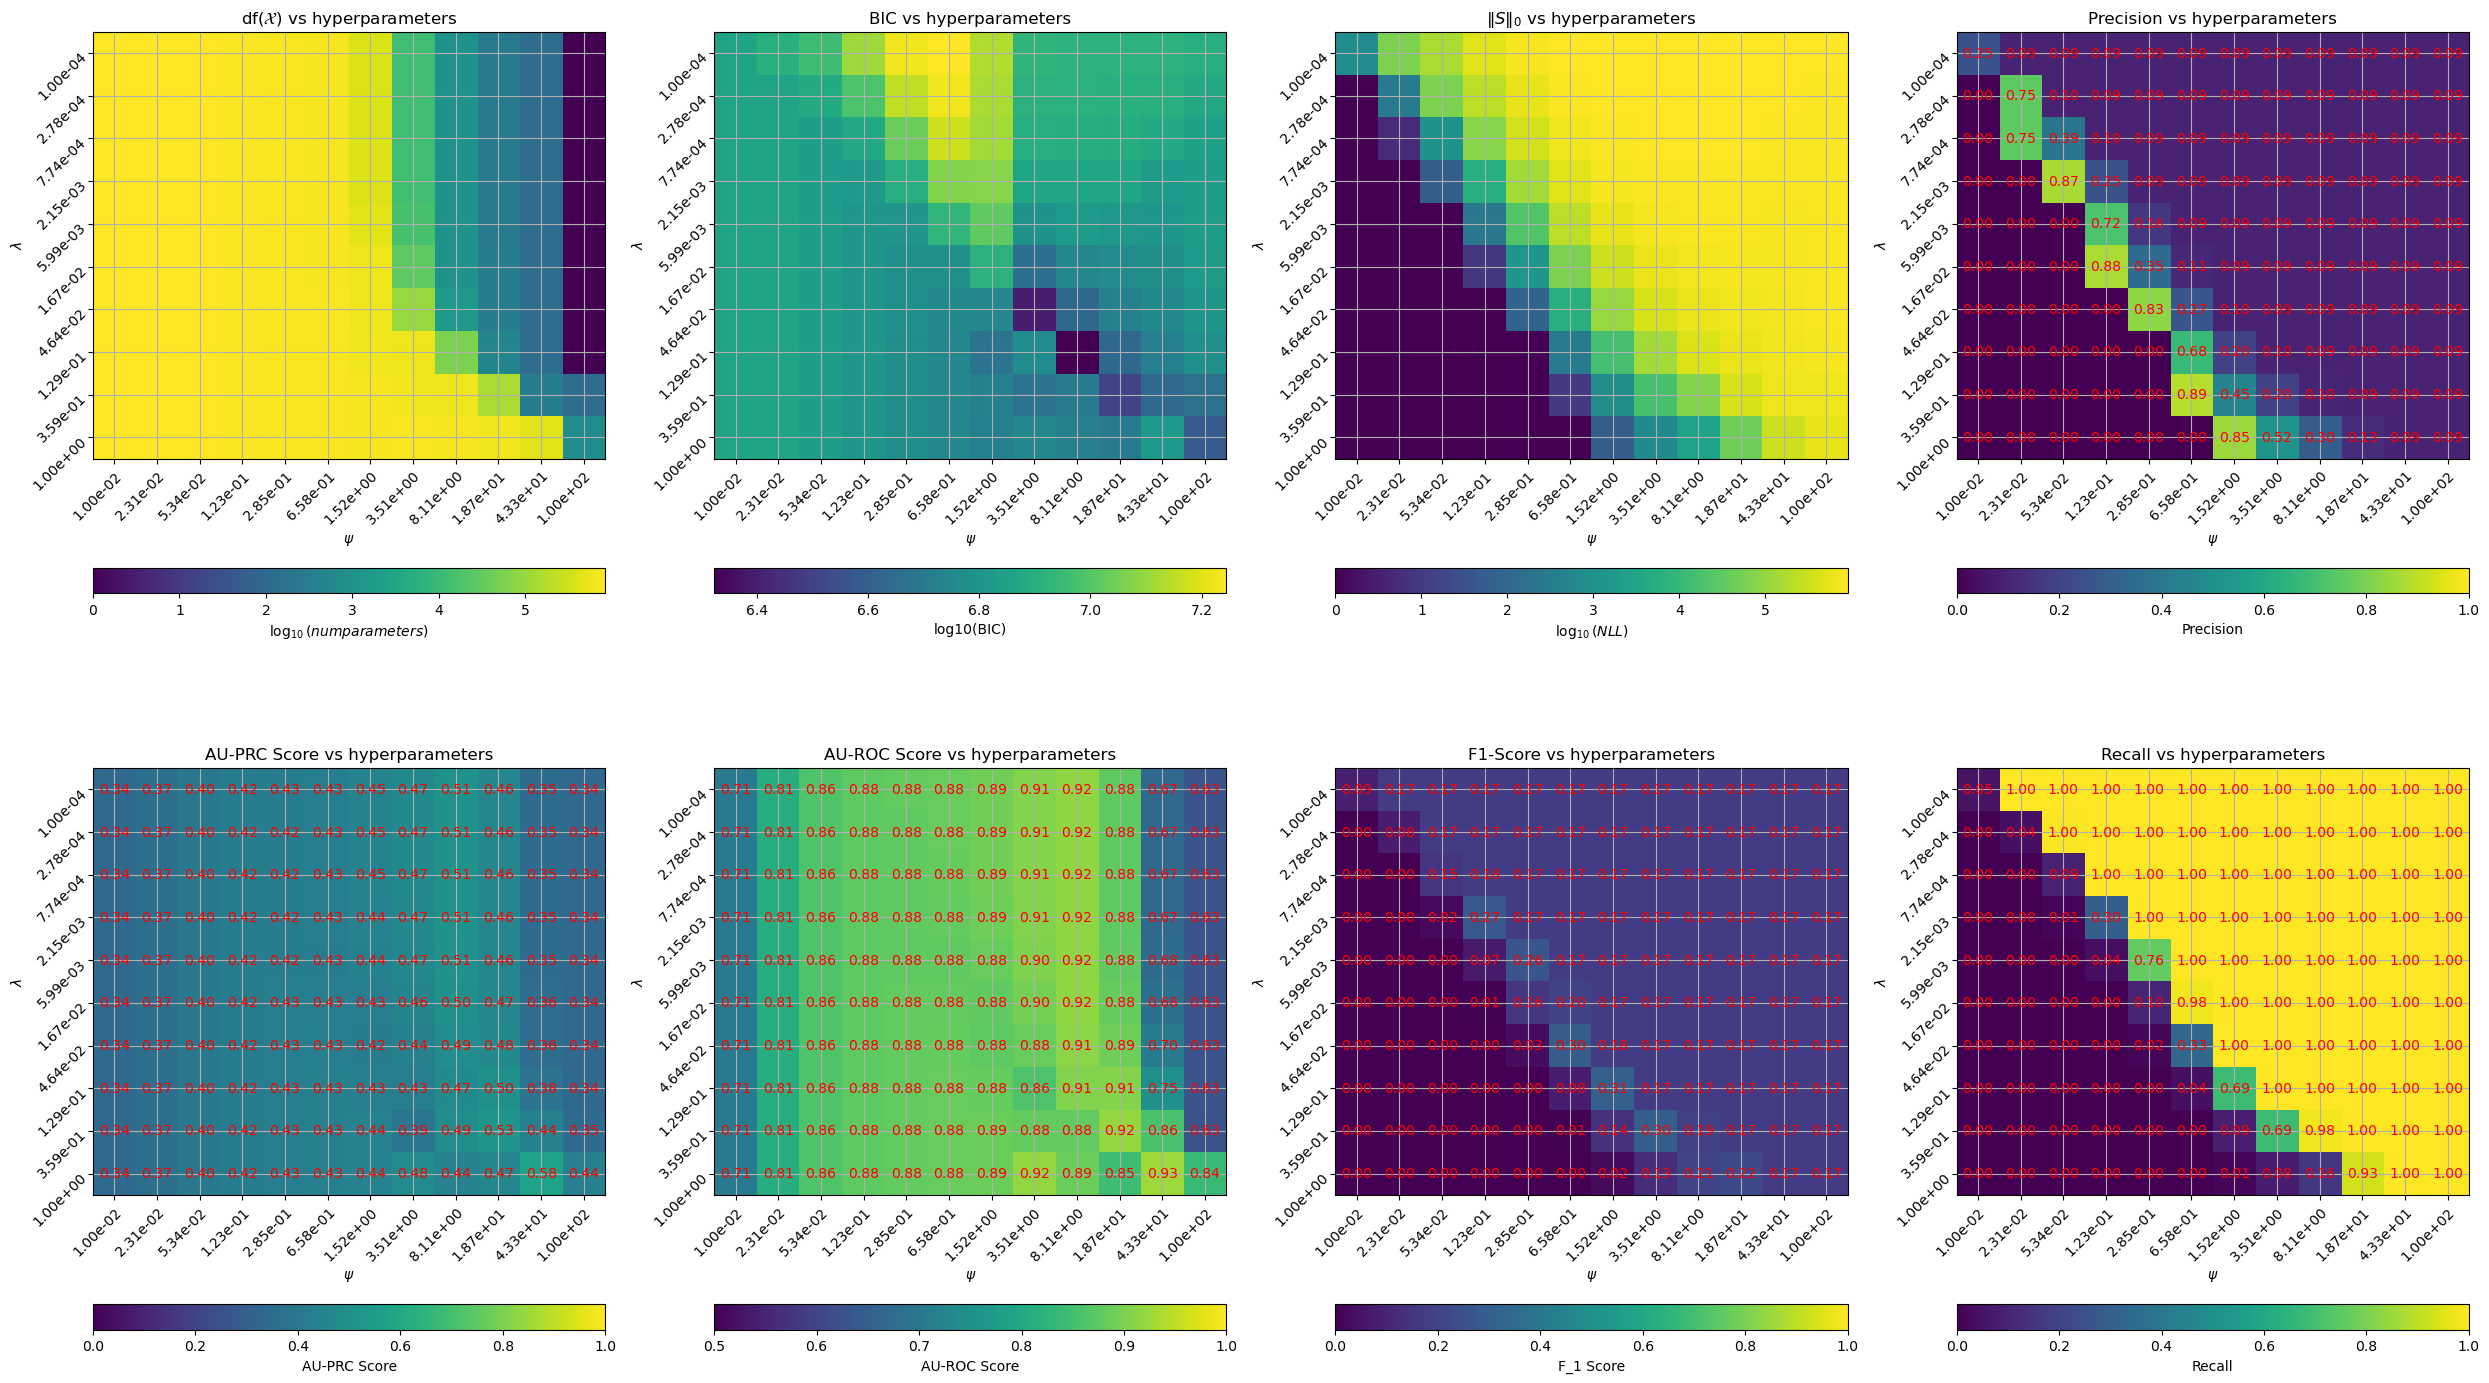

In [ ]:
# t = t_range[np.argmin(bic_score)]
# print("Optimal t:", t)

PSI, LDA1 = np.meshgrid(np.log10(psi_range), np.log10(lda1_range))
fig, axe = plt.subplots(2, 4, figsize=(25, 15))
pos = axe[0, 0].imshow(np.log10(num_param_Xs.T+1))#, color='C0', label='BIC')
axe[0, 0].set_xlabel(r'$\psi$')
axe[0, 0].set_ylabel(r'$\lambda$')
axe[0, 0].set_title(r'$\mathrm{df}(\mathcal{X})$ vs hyperparameters')
fig.colorbar(pos, ax=axe[0, 0], orientation='horizontal', label=r'$\log_{10}(num parameters)$')

pos = axe[0, 1].imshow(np.log10(bic_score.T))#, color='C0', label='BIC')
axe[0, 1].set_xlabel(r'$\psi$')
axe[0, 1].set_ylabel(r'$\lambda$')
axe[0, 1].set_title('BIC vs hyperparameters')
fig.colorbar(pos, ax=axe[0, 1], orientation='horizontal', label='log10(BIC)')

pos = axe[0, 2].imshow(np.log10(num_param_Ss +1).T)#, color='C0', label='BIC')
axe[0, 2].set_xlabel(r'$\psi$')
axe[0, 2].set_ylabel(r'$\lambda$')
axe[0, 2].set_title(r'$\|S\|_0$ vs hyperparameters')
fig.colorbar(pos, ax=axe[0, 2], orientation='horizontal', label=r'$\log_{10}(NLL)$')

pos = axe[0, 3].imshow(precision_scores.T, vmin=0, vmax=1)
axe[0, 3].set_xlabel(r'$\psi$')
axe[0, 3].set_ylabel(r'$\lambda$')
axe[0, 3].set_title('Precision vs hyperparameters')
fig.colorbar(pos, ax=axe[0, 3], orientation='horizontal', label=r'Precision')
for i in range(len(psi_range)):
    for j in range(len(lda1_range)):
        text = axe[0, 3].text(i, j, f'{precision_scores[i, j]:.2f}',
                       ha="center", va="center", color="r")

pos = axe[1, 0].imshow(au_prc_scores.T, vmin=0, vmax=1)
axe[1, 0].set_xlabel(r'$\psi$')
axe[1, 0].set_ylabel(r'$\lambda$')
axe[1, 0].set_title('AU-PRC Score vs hyperparameters')
fig.colorbar(pos, ax=axe[1, 0], orientation='horizontal', label=r'AU-PRC Score')
for i in range(len(psi_range)):
    for j in range(len(lda1_range)):
        text = axe[1, 0].text(i, j, f'{au_prc_scores[i, j]:.2f}',
                       ha="center", va="center", color="r")

pos = axe[1, 1].imshow(au_roc_scores.T, vmin=0.5, vmax=1)
axe[1, 1].set_xlabel(r'$\psi$')
axe[1, 1].set_ylabel(r'$\lambda$')
axe[1, 1].set_title('AU-ROC Score vs hyperparameters')
fig.colorbar(pos, ax=axe[1, 1], orientation='horizontal', label=r'AU-ROC Score')
for i in range(len(psi_range)):
    for j in range(len(lda1_range)):
        text = axe[1, 1].text(i, j, f'{au_roc_scores[i, j]:.2f}',
                       ha="center", va="center", color="r")

pos = axe[1, 2].imshow(f1_scores.T, vmin=0, vmax=1)
axe[1, 2].set_xlabel(r'$\psi$')
axe[1, 2].set_ylabel(r'$\lambda$')
axe[1, 2].set_title('F1-Score vs hyperparameters')
fig.colorbar(pos, ax=axe[1, 2], orientation='horizontal', label=r'F_1 Score')
for i in range(len(psi_range)):
    for j in range(len(lda1_range)):
        text = axe[1, 2].text(i, j, f'{f1_scores[i, j]:.2f}',
                       ha="center", va="center", color="r")

pos = axe[1, 3].imshow(recall_scores.T, vmin=0, vmax=1)
axe[1, 3].set_xlabel(r'$\psi$')
axe[1, 3].set_ylabel(r'$\lambda$')
axe[1, 3].set_title('Recall vs hyperparameters')
fig.colorbar(pos, ax=axe[1, 3], orientation='horizontal', label=r'Recall')
for i in range(len(psi_range)):
    for j in range(len(lda1_range)):
        text = axe[1, 3].text(i, j, f'{recall_scores[i, j]:.2f}',
                       ha="center", va="center", color="r")

axes = axe.flatten()
for ax in axes:
    ax.grid(True)
    ax.set_xticks(range(len(psi_range)), labels=[f'{lda:.2e}' for lda in psi_range],
              rotation=45, ha="right", rotation_mode="anchor")
    ax.set_yticks(range(len(lda1_range)), labels=[f'{lda:.2e}' for lda in lda1_range],
              rotation=45, ha="right", rotation_mode="anchor")
    # ax.vlines([t], *ax.get_ylim(), colors='r', linestyles='dashed', label='Optimal t')
fig.tight_layout()


In [ ]:
# G = nx.Graph()
# G.add_nodes_from(range(38))
Gt = nx.grid_graph(dim=(day_folding[1],))

lda_f= 330
var = 1/lda_f
rho = 0.1

lbls = labels[mchannel.og_mask.any(axis=0, keepdims=True)].ravel()
lbl_mask = mchannel.og_mask.any(axis=0, keepdims=True)

def sample_from_N_simplex(trial, N):
    """Sample a point from the N-dimensional unit simplex.
    
    Favors the points that are close to 1,0,0,...,0
    Args:
        trial: The Optuna trial object.
        N: The dimension of the simplex.
    Returns:
        A point sampled from the N-dimensional unit simplex.
    """

    thetas = np.array([trial.suggest_float(f"theta_{i}", 0, np.pi/2) for i in range(1, N)]).reshape((1, N-1))
    sin_thetas = np.concatenate([np.ones((1,1)), np.sin(thetas)], axis=1)
    cos_thetas = np.concatenate([np.cos(thetas), np.ones((1,1))], axis=1)
    x = (np.cumprod(sin_thetas, axis=1)*cos_thetas)**2
    return x


def horpca_objective(trial):
    # thetas = list(sample_from_N_simplex(trial, 5).ravel())
    # lda = thetas[0].item()
    # psis = thetas[1:]
    lda = trial.suggest_float("lda", 0.01, 20, log=True)
    psis = [trial.suggest_float(f"psi_{i}", 0.1, 20, log=True) for i in range(1, 5)]
    horpca= SNN__LOGN_GTV(Y, G, lr_modes=[1,2,3,4], graph_modes=[1], gtvr_config=[],
                      grouping='neighbor', r_hop=0,
                      soft_constrained=True, device='cuda:1', verbose=False)

    X, S = horpca(psis=psis, lda=lda, lda_gtvs=[], lda_f=lda_f,
                  rho_update='domain_parametrization', max_iter=250, rho=rho, tol=1e-4)
    
    V_sum = horpca.V.sum(dim=0, keepdim=False).coalesce().to_dense()
    S_ = tensorize(V_sum, horpca.Y.shape, horpca.graph_modes)

    results = {}
    num_parameter = horpca.num_parameters()
    results['num_parameter_X'] = num_parameter['X']
    results['num_parameter_S'] = num_parameter['S']
    results['num_parameters'] = num_parameter['X'] + num_parameter['S']
    results['NLL'] = (np.prod(Y.shape)*0.5*np.log(2*np.pi*var)) +(0.5/var)*torch.norm(torch.tensor(Y,device='cuda:1')-X-S, p='fro').cpu().item()**2
    results['bic_score']= 2*results['NLL'] + results['num_parameters']*np.log(np.prod(Y.shape))
    results['aic_score'] = 2*results['NLL'] + 2*results['num_parameters']

    results['f1_score'] = f1_score(lbls, (S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
    results['precision_scores'] = precision_score(lbls,(S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
    results['recall_scores'] = recall_score(lbls, (S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
    results['au_roc_scores'] = roc_auc_score(lbls, S.abs().sum(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
    p, r, th = precision_recall_curve(lbls, S.abs().sum(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
    results['au_prc_scores'] = auc(r, p)

    for key, value in results.items():
        trial.set_user_attr(key, value)
    # trial.set_user_attr("metrics", results)
    return results['bic_score']
    
study = optuna.study.create_study(study_name=f'smd_horpca_M{mchannel.machine_id}_Ch{mchannel.channel_id}',
                                  direction='minimize', storage='sqlite:///smd_horpca.db', load_if_exists=True)

study.optimize(horpca_objective, n_trials=100, show_progress_bar=True)

[I 2025-07-07 07:26:58,690] Using an existing study with name 'smd_horpca_M1_Ch1' instead of creating a new one.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-07-07 07:27:05,317] Trial 200 finished with value: 2482970.0872828625 and parameters: {'lda': 0.8690144777381897, 'psi_1': 8.269741871238287, 'psi_2': 0.000127818881931525, 'psi_3': 0.00037186071317336044, 'psi_4': 0.0008470896743904123}. Best is trial 165 with value: 516267.2578426851.
[I 2025-07-07 07:27:11,849] Trial 201 finished with value: 3282754.130009285 and parameters: {'lda': 1.29626549429415, 'psi_1': 11.933027256307994, 'psi_2': 0.00012970111455454375, 'psi_3': 0.00021250472336654784, 'psi_4': 0.004468084868115325}. Best is trial 165 with value: 516267.2578426851.
[I 2025-07-07 07:27:18,370] Trial 202 finished with value: 3680549.8391167987 and parameters: {'lda': 2.4462751185223874, 'psi_1': 9.38651686409033, 'psi_2': 0.00015045852451109337, 'psi_3': 0.00026254422266518964, 'psi_4': 0.0013681806620066928}. Best is trial 165 with value: 516267.2578426851.
[I 2025-07-07 07:27:24,900] Trial 203 finished with value: 3294353.8432239313 and parameters: {'lda': 0.65411837

/mnt/home/indibimu/anaconda3_ubuntu/envs/ML_GSP/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[I 2025-07-07 07:32:19,251] Trial 248 finished with value: 2478061.311142455 and parameters: {'lda': 5.77579151724087, 'psi_1': 7.557779912038301, 'psi_2': 0.00016345118707233365, 'psi_3': 0.0001500213121233845, 'psi_4': 0.010359499081370764}. Best is trial 165 with value: 516267.2578426851.
[I 2025-07-07 07:32:25,703] Trial 249 finished with value: 4082142.136976701 and parameters: {'lda': 2.0111529065771956, 'psi_1': 13.257732473160205, 'psi_2': 0.00010009703537218672, 'psi_3': 0.11506400690585747, 'psi_4': 0.001998744504631843}. Best is trial 165 with value: 516267.2578426851.
[I 2025-07-07 07:32:32,234] Trial 250 finished with value: 2077528.9317977484 and parameters: {'lda': 3.007318286146177, 'psi_1': 5.654851163695197, 'psi_2': 0.00013027820042285458, 'psi_3': 0.19286307524204443, 'psi_4': 0.0048741912347835155}. Best is trial 165 with value: 516267.2578426851.
[I 2025-07-07 07:32:38,751] Trial 251 finished with value: 2882999.975140254 and parameters: {'lda': 1.0298751234509347

...

[I 2025-07-07 07:37:08,135] Trial 292 finished with value: 6482061.062129945 and parameters: {'lda': 0.5317554964056287, 'psi_1': 0.056381486101091664, 'psi_2': 0.0001393715555947155, 'psi_3': 0.06370425532342837, 'psi_4': 0.004518988018601108}. Best is trial 165 with value: 516267.2578426851.
[I 2025-07-07 07:37:14,652] Trial 293 finished with value: 3682363.9902764084 and parameters: {'lda': 1.5481431824351317, 'psi_1': 12.191065829341612, 'psi_2': 0.0007778558950770875, 'psi_3': 0.10379978429474711, 'psi_4': 0.006738611641182727}. Best is trial 165 with value: 516267.2578426851.
[I 2025-07-07 07:37:21,152] Trial 294 finished with value: 2888947.7373113222 and parameters: {'lda': 0.8456999748722498, 'psi_1': 16.578257690781093, 'psi_2': 0.09825805986734368, 'psi_3': 0.15049329705297435, 'psi_4': 0.0026627690392816896}. Best is trial 165 with value: 516267.2578426851.


/mnt/home/indibimu/anaconda3_ubuntu/envs/ML_GSP/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[I 2025-07-07 07:37:27,739] Trial 295 finished with value: 2478060.1662802165 and parameters: {'lda': 5.528134712791145, 'psi_1': 7.206025357260347, 'psi_2': 0.0003853480117517091, 'psi_3': 0.00010061792854247807, 'psi_4': 0.0539594243341583}. Best is trial 165 with value: 516267.2578426851.
[I 2025-07-07 07:37:34,261] Trial 296 finished with value: 7903587.251521784 and parameters: {'lda': 0.013082841581980744, 'psi_1': 10.024150365306589, 'psi_2': 0.00021478792090885078, 'psi_3': 0.07721666649499728, 'psi_4': 0.0015320023922183177}. Best is trial 165 with value: 516267.2578426851.


/mnt/home/indibimu/anaconda3_ubuntu/envs/ML_GSP/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[I 2025-07-07 07:37:40,828] Trial 297 finished with value: 8483024.184856946 and parameters: {'lda': 2.6069942659086105, 'psi_1': 0.0006054249378473104, 'psi_2': 0.00016957531949467024, 'psi_3': 0.18393555587915772, 'psi_4': 0.0004931529669804524}. Best is trial 165 with value: 516267.2578426851.
[I 2025-07-07 07:37:47,391] Trial 298 finished with value: 2880130.0711962758 and parameters: {'lda': 3.3677872824744886, 'psi_1': 22.73199717260258, 'psi_2': 2.406384282617221, 'psi_3': 0.11754235819474733, 'psi_4': 0.0002744313486800579}. Best is trial 165 with value: 516267.2578426851.
[I 2025-07-07 07:37:53,958] Trial 299 finished with value: 4082547.3546683965 and parameters: {'lda': 1.9903087450464116, 'psi_1': 15.102677618676458, 'psi_2': 0.00012878755024271307, 'psi_3': 0.3194540240343964, 'psi_4': 0.017903862518731092}. Best is trial 165 with value: 516267.2578426851.


In [ ]:
df = study.trials_dataframe()
# df.plot.scatter(x='user_attrs_bic_score', y='user_attrs_num_parameters', c='user_attrs_au_prc_scores', colormap='viridis', alpha=0.5)
best_trial = study.best_trial
print("Best Trial:", best_trial.number)
print(f"  Value: {best_trial.value}")
print(f"  Params: {best_trial.params}")
print(f"  User Attributes: {best_trial.user_attrs}")
# df.plot.scatter(x='user_attrs_num_parameters', y='user_attrs_au_prc_scores')

Best Trial: 165
  Value: 516267.2578426851
  Params: {'lda': 1.5710243733981055, 'psi_1': 9.00568876323928, 'psi_2': 0.00014590336837588615, 'psi_3': 0.12521639249916575, 'psi_4': 0.00526664164425093}
  User Attributes: {'NLL': -2167572.661321592, 'aic_score': -3637387.322643184, 'au_prc_scores': 0.5064828085345774, 'au_roc_scores': 0.9067144232351383, 'bic_score': 516267.2578426851, 'f1_score': 0.20438426821405545, 'num_parameter_S': 2967, 'num_parameter_X': 345912.0, 'num_parameters': 348879.0, 'precision_scores': 0.7769607843137255, 'recall_scores': 0.11766889383815887}


In [ ]:
G = nx.Graph()
G.add_nodes_from(range(38))
Gt = nx.grid_graph(dim=(day_folding[1],))

lda_f= 330
var = 1/lda_f
rho = 0.1
psis = [9.005, 0.000146, 0.12521,  0.0052]
lda = 1.5710243733981055
gtvr_config = [ { 'graph': 'temporal',
                    'mode': [4],
                    'variation_type': 'GTV',
                    'p': 1,
                    'normalization': 'none'}]

lbls = labels[mchannel.og_mask.any(axis=0, keepdims=True)].ravel()
lbl_mask = mchannel.og_mask.any(axis=0, keepdims=True)

lr_sts = SNN__LOGN_GTV(Y, G, lr_modes=[1,2,3,4], graph_modes=[1], gtvr_config=gtvr_config,
                      grouping='neighbor', r_hop=0,
                      soft_constrained=True, device='cuda:1', verbose=True)

X, S = lr_sts(psis=psis, lda=lda, lda_gtvs=[1e-4], lda_f=lda_f,
                  rho_update='domain_parametrization', max_iter=1000, rho=rho, err_tol=0.01)

It-0 	# |r| = 1.1343e+02 	|s| = 4.3977e+01 	 obj = 1.3312e+03 	 0.027 sec.
It-1 	# |r| = 6.8666e+01 	|s| = 4.2410e+00 	 obj = 2.1455e+03 	 0.026 sec.
It-2 	# |r| = 5.2550e+01 	|s| = 1.1409e+00 	 obj = 2.3638e+03 	 0.026 sec.
It-3 	# |r| = 4.4443e+01 	|s| = 1.3142e+00 	 obj = 2.6152e+03 	 0.026 sec.
It-4 	# |r| = 2.8180e+01 	|s| = 1.9067e+00 	 obj = 2.8632e+03 	 0.026 sec.
It-5 	# |r| = 2.7124e+01 	|s| = 5.1820e-01 	 obj = 2.9303e+03 	 0.026 sec.
It-6 	# |r| = 2.7086e+01 	|s| = 1.2300e-02 	 obj = 2.9295e+03 	 0.026 sec.
It-7 	# |r| = 2.7042e+01 	|s| = 1.4999e-02 	 obj = 2.9287e+03 	 0.026 sec.
It-8 	# |r| = 2.2881e+01 	|s| = 7.4524e-01 	 obj = 3.0096e+03 	 0.026 sec.
It-9 	# |r| = 2.1811e+01 	|s| = 5.5362e-01 	 obj = 3.0695e+03 	 0.026 sec.
It-10 	# |r| = 2.1758e+01 	|s| = 2.2673e-02 	 obj = 3.0685e+03 	 0.025 sec.
It-11 	# |r| = 1.8684e+01 	|s| = 9.7183e-01 	 obj = 3.1567e+03 	 0.026 sec.
It-12 	# |r| = 1.8590e+01 	|s| = 1.1596e-01 	 obj = 3.1661e+03 	 0.026 sec.
It-13 	# |r| = 1.4777e

In [ ]:
V_sum = lr_sts.V.sum(dim=0, keepdim=False).coalesce().to_dense()
S_ = tensorize(V_sum, lr_sts.Y.shape, lr_sts.graph_modes)

lbls = labels[mchannel.og_mask.any(axis=0, keepdims=True)].ravel()
lbl_mask = mchannel.og_mask.any(axis=0, keepdims=True)

print("F1 Score: \t",f1_score(lbls,
                (S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel()))
print("Precision: \t", precision_score(lbls,
            (S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel()))
print("Recall: \t", recall_score(lbls,
            (S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel()))
print("AU-ROC Score: \t",roc_auc_score(lbls,
                    lr_sts.S.abs().sum(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel()))
p, r, th = precision_recall_curve(lbls,
                    lr_sts.S.abs().sum(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel()
                    )

print("AU-PRC Score: \t", auc(r, p))

F1 Score: 	 0.03707742639040349
Precision: 	 0.8947368421052632
Recall: 	 0.01893095768374165
AU-ROC Score: 	 0.933110774537719
AU-PRC Score: 	 0.5747905147441079


In [ ]:
@torch.jit.script#
def calculate_df_naive(B_indices, D):
    """Generalized sparse lasso degrees of freedom calculation.

    Following the Corollary 2 of the paper,
    - Tibshirani, Ryan J. "The solution path of the generalized lasso". Stanford University, 2011
    Args:
        B_indices (torch.Tensor): A boolean tensor indicating non-zero edges and weights with shape (batch_size, m+p)
        D (torch.tensor): A tensor of shape (m+p, p) representing the difference matrix
    """
    non_zero_b_indices = B_indices.any(dim=1)
    B_indices = B_indices[non_zero_b_indices]
    df = torch.zeros(B_indices.shape[0], device=B_indices.device, dtype=B_indices.dtype)
    for i in range(B_indices.shape[0]):
        D_tilde = D[~B_indices[i,:]]
        df[i] = min(D_tilde.shape) - torch.linalg.matrix_rank(D_tilde)
    return sum(df)

def lr_sts_df(lr_sts, Gt):
    """Estimate degrees of freedom naively for LR-STS model"""
    Gto = Gt.to_directed()
    I = torch.diag(torch.ones(Gto.number_of_nodes(), device=lr_sts.device, dtype=lr_sts.dtype))
    BT = torch.tensor(nx.incidence_matrix(Gto, nodelist=sorted(Gto.nodes()), oriented=True).todense(),
                 device=lr_sts.device, dtype=lr_sts.dtype).T
    # print(I.shape, BT.shape)
    D = torch.vstack([BT, I])
    # print(D.shape)

    V_sum = lr_sts.V.sum(dim=0, keepdim=False).coalesce().to_dense()
    S_ = tensorize(V_sum, lr_sts.Y.shape, lr_sts.graph_modes)
    S_ = matricize(S_, [4])

    nonzero_edge = (lr_sts.Ws[0].T!=0) 
    nonzero_node = (S_.T!=0)
    # print(f"nonzero_node shape: {nonzero_node.shape}, nonzero_edge shape: {nonzero_edge.shape}")
    Bindices = torch.hstack([nonzero_edge, nonzero_node])
    # print(f"Bindices shape: {Bindices.shape}")
    
    df = calculate_df_naive(Bindices, D)
    return df.item()

def lr_sss_df(lr_sss, G):
    """Estimate degrees of freedom naively for LR-SSS model"""
    # Gto = Gt.to_directed()
    I = torch.diag(torch.ones(G.number_of_nodes(), device=lr_sss.device, dtype=lr_sss.dtype))
    BT = torch.tensor(nx.laplacian_matrix(G, nodelist=sorted(G.nodes())).todense(),
                 device=lr_sss.device, dtype=lr_sss.dtype).T
    # print(I.shape, BT.shape)
    D = torch.vstack([BT, I])
    # print(D.shape)

    V_sum = lr_sss.V.sum(dim=0, keepdim=False).coalesce().to_dense()
    S_ = tensorize(V_sum, lr_sss.Y.shape, lr_sss.graph_modes)
    S_ = matricize(S_, [1])

    nonzero_edge = (lr_sss.Ws[0].T!=0) 
    nonzero_node = (S_.T!=0)
    # print(f"nonzero_node shape: {nonzero_node.shape}, nonzero_edge shape: {nonzero_edge.shape}")
    Bindices = torch.hstack([nonzero_edge, nonzero_node])
    # print(f"Bindices shape: {Bindices.shape}")
    
    df = calculate_df_naive(Bindices, D)
    return df.item()

def lr_stss_df(lr_stss, G, Gt):
    """Estimate degrees of freedom naively for LR-STSS model"""
    # Gto = Gt.to_directed()
    Is = torch.diag(torch.ones(G.number_of_nodes(), device=lr_stss.device, dtype=lr_stss.dtype))
    It = torch.diag(torch.ones(Gt.number_of_nodes(), device=lr_stss.device, dtype=lr_stss.dtype))
    I = torch.diag(torch.ones((G.number_of_nodes()* Gt.number_of_nodes()), device=lr_stss.device, dtype=lr_stss.dtype))
    L = torch.tensor(nx.laplacian_matrix(G, nodelist=sorted(G.nodes())).todense(),
                 device=lr_stss.device, dtype=lr_stss.dtype)
    BT = torch.tensor(nx.incidence_matrix(Gt, nodelist=sorted(Gt.nodes()), oriented=True).todense(),
                 device=lr_stss.device, dtype=lr_stss.dtype).T
    # print(I.shape, BT.shape)
    D = torch.vstack([torch.kron(L, It),
                      torch.kron(Is, BT),
                      I])
    # print(D.shape)

    V_sum = lr_stss.V.sum(dim=0, keepdim=False).coalesce().to_dense()
    S_ = tensorize(V_sum, lr_stss.Y.shape, lr_stss.graph_modes)
    nonzero_node = (matricize(S_, [1,4], [2,3]) !=0).T # shape (Batch, V_S . V_T)
    
    ws_dim = list(lr_stss.Y.shape)
    ws_dim[0] = L.shape[0]
    Ws = tensorize(lr_stss.Ws[0], ws_dim, [1], [2,3,4])
    nonzero_space_edge = matricize(Ws, [1,4], [2,3]).T !=0 # shape (Batch, V_S . V_T)
    
    wt_dim = list(lr_stss.Y.shape)
    wt_dim[3] = BT.shape[0]
    Ws = tensorize(lr_stss.Ws[1], wt_dim, [4], [1,2,3])
    nonzero_time_edge = matricize(Ws, [1,4], [2,3]).T !=0 # shape (Batch, V_S . V_T)

    
    # print(f"nonzero_node shape: {nonzero_node.shape}, nonzero_edge shape: {nonzero_edge.shape}")
    Bindices = torch.hstack([nonzero_space_edge,
                             nonzero_time_edge,
                             nonzero_node])
    # print(f"Bindices shape: {Bindices.shape}")
    df = calculate_df_naive(Bindices, D)
    return df.item()

In [ ]:
lr_stss_df(lr_stss, G, Gt)

  0%|          | 0/480 [00:00<?, ?it/s]

100%|██████████| 480/480 [06:12<00:00,  1.29it/s]


480

In [ ]:
lbls = labels[mchannel.og_mask.any(axis=0, keepdims=True)].ravel()
lbl_mask = mchannel.og_mask.any(axis=0, keepdims=True)

G = nx.Graph()
G.add_nodes_from(range(38))
Gt = nx.grid_graph(dim=(day_folding[1],))

lda_f= 330
var = 1/lda_f # 0.0003#9.0e-5#1/lda_f
psis = [8.11]*4 #[9.005, 0.000146, 0.12521,  0.0052]
lda = 0.129 # 0.05129 # 1.5710243733981055
gtvr_config = [ { 'graph': 'temporal',
                    'mode': [4],
                    'variation_type': 'GTV',
                    'p': 1,
                    'normalization': 'none'}]

lda_t_range = np.logspace(-8, -4, 12)
num_parameters = np.zeros(len(lda_t_range))
num_param_Xs = np.zeros(len(lda_t_range))
num_param_Ss = np.zeros(len(lda_t_range))
non_zero_Ss = np.zeros(len(lda_t_range))
nlls = np.zeros(len(lda_t_range))
bic_score = np.zeros(len(lda_t_range))
aic_score = np.zeros(len(lda_t_range))
f1_scores = np.zeros(len(lda_t_range))
precision_scores = np.zeros(len(lda_t_range))
recall_scores = np.zeros(len(lda_t_range))
au_roc_scores = np.zeros(len(lda_t_range))
au_prc_scores = np.zeros(len(lda_t_range))

for i, lda_t in tqdm(enumerate(lda_t_range), total=len(lda_t_range)):
    lr_sts= SNN__LOGN_GTV(Y, G, lr_modes=[1,2,3,4], graph_modes=[1], gtvr_config=gtvr_config,
                      grouping='neighbor', r_hop=0,
                      soft_constrained=True, device='cuda:1', verbose=False)

    X, S = lr_sts(psis=psis, lda=lda, lda_gtvs=[lda_t], lda_f=lda_f, max_iter=500,
                  rho_update='domain_parametrization', rho=rho,tol=1e-4)
    
    V_sum = lr_sts.V.sum(dim=0, keepdim=False).coalesce().to_dense()
    S_ = tensorize(V_sum, lr_sts.Y.shape, lr_sts.graph_modes)

    num_parameter = lr_sts.num_parameters()
    num_param_Xs[i] = num_parameter['X']
    non_zero_Ss[i] = num_parameter['S']
    num_param_Ss[i] = lr_sts_df(lr_sts, Gt)
    num_parameters[i] = num_param_Xs[i] + num_param_Ss[i]
    nlls[i] = (np.prod(Y.shape)*0.5*np.log(2*np.pi*var)) +(0.5/var)*torch.norm(torch.tensor(Y,device='cuda:1')-X-S, p='fro').cpu().item()**2
    bic_score[i] = 2*nlls[i] + num_parameters[i]*np.log(np.prod(Y.shape))
    aic_score[i] = 2*nlls[i] + 2*num_parameters[i]

    f1_scores[i] = f1_score(lbls, (S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
    precision_scores[i] = precision_score(lbls,(S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
    recall_scores[i] = recall_score(lbls, (S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
    au_roc_scores[i] = roc_auc_score(lbls, S.abs().sum(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
    p, r, th = precision_recall_curve(lbls, S.abs().sum(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
    au_prc_scores[i] = auc(r, p)

100%|██████████| 12/12 [04:24<00:00, 22.06s/it]


Optimal $\lambda_t$: 1e-08


/tmp/ipykernel_723983/2221870829.py:44: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.vlines([t], *ax.get_ylim(), colors='r', linestyles='dashed', label=r'Optimal $\lambda_t$')


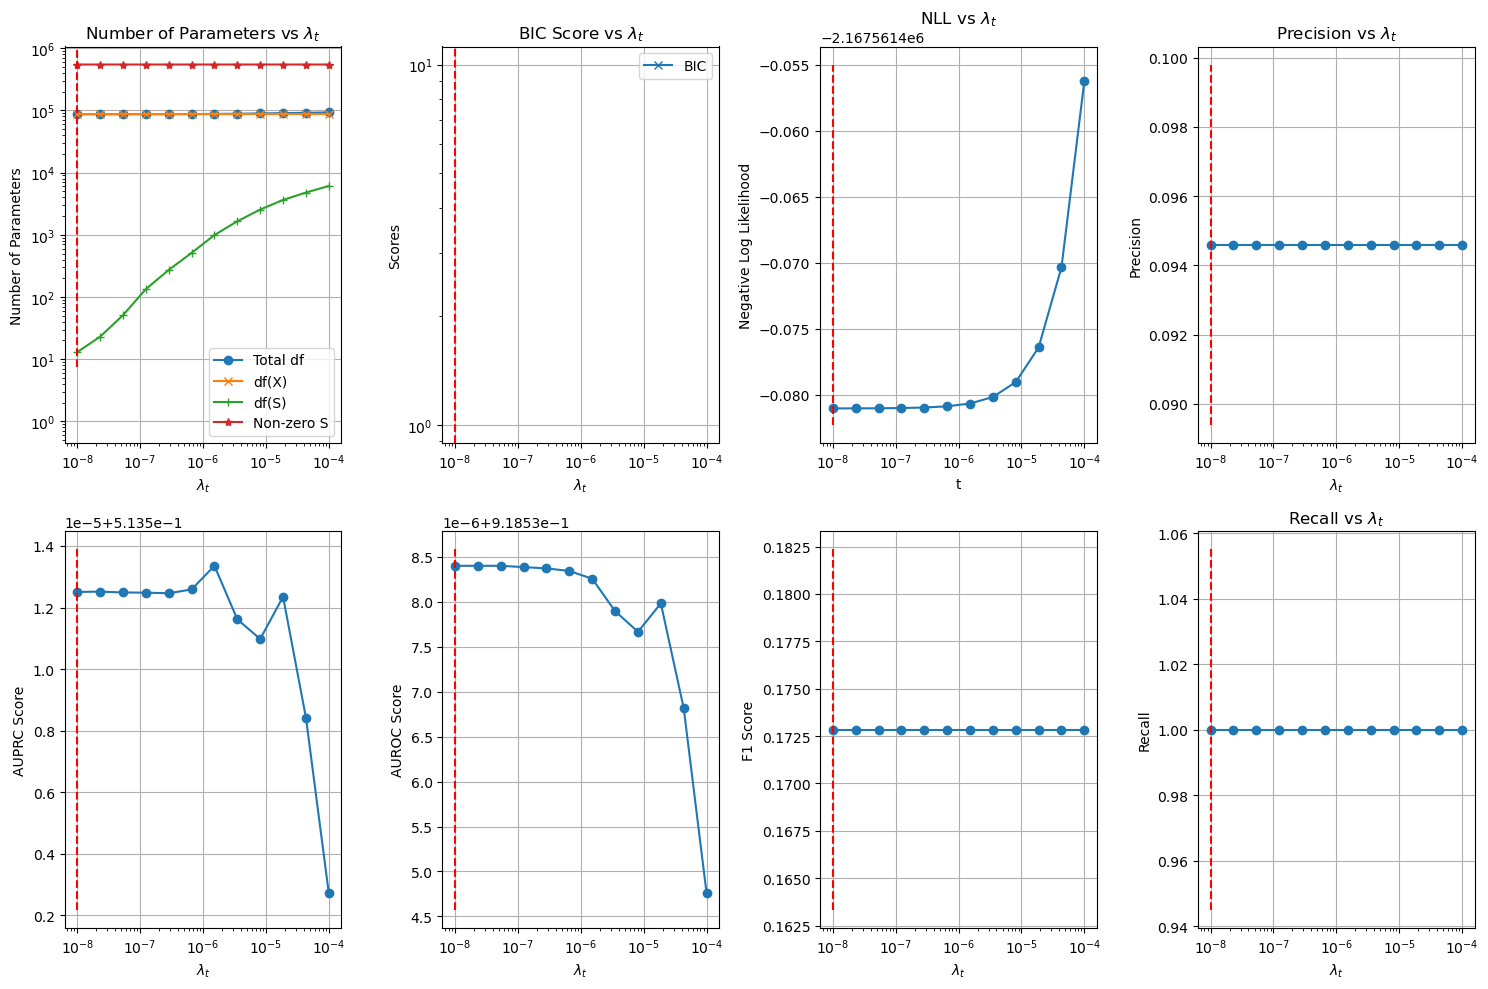

In [ ]:
t = lda_t_range[np.argmin(bic_score)]
print(r"Optimal $\lambda_t$:", t)

fig, axe = plt.subplots(2, 4, figsize=(15, 10))
axe[0, 0].loglog(lda_t_range, num_parameters, marker='o', label='Total df')
axe[0, 0].loglog(lda_t_range, num_param_Xs, marker='x', label='df(X)')
axe[0, 0].loglog(lda_t_range, num_param_Ss, marker='+', label='df(S)')
axe[0, 0].loglog(lda_t_range, non_zero_Ss, marker='*', label='Non-zero S')
axe[0, 0].set_xlabel(r'$\lambda_t$')
axe[0, 0].set_ylabel('Number of Parameters')
axe[0, 0].set_title(r'Number of Parameters vs $\lambda_t$')
axe[0, 0].legend()
# axe[0, 1].semilogy(t_range, aic_score, marker='o', label='AIC')
axe[0, 1].loglog(lda_t_range, bic_score, marker='x', label='BIC')
axe[0, 1].legend()
axe[0, 1].set_xlabel(r'$\lambda_t$')
axe[0, 1].set_ylabel('Scores')
axe[0, 1].set_title(r'BIC Score vs $\lambda_t$')
axe[0, 2].semilogx(lda_t_range, nlls, marker='o')
axe[0, 2].set_xlabel('t')
axe[0, 2].set_ylabel('Negative Log Likelihood')
axe[0, 2].set_title(r'NLL vs $\lambda_t$')
axe[0, 3].semilogx(lda_t_range, precision_scores, marker='o')
axe[0, 3].set_xlabel(r'$\lambda_t$')
axe[0, 3].set_ylabel('Precision')
axe[0, 3].set_title(r'Precision vs $\lambda_t$')
axe[1, 0].semilogx(lda_t_range, au_prc_scores, marker='o')
axe[1, 0].set_xlabel(r'$\lambda_t$')
axe[1, 0].set_ylabel('AUPRC Score')
axe[1, 1].semilogx(lda_t_range, au_roc_scores, marker='o')
axe[1, 1].set_xlabel(r'$\lambda_t$')
axe[1, 1].set_ylabel('AUROC Score')
axe[1, 2].semilogx(lda_t_range, f1_scores, marker='o')
axe[1, 2].set_xlabel(r'$\lambda_t$')
axe[1, 2].set_ylabel('F1 Score')
axe[1, 3].semilogx(lda_t_range, recall_scores, marker='o')
axe[1, 3].set_xlabel(r'$\lambda_t$')
axe[1, 3].set_ylabel('Recall')
axe[1, 3].set_title(r'Recall vs $\lambda_t$')

axes = axe.flatten()
for ax in axes:
    ax.grid(True)
    ax.vlines([t], *ax.get_ylim(), colors='r', linestyles='dashed', label=r'Optimal $\lambda_t$')
fig.tight_layout()

In [ ]:
lbls = labels[mchannel.og_mask.any(axis=0, keepdims=True)].ravel()
lbl_mask = mchannel.og_mask.any(axis=0, keepdims=True)

G = nx.Graph()
G.add_nodes_from(range(38))
Gt = nx.grid_graph(dim=(day_folding[1],))

lda_f= 330
var = 1/lda_f # 0.0003#9.0e-5#1/lda_f
psis = [8.11]*4 #[9.005, 0.000146, 0.12521,  0.0052]
lda = 0.129 # 0.05129 # 1.5710243733981055
gtvr_config = [ { 'graph': 'temporal',
                    'mode': [4],
                    'variation_type': 'GTV',
                    'p': 1,
                    'normalization': 'none'}]


lda_t_range = np.logspace(-7, -3, 5)
lda1_range = np.logspace(-3, 0, 10)
shp = (len(lda_t_range), len(lda1_range))
num_parameters = np.zeros(shp)
num_param_Xs = np.zeros(shp)
num_param_Ss = np.zeros(shp)
non_zero_Ss = np.zeros(shp)
nlls = np.zeros(shp)
bic_score = np.zeros(shp)
aic_score = np.zeros(shp)
f1_scores = np.zeros(shp)
precision_scores = np.zeros(shp)
recall_scores = np.zeros(shp)
au_roc_scores = np.zeros(shp)
au_prc_scores = np.zeros(shp)

for j, lda in tqdm(enumerate(lda1_range), total=len(lda1_range)):
    for i, lda_t in tqdm(enumerate(lda_t_range), total=len(lda_t_range)):
        lr_sts= SNN__LOGN_GTV(Y, G, lr_modes=[1,2,3,4], graph_modes=[1], gtvr_config=gtvr_config,
                      grouping='neighbor', r_hop=0,
                      soft_constrained=True, device='cuda:1', verbose=False)

        X, S = lr_sts(psis=psis, lda=lda, lda_gtvs=[lda_t], lda_f=lda_f, max_iter=1000,
                    rho_update='domain_parametrization', rho=rho,tol=1e-4)
        
        V_sum = lr_sts.V.sum(dim=0, keepdim=False).coalesce().to_dense()
        S_ = tensorize(V_sum, lr_sts.Y.shape, lr_sts.graph_modes)

        num_parameter = lr_sts.num_parameters()
        num_param_Xs[i,j] = num_parameter['X']
        non_zero_Ss[i,j] = num_parameter['S']
        num_param_Ss[i,j] = lr_sts_df(lr_sts, Gt)
        num_parameters[i,j] = num_param_Xs[i,j] + num_param_Ss[i,j]
        nlls[i,j] = (np.prod(Y.shape)*0.5*np.log(2*np.pi*var)) +(0.5/var)*torch.norm(torch.tensor(Y,device='cuda:1')-X-S, p='fro').cpu().item()**2
        bic_score[i,j] = 2*nlls[i,j] + num_parameters[i,j]*np.log(np.prod(Y.shape))
        aic_score[i,j] = 2*nlls[i,j] + 2*num_parameters[i,j]

        f1_scores[i,j] = f1_score(lbls, (S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
        precision_scores[i,j] = precision_score(lbls,(S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
        recall_scores[i,j] = recall_score(lbls, (S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
        au_roc_scores[i,j] = roc_auc_score(lbls, S.abs().sum(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
        p, r, th = precision_recall_curve(lbls, S.abs().sum(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
        au_prc_scores[i,j] = auc(r, p)

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [19:07<00:00, 114.77s/it]


Optimal t: 3


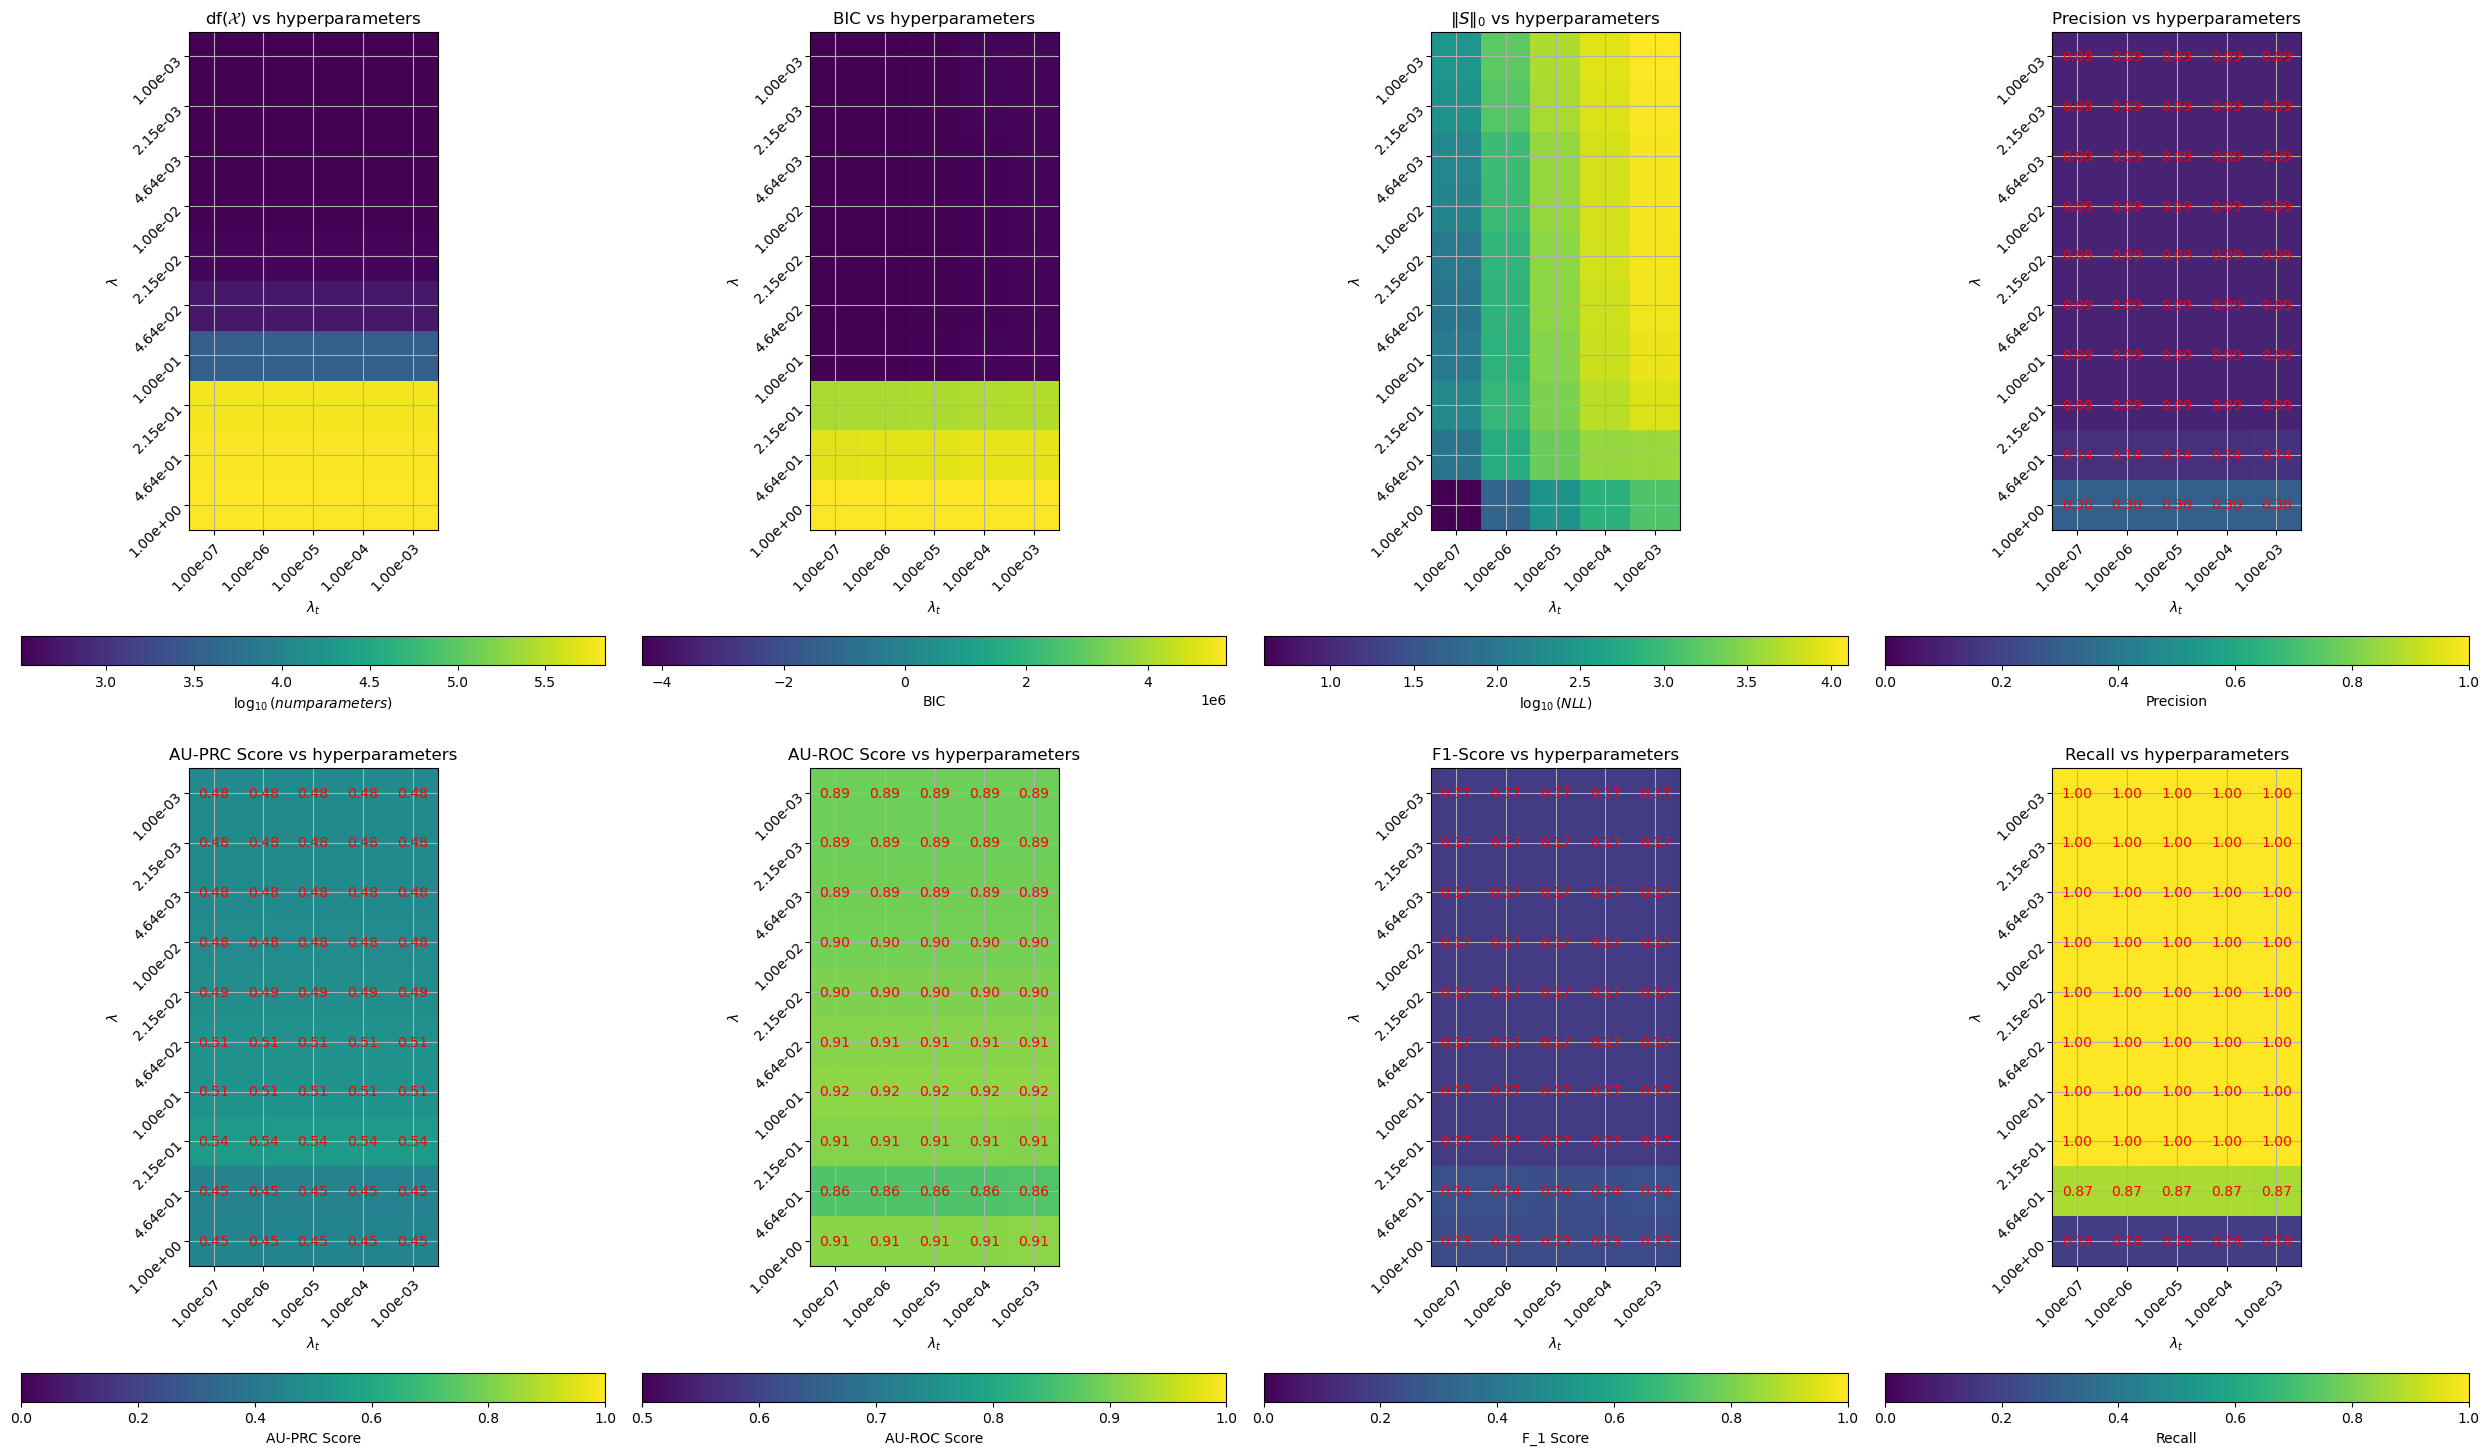

In [ ]:
t = np.argmin(bic_score)
print("Optimal t:", t)

PSI, LDA1 = np.meshgrid(np.log10(lda_t_range), np.log10(lda1_range))
fig, axe = plt.subplots(2, 4, figsize=(25, 15))
pos = axe[0, 0].imshow(np.log10(num_param_Xs.T+1))#, color='C0', label='BIC')
axe[0, 0].set_xlabel(r'$\lambda_t$')
axe[0, 0].set_ylabel(r'$\lambda$')
axe[0, 0].set_title(r'$\mathrm{df}(\mathcal{X})$ vs hyperparameters')
fig.colorbar(pos, ax=axe[0, 0], orientation='horizontal', label=r'$\log_{10}(num parameters)$')

pos = axe[0, 1].imshow(bic_score.T)#num_parameters.T)#
axe[0, 1].set_xlabel(r'$\lambda_t$')
axe[0, 1].set_ylabel(r'$\lambda$')
axe[0, 1].set_title('BIC vs hyperparameters')
fig.colorbar(pos, ax=axe[0, 1], orientation='horizontal', label='BIC')

pos = axe[0, 2].imshow(np.log10(num_param_Ss +1).T)#, color='C0', label='BIC')
axe[0, 2].set_xlabel(r'$\lambda_t$')
axe[0, 2].set_ylabel(r'$\lambda$')
axe[0, 2].set_title(r'$\|S\|_0$ vs hyperparameters')
fig.colorbar(pos, ax=axe[0, 2], orientation='horizontal', label=r'$\log_{10}(NLL)$')

pos = axe[0, 3].imshow(precision_scores.T, vmin=0, vmax=1)
axe[0, 3].set_xlabel(r'$\lambda_t$')
axe[0, 3].set_ylabel(r'$\lambda$')
axe[0, 3].set_title('Precision vs hyperparameters')
fig.colorbar(pos, ax=axe[0, 3], orientation='horizontal', label=r'Precision')
for i in range(len(lda_t_range)):
    for j in range(len(lda1_range)):
        text = axe[0, 3].text(i, j, f'{precision_scores[i, j]:.2f}',
                       ha="center", va="center", color="r")

pos = axe[1, 0].imshow(au_prc_scores.T, vmin=0, vmax=1)
axe[1, 0].set_xlabel(r'$\lambda_t$')
axe[1, 0].set_ylabel(r'$\lambda$')
axe[1, 0].set_title('AU-PRC Score vs hyperparameters')
fig.colorbar(pos, ax=axe[1, 0], orientation='horizontal', label=r'AU-PRC Score')
for i in range(len(lda_t_range)):
    for j in range(len(lda1_range)):
        text = axe[1, 0].text(i, j, f'{au_prc_scores[i, j]:.2f}',
                       ha="center", va="center", color="r")

pos = axe[1, 1].imshow(au_roc_scores.T, vmin=0.5, vmax=1)
axe[1, 1].set_xlabel(r'$\lambda_t$')
axe[1, 1].set_ylabel(r'$\lambda$')
axe[1, 1].set_title('AU-ROC Score vs hyperparameters')
fig.colorbar(pos, ax=axe[1, 1], orientation='horizontal', label=r'AU-ROC Score')
for i in range(len(lda_t_range)):
    for j in range(len(lda1_range)):
        text = axe[1, 1].text(i, j, f'{au_roc_scores[i, j]:.2f}',
                       ha="center", va="center", color="r")

pos = axe[1, 2].imshow(f1_scores.T, vmin=0, vmax=1)
axe[1, 2].set_xlabel(r'$\lambda_t$')
axe[1, 2].set_ylabel(r'$\lambda$')
axe[1, 2].set_title('F1-Score vs hyperparameters')
fig.colorbar(pos, ax=axe[1, 2], orientation='horizontal', label=r'F_1 Score')
for i in range(len(lda_t_range)):
    for j in range(len(lda1_range)):
        text = axe[1, 2].text(i, j, f'{f1_scores[i, j]:.2f}',
                       ha="center", va="center", color="r")

pos = axe[1, 3].imshow(recall_scores.T, vmin=0, vmax=1)
axe[1, 3].set_xlabel(r'$\lambda_t$')
axe[1, 3].set_ylabel(r'$\lambda$')
axe[1, 3].set_title('Recall vs hyperparameters')
fig.colorbar(pos, ax=axe[1, 3], orientation='horizontal', label=r'Recall')
for i in range(len(lda_t_range)):
    for j in range(len(lda1_range)):
        text = axe[1, 3].text(i, j, f'{recall_scores[i, j]:.2f}',
                       ha="center", va="center", color="r")

axes = axe.flatten()
for ax in axes:
    ax.grid(True)
    ax.set_xticks(range(len(lda_t_range)), labels=[f'{lda:.2e}' for lda in lda_t_range],
              rotation=45, ha="right", rotation_mode="anchor")
    ax.set_yticks(range(len(lda1_range)), labels=[f'{lda:.2e}' for lda in lda1_range],
              rotation=45, ha="right", rotation_mode="anchor")
    # ax.vlines([t], *ax.get_ylim(), colors='r', linestyles='dashed', label='Optimal t')
fig.tight_layout()


In [ ]:
G = mchannel.G
Gt = nx.grid_graph(dim=(day_folding[1],))
lbls = labels[mchannel.og_mask.any(axis=0, keepdims=True)].ravel()
lbl_mask = mchannel.og_mask.any(axis=0, keepdims=True)

lda_f= 330
var = 1/lda_f # 0.0003#9.0e-5#1/lda_f
psis = [8.11]*4 #[9.005, 0.000146, 0.12521,  0.0052]
lda = 0.129 # 0.05129 # 1.5710243733981055
gtvr_config = [ { 'graph': 'spatial',
                    'mode': [1],
                    'variation_type': 'GTMV',
                    'p': 1,
                    'normalization': 'none'
                    }]
device= 'cuda:2'

lda_t_range = np.logspace(-8, 1, 9)
lda1_range = np.logspace(-5, 1, 8)
shp = (len(lda_t_range), len(lda1_range))
num_parameters = np.zeros(shp)
num_param_Xs = np.zeros(shp)
num_param_Ss = np.zeros(shp)
non_zero_Ss = np.zeros(shp)
nlls = np.zeros(shp)
bic_score = np.zeros(shp)
aic_score = np.zeros(shp)
f1_scores = np.zeros(shp)
precision_scores = np.zeros(shp)
recall_scores = np.zeros(shp)
au_roc_scores = np.zeros(shp)
au_prc_scores = np.zeros(shp)

for j, lda in tqdm(enumerate(lda1_range), total=len(lda1_range)):
    for i, lda_t in tqdm(enumerate(lda_t_range), total=len(lda_t_range)):
        lr_sss= SNN__LOGN_GTV(Y, G, lr_modes=[1,2,3,4], graph_modes=[1], gtvr_config=gtvr_config,
                      grouping='neighbor', r_hop=0,
                      soft_constrained=True, device=device, verbose=False)

        X, S = lr_sss(psis=psis, lda=lda, lda_gtvs=[lda_t], lda_f=lda_f, max_iter=500,
                  rho_update='domain_parametrization', rho=0.1, tol=1e-4)
    
        V_sum = lr_sss.V.sum(dim=0, keepdim=False).coalesce().to_dense()
        S_ = tensorize(V_sum, lr_sss.Y.shape, lr_sss.graph_modes)

        num_parameter = lr_sss.num_parameters()
        num_param_Xs[i,j] = num_parameter['X']
        non_zero_Ss[i,j] = num_parameter['S']
        num_param_Ss[i,j] = lr_sss_df(lr_sss, G)
        num_parameters[i,j] = num_param_Xs[i,j] + num_param_Ss[i,j]
        nlls[i,j] = (np.prod(Y.shape)*0.5*np.log(2*np.pi*var)) +(0.5/var)*torch.norm(torch.tensor(Y,device=device)-X-S, p='fro').cpu().item()**2
        bic_score[i,j] = 2*nlls[i,j] + num_parameters[i,j]*np.log(np.prod(Y.shape))
        aic_score[i,j] = 2*nlls[i,j] + 2*num_parameters[i,j]

        f1_scores[i,j] = f1_score(lbls, (S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
        precision_scores[i,j] = precision_score(lbls,(S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
        recall_scores[i,j] = recall_score(lbls, (S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
        au_roc_scores[i,j] = roc_auc_score(lbls, S.abs().sum(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
        p, r, th = precision_recall_curve(lbls, S.abs().sum(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel())
        au_prc_scores[i,j] = auc(r, p)


  0%|          | 0/8 [00:00<?, ?it/s]/mnt/ffs24/home/indibimu/repos/ML_GSP/src/proximal_ops/prox_overlapping_grouped_l21.py:405: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647378361/work/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  G_ind = torch.sparse_csr_tensor(A_r.indptr, A_r.indices, A_r.data, device=device, dtype=dtype)
 75%|███████▌  | 6/8 [15:40<05:38, 169.41s/it]/tmp/ipykernel_824525/1499395782.py:62: UserWarning: torch.linalg.svd: During SVD computation with the selected cusolver driver, batches 0 failed to converge. A more accurate method will be used to compute the SVD as a fallback. Check doc at https://pytorch.org/docs/stable/generated/torch.linalg.svd.html (Triggered internally at /opt/conda/conda-bld/pytorch_1729647378361/work/aten/src/ATen/native/cuda/linalg/BatchLi

Optimal t: 0


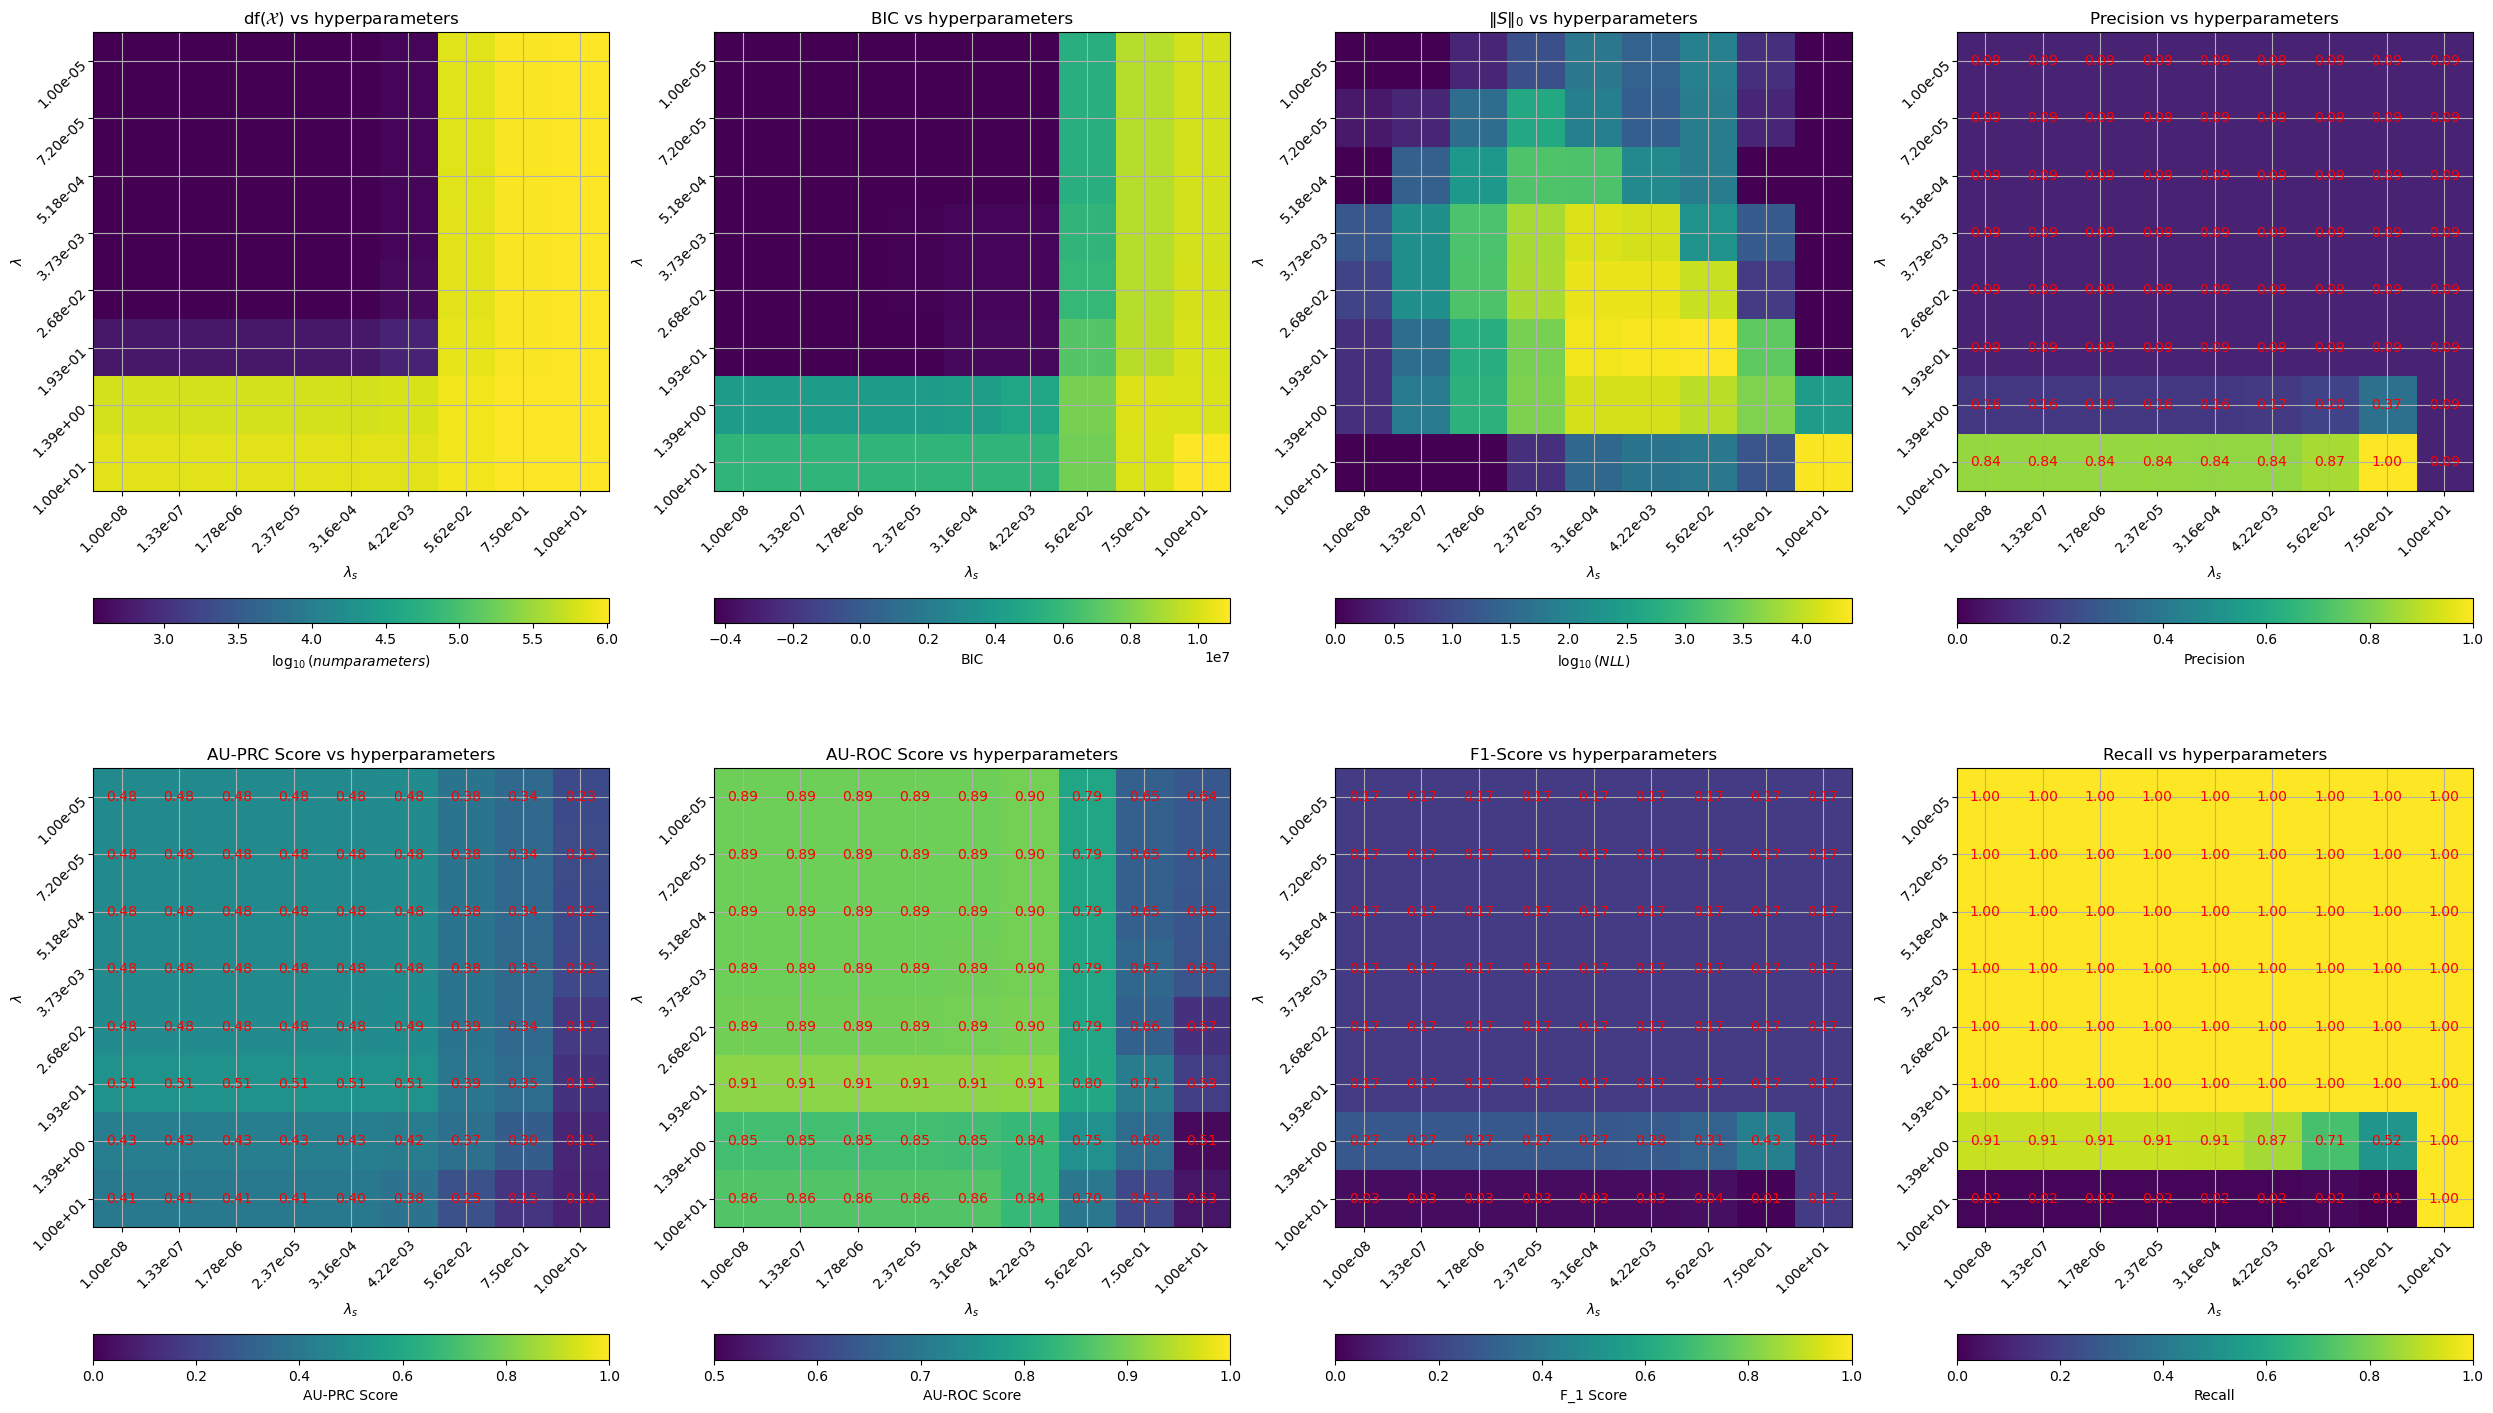

In [ ]:
t = np.argmin(bic_score)
print("Optimal t:", t)

PSI, LDA1 = np.meshgrid(np.log10(lda_t_range), np.log10(lda1_range))
fig, axe = plt.subplots(2, 4, figsize=(25, 15))
pos = axe[0, 0].imshow(np.log10(num_param_Xs.T+1))#, color='C0', label='BIC')
axe[0, 0].set_xlabel(r'$\lambda_s$')
axe[0, 0].set_ylabel(r'$\lambda$')
axe[0, 0].set_title(r'$\mathrm{df}(\mathcal{X})$ vs hyperparameters')
fig.colorbar(pos, ax=axe[0, 0], orientation='horizontal', label=r'$\log_{10}(num parameters)$')

pos = axe[0, 1].imshow(bic_score.T)#num_parameters.T)#
axe[0, 1].set_xlabel(r'$\lambda_s$')
axe[0, 1].set_ylabel(r'$\lambda$')
axe[0, 1].set_title('BIC vs hyperparameters')
fig.colorbar(pos, ax=axe[0, 1], orientation='horizontal', label='BIC')

pos = axe[0, 2].imshow(np.log10(num_param_Ss +1).T)#, color='C0', label='BIC')
axe[0, 2].set_xlabel(r'$\lambda_s$')
axe[0, 2].set_ylabel(r'$\lambda$')
axe[0, 2].set_title(r'$\|S\|_0$ vs hyperparameters')
fig.colorbar(pos, ax=axe[0, 2], orientation='horizontal', label=r'$\log_{10}(NLL)$')

pos = axe[0, 3].imshow(precision_scores.T, vmin=0, vmax=1)
axe[0, 3].set_xlabel(r'$\lambda_s$')
axe[0, 3].set_ylabel(r'$\lambda$')
axe[0, 3].set_title('Precision vs hyperparameters')
fig.colorbar(pos, ax=axe[0, 3], orientation='horizontal', label=r'Precision')
for i in range(len(lda_t_range)):
    for j in range(len(lda1_range)):
        text = axe[0, 3].text(i, j, f'{precision_scores[i, j]:.2f}',
                       ha="center", va="center", color="r")

pos = axe[1, 0].imshow(au_prc_scores.T, vmin=0, vmax=1)
axe[1, 0].set_xlabel(r'$\lambda_s$')
axe[1, 0].set_ylabel(r'$\lambda$')
axe[1, 0].set_title('AU-PRC Score vs hyperparameters')
fig.colorbar(pos, ax=axe[1, 0], orientation='horizontal', label=r'AU-PRC Score')
for i in range(len(lda_t_range)):
    for j in range(len(lda1_range)):
        text = axe[1, 0].text(i, j, f'{au_prc_scores[i, j]:.2f}',
                       ha="center", va="center", color="r")

pos = axe[1, 1].imshow(au_roc_scores.T, vmin=0.5, vmax=1)
axe[1, 1].set_xlabel(r'$\lambda_s$')
axe[1, 1].set_ylabel(r'$\lambda$')
axe[1, 1].set_title('AU-ROC Score vs hyperparameters')
fig.colorbar(pos, ax=axe[1, 1], orientation='horizontal', label=r'AU-ROC Score')
for i in range(len(lda_t_range)):
    for j in range(len(lda1_range)):
        text = axe[1, 1].text(i, j, f'{au_roc_scores[i, j]:.2f}',
                       ha="center", va="center", color="r")

pos = axe[1, 2].imshow(f1_scores.T, vmin=0, vmax=1)
axe[1, 2].set_xlabel(r'$\lambda_s$')
axe[1, 2].set_ylabel(r'$\lambda$')
axe[1, 2].set_title('F1-Score vs hyperparameters')
fig.colorbar(pos, ax=axe[1, 2], orientation='horizontal', label=r'F_1 Score')
for i in range(len(lda_t_range)):
    for j in range(len(lda1_range)):
        text = axe[1, 2].text(i, j, f'{f1_scores[i, j]:.2f}',
                       ha="center", va="center", color="r")

pos = axe[1, 3].imshow(recall_scores.T, vmin=0, vmax=1)
axe[1, 3].set_xlabel(r'$\lambda_s$')
axe[1, 3].set_ylabel(r'$\lambda$')
axe[1, 3].set_title('Recall vs hyperparameters')
fig.colorbar(pos, ax=axe[1, 3], orientation='horizontal', label=r'Recall')
for i in range(len(lda_t_range)):
    for j in range(len(lda1_range)):
        text = axe[1, 3].text(i, j, f'{recall_scores[i, j]:.2f}',
                       ha="center", va="center", color="r")

axes = axe.flatten()
for ax in axes:
    ax.grid(True)
    ax.set_xticks(range(len(lda_t_range)), labels=[f'{lda:.2e}' for lda in lda_t_range],
              rotation=45, ha="right", rotation_mode="anchor")
    ax.set_yticks(range(len(lda1_range)), labels=[f'{lda:.2e}' for lda in lda1_range],
              rotation=45, ha="right", rotation_mode="anchor")
    # ax.vlines([t], *ax.get_ylim(), colors='r', linestyles='dashed', label='Optimal t')
fig.tight_layout()


In [ ]:
G = mchannel.G
Gt = nx.grid_graph(dim=(day_folding[1],))

lda_f= 330
var = 1/lda_f # 0.0003#9.0e-5#1/lda_f
psis = [8.11]*4 #[9.005, 0.000146, 0.12521,  0.0052]
lda = 1.0 # 0.05129 # 1.5710243733981055
lda_s = 0.00001
lda_t = 0.0001
gtvr_config = [ { 'graph': 'spatial',
                    'mode': [1],
                    'variation_type': 'GTMV',
                    'p': 1,
                    'normalization': 'none'
                    },
                { 'graph': 'temporal',
                    'mode': [4],
                    'variation_type': 'GTV',
                    'p': 1,
                    'normalization': 'none'
                    }
                ]
device= 'cuda:2'

lr_stss= SNN__LOGN_GTV(Y, G, lr_modes=[1,2,3,4], graph_modes=[1], gtvr_config=gtvr_config,
                      grouping='neighbor', r_hop=0,
                      soft_constrained=True, device=device, verbose=True)

X, S = lr_stss(psis=psis, lda=lda, lda_gtvs=[lda_s, lda_t], lda_f=lda_f, max_iter=5000,
              rho_update='domain_parametrization', rho=0.1, tol=1e-4)

V_sum = lr_stss.V.sum(dim=0, keepdim=False).coalesce().to_dense()
S_ = tensorize(V_sum, lr_stss.Y.shape, lr_stss.graph_modes)


It-0 	# |r| = 2.0510e+02 	|s| = 3.0381e+01 	 obj = 4.9260e+03 	 0.054 sec.
It-1 	# |r| = 1.1884e+02 	|s| = 1.3844e+01 	 obj = 7.6996e+03 	 0.016 sec.
It-2 	# |r| = 8.7402e+01 	|s| = 5.7470e+00 	 obj = 8.8558e+03 	 0.016 sec.
It-3 	# |r| = 7.0709e+01 	|s| = 3.6653e+00 	 obj = 9.6561e+03 	 0.016 sec.
It-4 	# |r| = 5.5048e+01 	|s| = 6.1331e+00 	 obj = 1.0401e+04 	 0.016 sec.
It-5 	# |r| = 4.6679e+01 	|s| = 4.0471e+00 	 obj = 1.0850e+04 	 0.016 sec.
It-6 	# |r| = 4.0644e+01 	|s| = 2.8438e+00 	 obj = 1.1165e+04 	 0.016 sec.
It-7 	# |r| = 3.6558e+01 	|s| = 2.3163e+00 	 obj = 1.1392e+04 	 0.016 sec.
It-8 	# |r| = 3.1204e+01 	|s| = 3.4994e+00 	 obj = 1.1772e+04 	 0.016 sec.
It-9 	# |r| = 2.6902e+01 	|s| = 2.5239e+00 	 obj = 1.2031e+04 	 0.016 sec.
It-10 	# |r| = 2.2256e+01 	|s| = 3.4054e+00 	 obj = 1.2354e+04 	 0.016 sec.
It-11 	# |r| = 1.8579e+01 	|s| = 2.6221e+00 	 obj = 1.2574e+04 	 0.016 sec.
It-12 	# |r| = 1.6185e+01 	|s| = 2.2494e+00 	 obj = 1.2729e+04 	 0.016 sec.
It-13 	# |r| = 1.4218e

In [ ]:
# likelihood = rachitas_thresholder(lr_stss, G)
scoring_scores = mchannel.anomaly_scoring_score(lr_stss.S.abs())

V_sum = lr_stss.V.sum(dim=0, keepdim=False).coalesce().to_dense()
labels = tensorize(V_sum, lr_stss.Y.shape, lr_stss.graph_modes)!=0

detection_scores = mchannel.anomaly_detection_score(labels)

q = np.quantile(likelihood, 0.999)
det = np.zeros(likelihood.shape)
det[likelihood > q] = 1

scoring_scores = mchannel.anomaly_scoring_score(S.abs())
detection_scores = mchannel.anomaly_detection_score(S_!=0)

rachitas_scores = mchannel.anomaly_scoring_score(likelihood)
rachitas_detection = mchannel.anomaly_detection_score(det)

print("Raw Anomaly Scoring Performance:\n", '='*20)
print(' -> AU-PRC:', scoring_scores['au_prc'])
print(' -> AU-ROC:', scoring_scores['au_roc'])
print(' -> Precision: ', detection_scores['precision'], '\t| P.A Precision: ', detection_scores['PA_precision'])
print(' -> Recall: ', detection_scores['recall'], '\t\t\t| P.A Recall: ', detection_scores['PA_recall'])
print(' -> F1-Score: ', detection_scores['f1'], '\t| P.A F1-Score: ', detection_scores['PA_F1'])
print(' -> Group-wise Accuracy: ', detection_scores['group_accuracy'])
print(' -> Group-support Ratio: ', detection_scores['group_support_ratio'])
print(' '*20)
print("Rachitas Likelihood Conversion Scores:\n", '='*20)
print(' -> AU-PRC:', rachitas_scores['au_prc'])
print(' -> AU-ROC:', rachitas_scores['au_roc'])
print(' -> Precision: ', rachitas_detection['precision'], '\t| P.A Precision: ', rachitas_detection['PA_precision'])
print(' -> Recall: ', rachitas_detection['recall'], '\t| P.A Recall: ', rachitas_detection['PA_recall'])
print(' -> F1-Score: ', rachitas_detection['f1'], '\t| P.A F1-Score: ', rachitas_detection['PA_F1'])
print(' -> Group-wise Accuracy: ', rachitas_detection['group_accuracy'])
print(' -> Group-support Ratio: ', rachitas_detection['group_support_ratio'])

Raw Anomaly Scoring Performance:
 -> AU-PRC: 0.5390552272637645
 -> AU-ROC: 0.9289010015001845
 -> Precision:  0.09478572936457674 	| P.A Precision:  0.09478572936457674
 -> Recall:  1.0 			| P.A Recall:  1.0
 -> F1-Score:  0.17315850366371 	| P.A F1-Score:  0.17315850366371
 -> Group-wise Accuracy:  1.0
 -> Group-support Ratio:  0.738998077333903
                    
Rachitas Likelihood Conversion Scores:
 -> AU-PRC: 0.5596211480710798
 -> AU-ROC: 0.9046020868989887
 -> Precision:  0.8133333333333334 	| P.A Precision:  0.9794344473007712
 -> Recall:  0.09057164068299926 	| P.A Recall:  0.9899777282850779
 -> F1-Score:  0.1629926519706079 	| P.A F1-Score:  0.9846778659774783
 -> Group-wise Accuracy:  1.0
 -> Group-support Ratio:  0.026703695791497544


100%|██████████| 20/20 [00:01<00:00, 19.81it/s]


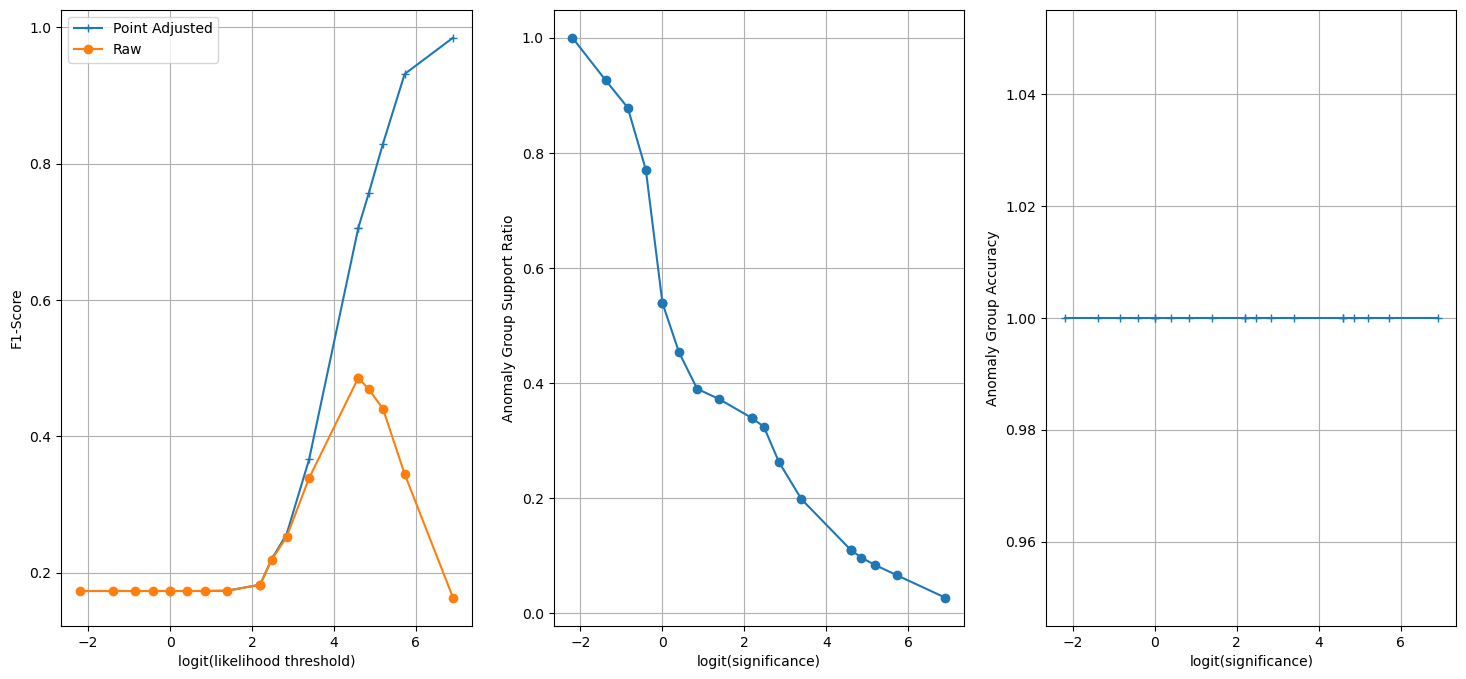

In [ ]:
sigs = list(np.linspace(0.1, 0.5, 5)) + list(np.linspace(0.5, 0.9, 5)) + list(np.linspace(0.9, 0.99, 5))+list(np.linspace(0.99, 0.999, 5))

F1_scores = []
F1_scores_PA = []
Group_accuracy = []
Group_support_ratios = []

for i, sig in tqdm(enumerate(sigs), total=len(sigs)):
    # rachitas_scores, rachitas_detection = rachitas_thresholder(lr_sts, G, sig=sig)
    q = np.quantile(likelihood, sig)
    det = np.zeros(likelihood.shape)
    det[likelihood > q] = 1
    rachitas_detection = mchannel.anomaly_detection_score(det)
    F1_scores.append(rachitas_detection['f1'])
    F1_scores_PA.append(rachitas_detection['PA_F1'])
    Group_accuracy.append(rachitas_detection['group_accuracy'])
    Group_support_ratios.append(rachitas_detection['group_support_ratio'])

logit_sig = np.log((np.array(sigs)/(1-np.array(sigs))))
fig, axes = plt.subplots(1,3, figsize=(18, 8))
axes[0].plot(logit_sig, F1_scores_PA, marker='+', label='Point Adjusted')
axes[0].plot(logit_sig, F1_scores, marker='o', label='Raw')
axes[0].set_ylabel('F1-Score')
axes[0].set_xlabel('logit(likelihood threshold)');
axes[0].legend()

axes[2].plot(logit_sig, Group_accuracy, marker='+')
axes[2].set_ylabel('Anomaly Group Accuracy')
axes[2].set_xlabel('logit(significance)');

axes[1].plot(logit_sig, Group_support_ratios, marker='o')
axes[1].set_ylabel('Anomaly Group Support Ratio')
axes[1].set_xlabel('logit(significance)');
[axe.grid() for axe in axes];

In [ ]:

scoring_scores = mchannel.anomaly_scoring_score(lr_stss.S.abs())

V_sum = lr_stss.V.sum(dim=0, keepdim=False).coalesce().to_dense()
labels = tensorize(V_sum, lr_stss.Y.shape, lr_stss.graph_modes)!=0

detection_scores = mchannel.anomaly_detection_score(labels)

print("Anomaly Scoring Scores:")
print('AU-PRC:', scoring_scores['au_prc'])
print('AU-ROC:', scoring_scores['au_roc'])
print("Anomaly Detection Scores:")
pprint(detection_scores)

Anomaly Scoring Scores:
AU-PRC: 0.5390552272637645
AU-ROC: 0.9289010015001845
Anomaly Detection Scores:
{'f1': 0.17315850366371,
 'group_accuracy': 1.0,
 'group_support_ratio': 0.738998077333903,
 'precision': 0.09478572936457674,
 'raw_F1': 0.17315850366371,
 'raw_precision': 0.09478572936457674,
 'raw_recall': 1.0,
 'recall': 1.0}


In [ ]:
from scipy.stats import norm
S_loc = matricize(lr_stss.Y - lr_stss.X, [1]).cpu().numpy() #matricize(lr_stss.S, [1]).cpu().numpy()
radius = 2
r_A = np.eye(S_loc.shape[0])+np.linalg.matrix_power(nx.adjacency_matrix(G).toarray(),radius)
likelihood = np.zeros(S_loc.shape)
for s in range(S_loc.shape[0]):
        mask = r_A[np.where(r_A[s,]!=0),:].astype(bool)
        nbd = S_loc[mask[:,0,:].ravel(),:]
        # Append neighbors from additional columns in mask
        for m in range(1, mask.shape[1]):
            nbd = np.vstack((nbd,S_loc[mask[:,m,:].ravel(),:] ))
                
        W = np.zeros(nbd.shape)
        # Iterate through the columns in steps of block_size
        for i1 in range(0, 24480, 1440):
            # Slice the matrix to get the block (columns from i to i + block_size)
            if i1==0:
                block = nbd[:, i1:i1 + 1440]
                for loc in range(nbd.shape[0]):
                    W[loc, i1:i1+1440] = norm.pdf(np.linalg.norm(block[loc,:] - S_loc[s,i1:i1+1440]),0,30)
            elif i1==23040:
                block = nbd[:, i1-1440:i1 + 1440]
                for loc in range(nbd.shape[0]):
                    W[loc, i1:i1+1440] = norm.pdf(np.linalg.norm(block[loc,:] - S_loc[s,i1-1440:i1+1440]),0,30)
            else:
                block = nbd[:, i1-1440:i1 + 2880]
                for loc in range(nbd.shape[0]):
                    W[loc, i1:i1+1440] = norm.pdf(np.linalg.norm(block[loc,:] - S_loc[s,i1-1440:i1+2880]),0,30)
                        
        mean = np.sum(W * nbd) / np.sum(W)
        sd = np.sqrt(np.sum(W * (nbd - mean)**2) / np.sum(W))
        if sd == 0:
            sd = sd+(10e-20)
        likelihood[s,] = np.log(sd) + (0.5*np.power(((S_loc[s,] - mean)/sd),2))

sig = 0.999
det = np.zeros(S_loc.shape)
q = np.quantile(likelihood,sig)
det[likelihood > q] = 1

scoring_scores = mchannel.anomaly_scoring_score(tensorize(likelihood, lr_stss.Y.shape, [1]))
detection_scores = mchannel.anomaly_detection_score(tensorize(det, lr_stss.Y.shape, [1]))

print("Anomaly Scoring Scores:")
print('AU-PRC:', scoring_scores['au_prc'])
print('AU-ROC:', scoring_scores['au_roc'])
print("Anomaly Detection Scores:")
pprint(detection_scores)

In [ ]:
sig = 0.999
det = np.zeros(S_loc.shape)
q = np.quantile(likelihood,sig)
det[likelihood > q] = 1

scoring_scores = mchannel.anomaly_scoring_score(tensorize(likelihood, lr_stss.Y.shape, [1]))
detection_scores = mchannel.anomaly_detection_score(tensorize(det, lr_stss.Y.shape, [1]))

print("Anomaly Scoring Scores:")
print('AU-PRC:', scoring_scores['au_prc'])
print('AU-ROC:', scoring_scores['au_roc'])
print("Anomaly Detection Scores:")
pprint(detection_scores)

Anomaly Scoring Scores:
AU-PRC: 0.5587802228055403
AU-ROC: 0.9014915470125224
Anomaly Detection Scores:
{'f1': 0.9835884196938963,
 'group_accuracy': 1.0,
 'group_support_ratio': 0.02643665883358257,
 'precision': 0.9772810553316233,
 'raw_F1': 0.16511318242343542,
 'raw_precision': 0.8,
 'raw_recall': 0.09205642167780252,
 'recall': 0.9899777282850779}


In [ ]:
sig = 0.997
det = np.zeros(S_loc.shape)
q = np.quantile(likelihood,sig)
det[likelihood > q] = 1

scoring_scores = mchannel.anomaly_scoring_score(tensorize(likelihood, lr_stss.Y.shape, [1]))
detection_scores = mchannel.anomaly_detection_score(tensorize(det, lr_stss.Y.shape, [1]))

print("Anomaly Scoring Scores:")
print('AU-PRC:', scoring_scores['au_prc'])
print('AU-ROC:', scoring_scores['au_roc'])
print("Anomaly Detection Scores:")
pprint(detection_scores)

Anomaly Scoring Scores:
AU-PRC: 0.5576702779805537
AU-ROC: 0.9012724000173324
Anomaly Detection Scores:
{'f1': 0.9381370826010544,
 'group_accuracy': 1.0,
 'group_support_ratio': 0.06294061098055971,
 'precision': 0.8908544726301736,
 'raw_F1': 0.33278145695364236,
 'raw_precision': 0.6483870967741936,
 'raw_recall': 0.22383073496659242,
 'recall': 0.9907201187824796}


In [ ]:
edge_connected_to_nonzero_node = (BT.unsqueeze(0).abs()@ nonzero_node.unsqueeze(-1).to(torch.float64)) != 0
print(f"edge_connected_to_nonzero_node shape: {edge_connected_to_nonzero_node.shape}")
nonzero_edge_connected_to_nonzero_nodes = edge_connected_to_nonzero_node & nonzero_edge.unsqueeze(-1)
print(f"edge_connected_to_nonzero_node shape: {edge_connected_to_nonzero_node.shape}")
zero_edge_connected_to_nonzero_nodes = edge_connected_to_nonzero_node & (nonzero_edge.unsqueeze(-1)==0)
print(f"nonzero_edge_connected_to_nonzero_nodes shape: {nonzero_edge_connected_to_nonzero_nodes.shape}")


edge_connected_to_nonzero_node shape: torch.Size([18240, 118, 1])
edge_connected_to_nonzero_node shape: torch.Size([18240, 118, 1])
nonzero_edge_connected_to_nonzero_nodes shape: torch.Size([18240, 118, 1])


In [ ]:
print(nonzero_node.sum())
print(zero_edge_connected_to_nonzero_nodes.sum()//2)
print(nonzero_node.sum()- zero_edge_connected_to_nonzero_nodes.sum()//2)

tensor(88, device='cuda:1')
tensor(0, device='cuda:1')
tensor(88, device='cuda:1')


In [ ]:
calculate_df_naive(Bindices, D)

tensor(41, device='cuda:1')

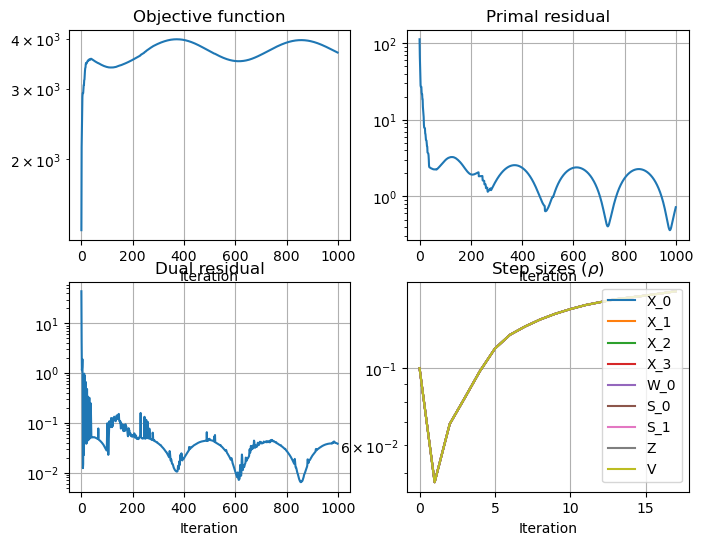

In [ ]:
lr_sts.plot_alg_run(figsize=(8,6));

In [ ]:
V_sum = horpca.V.sum(dim=0, keepdim=False).coalesce().to_dense()
S_ = tensorize(V_sum, horpca.Y.shape, horpca.graph_modes)

lbls = labels[mchannel.og_mask.any(axis=0, keepdims=True)].ravel()
lbl_mask = mchannel.og_mask.any(axis=0, keepdims=True)

print("F1 Score: \t",f1_score(lbls,
                (S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel()))
print("Precision: \t", precision_score(lbls,
            (S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel()))
print("Recall: \t", recall_score(lbls,
            (S_!=0).any(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel()))
print("AU-ROC Score: \t",roc_auc_score(lbls,
                    horpca.S.abs().sum(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel()))
p, r, th = precision_recall_curve(lbls,
                    horpca.S.abs().sum(axis=0, keepdims=True)[lbl_mask].cpu().numpy().ravel()
                    )

print("AU-PRC Score: \t", auc(r, p))

F1 Score: 	 0.21806656101426308
Precision: 	 0.1316494450822809
Recall: 	 0.6346863468634686
AU-ROC Score: 	 0.9098926204362252
AU-PRC Score: 	 0.2634929089613272


In [ ]:

print("F1 Score: \t",f1_score(labels.ravel(),
               (S!=0).any(axis=0).cpu().numpy().ravel()))
print("Precision: \t", precision_score(labels.ravel(),
                      (S!=0).any(axis=0).cpu().numpy().ravel()))
print("Recall: \t", recall_score(labels.ravel(),
                   (S!=0).any(axis=0).cpu().numpy().ravel()))
print("AU-ROC Score: \t",roc_auc_score(labels.ravel(),
                    S.abs().sum(axis=0).cpu().numpy().ravel()))

p, r, th = precision_recall_curve(labels.ravel(),
                                  S.abs().sum(axis=0).cpu().numpy().ravel())

print("AU-PRC Score: \t", auc(r, p))

F1 Score: 	 0.17108020575347685
Precision: 	 0.09354166666666666
Recall: 	 1.0
AU-ROC Score: 	 0.8783487552972745
AU-PRC Score: 	 0.42385052302910436


# MSL/SMAP Datasets

In [ ]:
labels = pd.read_csv(MSL_SMAP_LABELS_PATH)
labels[labels['spacecraft']=='MSL']

,chan_id,spacecraft,anomaly_sequences,class,num_values
55,M-6,MSL,"[[1850, 2030]]",[point],2049
56,M-1,MSL,"[[1110, 2250]]",[contextual],2277
57,M-2,MSL,"[[1110, 2250]]",[contextual],2277
58,S-2,MSL,"[[900, 910]]",[point],1827
59,P-10,MSL,"[[4590, 4720]]",[point],6100
60,T-4,MSL,"[[1172, 1240]]",[point],2217
61,T-5,MSL,"[[1200, 1225]]",[point],2218
62,F-7,MSL,"[[1250, 1450], [2670, 2790], [3325, 3425]]","[contextual, contextual, contextual]",5054
63,M-3,MSL,"[[1250, 1500]]",[contextual],2127
64,M-4,MSL,"[[1250, 1500]]",[contextual],2038


In [ ]:
train_channel = np.load(MSL_SMAP_TRAIN_DIR / 'M-5.npy')
print(train_channel.shape)
test_channel = np.load(MSL_SMAP_TEST_DIR / 'M-5.npy')
print(test_channel.shape)

(2032, 55)
(2303, 55)


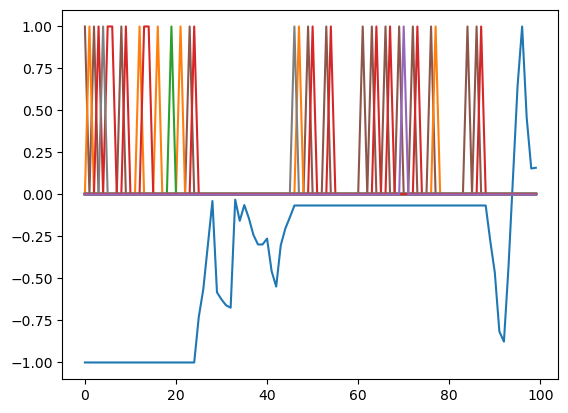

In [ ]:
K=9
# plt.plot(test_channel[K*24:(K+1)*24]);
# plt.imshow(test_channel[1200:1300]);
plt.plot(test_channel[1200:1300]);

In [ ]:
from src.models.horpca.horpca_torch import HoRPCA_Singleton
from tqdm import tqdm
import torch

In [ ]:
t_range = np.linspace(0, 1, endpoint=True, num=100)
bic = []
p_s = torch.Tensor(1/(1+np.exp(-(1-t_range)/t_range))).to('cuda:1')
S_ps = torch.Tensor(test_channel).to('cuda:1')
for i,t in tqdm(enumerate(t_range), total=len(t_range)):
    horpca = HoRPCA_Singleton(test_channel, lda_nucs=[1-t], lda1=t,
                              rho=4*np.abs(test_channel).sum()/test_channel.size,
                                lr_modes=[1], maxit=150, tol=1e-5, verbose=0,
                                device='cuda:1')
    X,S = horpca()
    bic.append(horpca.bayesian_information_criterion())
    S_ps += S.abs()*p_s[i]

/tmp/ipykernel_836560/2490332039.py:3: RuntimeWarning: divide by zero encountered in divide
  p_s = torch.Tensor(1/(1+np.exp(-(1-t_range)/t_range))).to('cuda:1')
100%|██████████| 100/100 [01:01<00:00,  1.62it/s]


In [ ]:
labels = np.zeros((len(test_channel),), dtype=bool)
labels[1250:1551] = True
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, precision_recall_curve, auc

In [ ]:
bic_arr = np.array([b.cpu().item() for b, k in bic])
k_arr = [k.cpu().item() for b, k in bic]
arg_min_bic = np.argmin(bic_arr)
min_bic = bic_arr[arg_min_bic]
best_t = t_range[arg_min_bic]
print(f"Best t: {best_t}, Min BIC: {min_bic}")


Best t: 0.48484848484848486, Min BIC: 684708.5


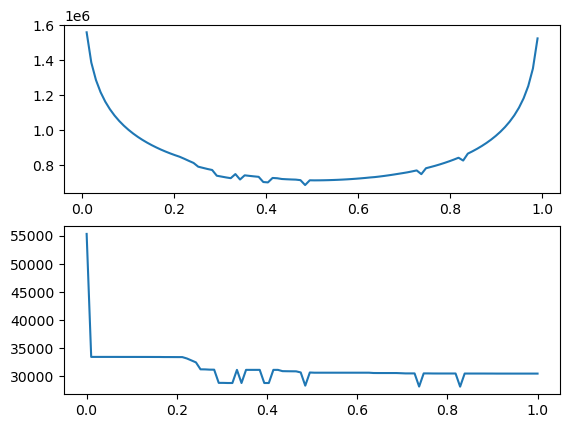

In [ ]:

fig, axes = plt.subplots(2,1)
axes[0].plot(t_range, bic_arr)
axes[1].plot(t_range, k_arr)

In [ ]:
horpca = HoRPCA_Singleton(test_channel, lda_nucs=[1-0.42], lda1=0.42,#best_t], lda1=best_t,
                              rho=4*np.abs(test_channel).sum()/test_channel.size,
                                lr_modes=[1], maxit=300, tol=1e-7, verbose=0,
                                device='cuda:1')
X,S = horpca()
print(f1_score(labels, (S!=0).any(axis=1).cpu().numpy()))
print(precision_score(labels, (S!=0).any(axis=1).cpu().numpy()))
print(recall_score(labels, (S!=0).any(axis=1).cpu().numpy()))
print(roc_auc_score(labels, S.abs().sum(axis=1).cpu().numpy()))

0.1786085150571132
0.1299093655589124
0.2857142857142857
0.5123116086571236


0.23118279569892472
0.13069908814589665
1.0
0.4325002240284632
0.12778666661590588


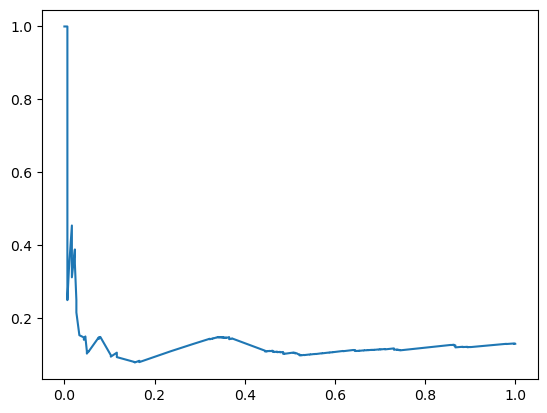

In [ ]:
print(f1_score(labels, (S_ps!=0).any(axis=1).cpu().numpy()))
print(precision_score(labels, (S_ps!=0).any(axis=1).cpu().numpy()))
print(recall_score(labels, (S_ps!=0).any(axis=1).cpu().numpy()))
print(roc_auc_score(labels, S_ps.abs().sum(axis=1).cpu().numpy()))
p, r, th = precision_recall_curve(labels, S_ps.abs().sum(axis=1).cpu().numpy())
print(auc(r, p))
plt.plot(r, p)

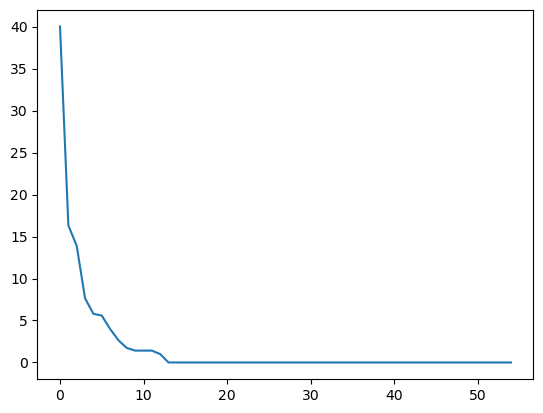

In [ ]:
s = np.linalg.svd(test_channel, compute_uv=False)
plt.plot(s);
plt.